In [72]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.binary_subset import BinaryPairDataset

from models.basemodel import CNNWithSizeMLP
from models.basemodel_256 import CNN256WithSizeMLP
from models.basemodel_256_multilayer import CNN256WithSizeMLP_multi
from models.convnext_model import ConvNeXtTinyWithSize
from models.specialist_binary import BinarySpecialist
from models.convnext_384 import ConvNeXtTiny384WithSize
from models.convnext_lin import ConvNeXtTinyLinearWithSize

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix, plot_confusion_matrices_horizontal
from engine.data_setup import setup_datasets

from engine.specialist_pair import choose_specialist_pair
from engine.train_specialist import train_binary_specialist
from engine.two_stage_infer import two_stage_predict

from loss_fn.focal_loss import FocalLoss

from engine.random_seed import seed_everything
from engine.plot_tsne import plot_pca_tsne_flowerid_two_panels, extract_features_labels_flowerids

print("All libraries imported successfully!")

All libraries imported successfully!


In [73]:
SEED = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



Using device: cuda


In [74]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [4]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 856
1 Brassica napus 795
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 799
5 Hieracium umbellatum 735
6 Hypochaeris radicata 717
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [5]:

print("\nTest set class distribution:")
for k in sorted(test_counts):
    print(k, idx_to_class[int(k)], test_counts[k])


Test set class distribution:
0 Bellis perennis 142
1 Brassica napus 200
2 Capsella bursa-pastoris 183
3 Cichorium intybus 130
4 Crepis capillaris 200
5 Hieracium umbellatum 200
6 Hypochaeris radicata 200
7 Sonchus arvensis 334
8 Tragopogon pratensis 166
9 Tussilago farfara 167


# Base Model (Erik's)

## Base Model (Erik's) & Excluding missing size

In [4]:
seed_everything(SEED, deterministic=True)

model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [13]:
BATCHSIZE = 32
EPOCHS = 20

history, test_loader = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,test_dataset=test_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=20
    ,early_stopping_patience=0
)

100%|██████████| 253/253 [00:25<00:00, 10.10it/s]


Epoch 1/20 | Train Loss: 0.0428, Train Acc: 0.9854


100%|██████████| 253/253 [00:23<00:00, 10.88it/s]


Epoch 2/20 | Train Loss: 0.0223, Train Acc: 0.9938


100%|██████████| 253/253 [00:23<00:00, 10.98it/s]


...

Epoch 18/20 | Train Loss: 0.0112, Train Acc: 0.9958


100%|██████████| 253/253 [00:22<00:00, 11.10it/s]


Epoch 19/20 | Train Loss: 0.0206, Train Acc: 0.9926


100%|██████████| 253/253 [00:22<00:00, 11.10it/s]


Epoch 20/20 | Train Loss: 0.0145, Train Acc: 0.9959



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.536622047424316
Mean of batch means: 0.8102777014013196
Mean of batch stds: 0.9024200390596859

Test Accuracy: 0.7680
Test Recall per class:
Class 0 (Bellis perennis): 0.3521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9846
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9450
Class 6 (Hypochaeris radicata): 0.5050
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9458
Class 9 (Tussilago farfara): 0.9940


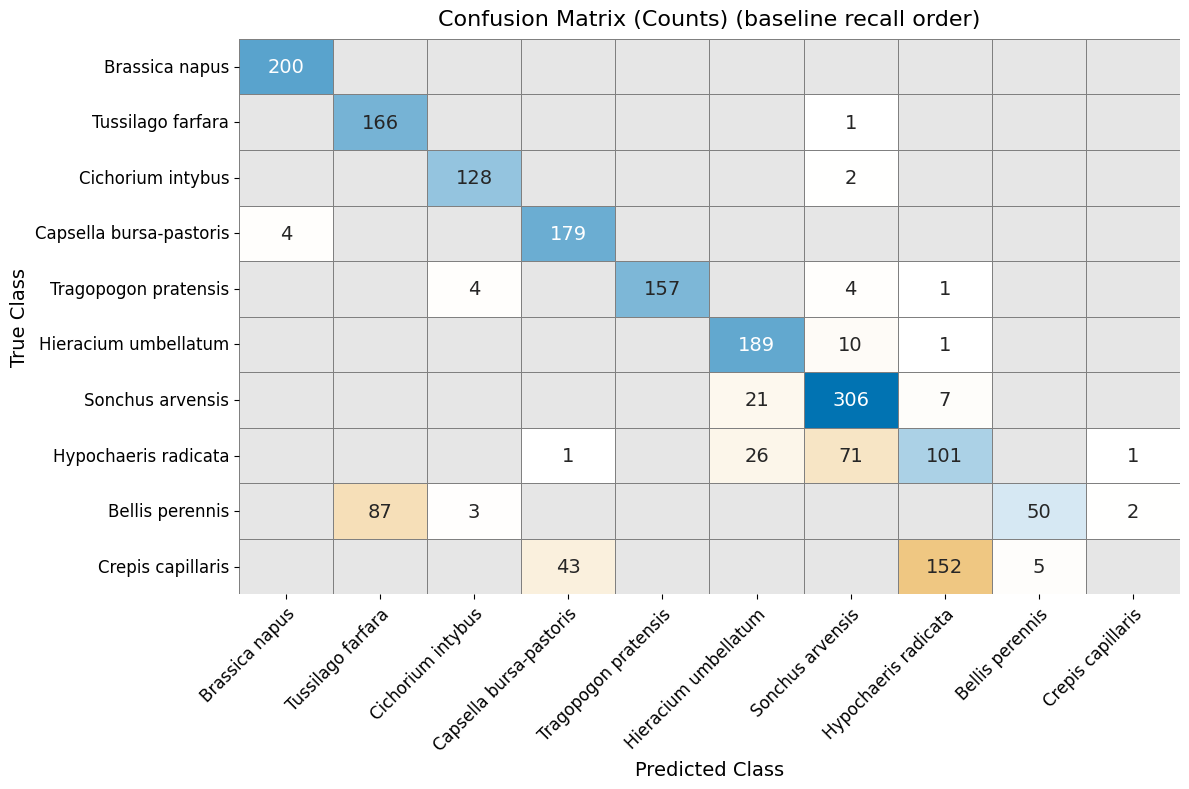

In [6]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, probs_base,y_base, conf_base = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_base, idx_to_class, normalize=False, save_path="figures/confmat_base", sort_by_recall_desc=True)

## Investigate worst recall species: 
Class 4 (Crepis capillaris): 0.0000 is being confused the most with:
- Class 6 (Hypochaeris radicata): 0.5050
- Class 2 (Capsella bursa-pastoris): 0.9781

Class 0 (Bellis perennis): 0.3521
- Class 9 (Tussilago farfara): 0.9940

Class 6 (Hypochaeris radicata): 0.5050
- Class 7 (Sonchus arvensis): 0.9162
- Class 5 (Hieracium umbellatum): 0.9450

In [9]:
import torch
import numpy as np

def extract_backbone_and_combined(model, loader, device, selected_classes=(4,6,2)):
    """
    Returns:
      X_backbone: [N, D] backbone features
      X_combined: [N, D+2] backbone features concatenated with size
      sizes_np:   [N, 2]  (major, minor)
      y_np:       [N]
    """
    model.eval()
    selected_classes = torch.tensor(selected_classes, device=device)

    feats_list, comb_list, sizes_list, y_list = [], [], [], []

    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            sizes = sizes.to(device)
            labels = labels.to(device)

            mask = torch.isin(labels, selected_classes)
            if mask.sum() == 0:
                continue

            imgs_m = imgs[mask]
            sizes_m = sizes[mask]
            labels_m = labels[mask]

            # backbone features
            f = model.backbone(imgs_m)                 # [b, D]
            x_comb = torch.cat([f, sizes_m], dim=1)    # [b, D+2]

            feats_list.append(f.cpu())
            comb_list.append(x_comb.cpu())
            sizes_list.append(sizes_m.cpu())
            y_list.append(labels_m.cpu())

    X_backbone = torch.cat(feats_list, dim=0).numpy()
    X_combined = torch.cat(comb_list, dim=0).numpy()
    sizes_np   = torch.cat(sizes_list, dim=0).numpy()
    y_np       = torch.cat(y_list, dim=0).numpy()

    return X_backbone, X_combined, sizes_np, y_np

In [24]:

def plot_2d_ax(X_2d, y, idx_to_class, title, ax):
    for cls in sorted(set(y)):
        mask = (y == cls)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.7, label=idx_to_class[cls])
    ax.set_title(title)
    ax.legend(fontsize=8)

In [20]:
def plot_size_scatter_ax(S, y, idx_to_class, classes, ax):
    for cls in classes:
        mask = (y == cls)
        ax.scatter(S[mask, 0], S[mask, 1], alpha=0.6, label=idx_to_class[cls])
    ax.set_xlabel("Major axis")
    ax.set_ylabel("Minor axis")
    ax.set_title(f"Scatter: {classes}")
    ax.legend(fontsize=8)

def plot_size_histograms_ax(S, y, idx_to_class, classes, ax_major, ax_minor, bins=30):
    for cls in classes:
        mask = (y == cls)
        ax_major.hist(S[mask, 0], bins=bins, alpha=0.5, label=idx_to_class[cls])
        ax_minor.hist(S[mask, 1], bins=bins, alpha=0.5, label=idx_to_class[cls])

    ax_major.set_title(f"Major axis: {classes}")
    ax_major.set_xlabel("Major axis")
    ax_major.legend(fontsize=8)

    ax_minor.set_title(f"Minor axis: {classes}")
    ax_minor.set_xlabel("Minor axis")
    ax_minor.legend(fontsize=8)

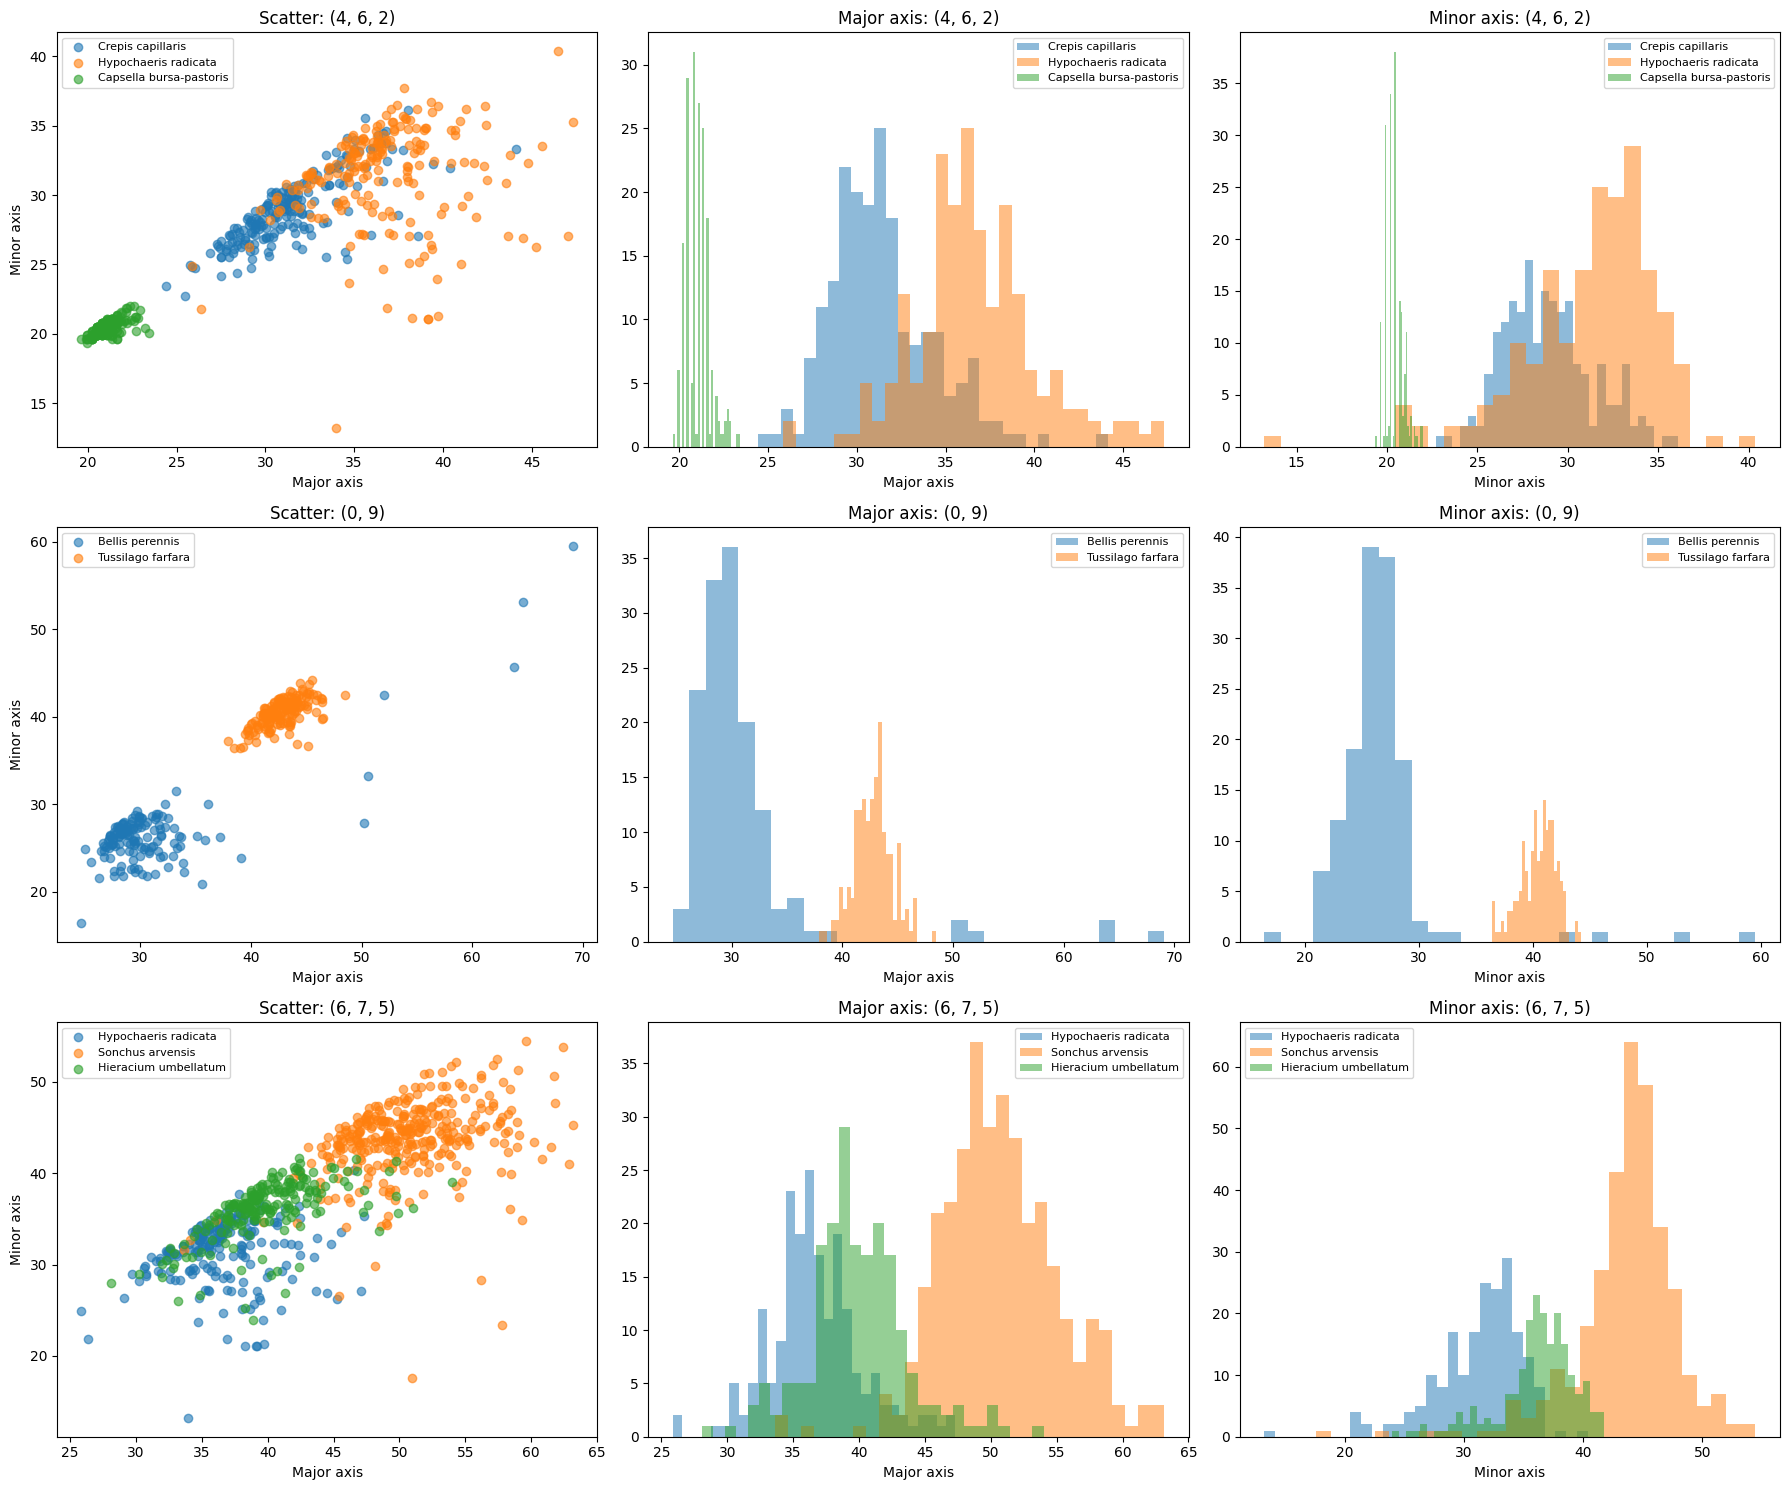

In [21]:
classes_chosen = [(4, 6, 2), (0, 9), (6, 7, 5)]

fig, ax = plt.subplots(
    nrows=len(classes_chosen),
    ncols=3,
    figsize=(18, 5 * len(classes_chosen))
)

# in case len(classes_chosen) == 1
if len(classes_chosen) == 1:
    ax = np.expand_dims(ax, axis=0)

for i, cls_tuple in enumerate(classes_chosen):
    Xb, Xc, S, y = extract_backbone_and_combined(
        model_base,
        test_loader,
        device,
        selected_classes=cls_tuple
    )

    plot_size_scatter_ax(S, y, idx_to_class, classes=cls_tuple, ax=ax[i, 0])
    plot_size_histograms_ax(S, y, idx_to_class, classes=cls_tuple,
                            ax_major=ax[i, 1], ax_minor=ax[i, 2])

plt.tight_layout()
plt.show()

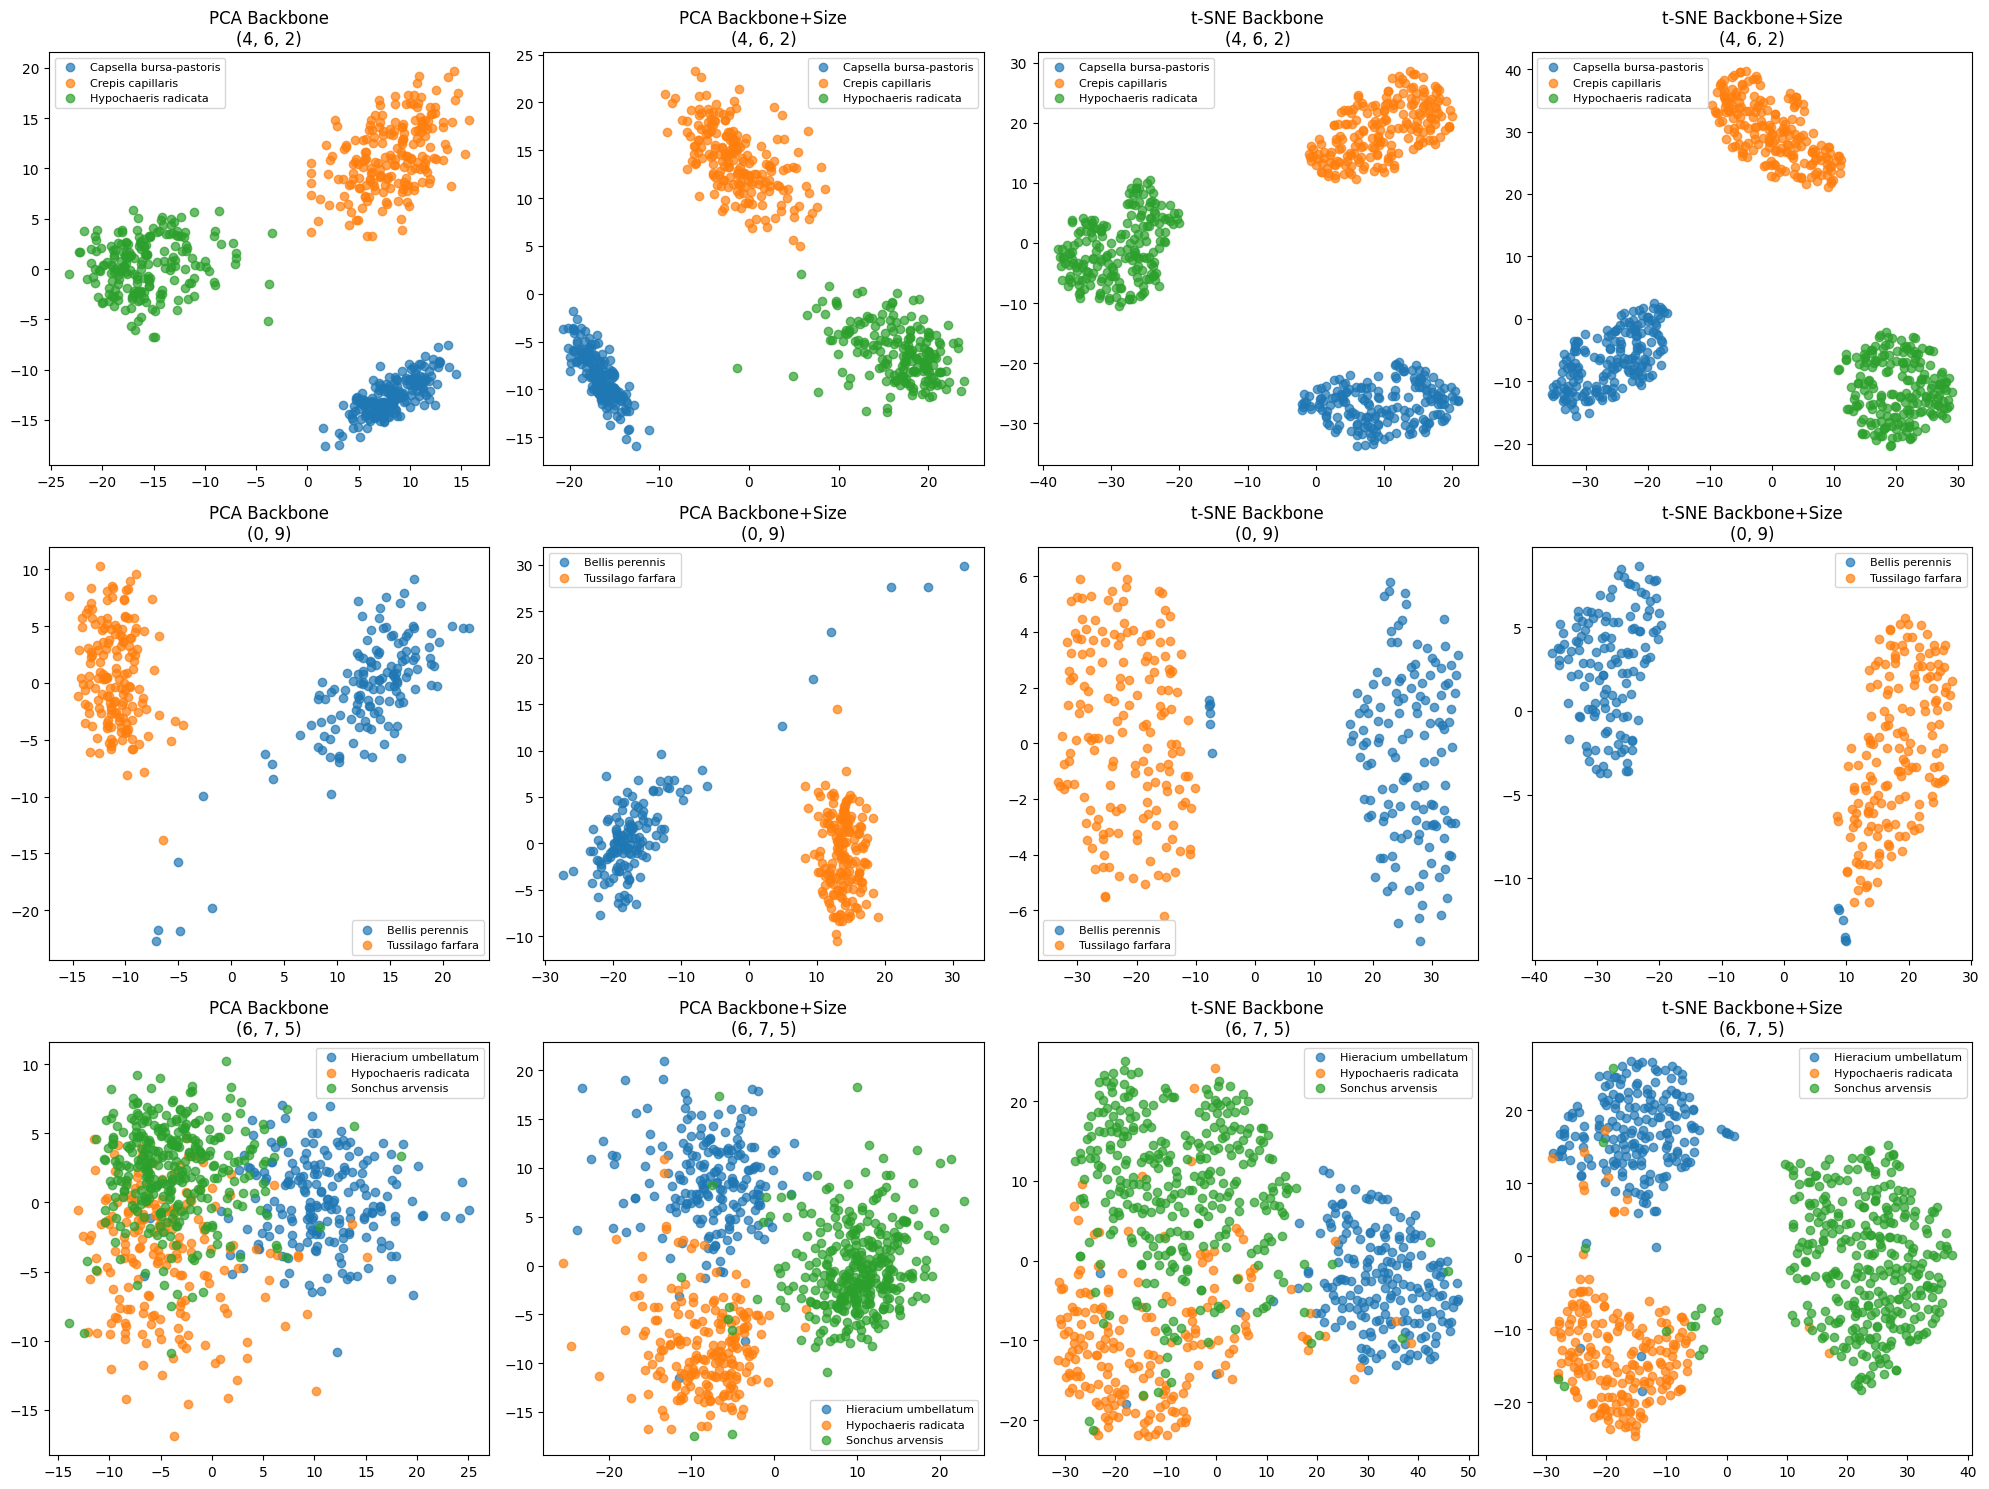

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

classes_chosen = [(4,6,2), (0,9), (6,7,5)]

fig, ax = plt.subplots(len(classes_chosen), 4, figsize=(20, 5 * len(classes_chosen)))

if len(classes_chosen) == 1:
    ax = np.expand_dims(ax, axis=0)

for i, cls_tuple in enumerate(classes_chosen):
    Xb, Xc, S, y = extract_backbone_and_combined(
        model_base,
        test_loader,
        device,
        selected_classes=cls_tuple
    )

    # PCA
    pca_b = PCA(n_components=2).fit_transform(Xb)
    pca_c = PCA(n_components=2).fit_transform(Xc)

    # t-SNE
    subset = min(1500, len(y))
    Xb_sub, Xc_sub, y_sub = Xb[:subset], Xc[:subset], y[:subset]

    tsne_b = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xb_sub)
    tsne_c = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xc_sub)

    plot_2d_ax(pca_b, y, idx_to_class, f"PCA Backbone\n{cls_tuple}", ax[i, 0])
    plot_2d_ax(pca_c, y, idx_to_class, f"PCA Backbone+Size\n{cls_tuple}", ax[i, 1])
    plot_2d_ax(tsne_b, y_sub, idx_to_class, f"t-SNE Backbone\n{cls_tuple}", ax[i, 2])
    plot_2d_ax(tsne_c, y_sub, idx_to_class, f"t-SNE Backbone+Size\n{cls_tuple}", ax[i, 3])

plt.tight_layout()
plt.show()

## Base Model (Erik's) & Filling missing size & Validation split

In [6]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 8078
Dataset setup complete.


In [7]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 858
1 Brassica napus 800
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 800
5 Hieracium umbellatum 800
6 Hypochaeris radicata 800
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [8]:
seed_everything(SEED, deterministic=True)
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Valida

In [9]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])

print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 677
1 Brassica napus 629
2 Capsella bursa-pastoris 664
3 Cichorium intybus 690
4 Crepis capillaris 647
5 Hieracium umbellatum 640
6 Hypochaeris radicata 662
7 Sonchus arvensis 526
8 Tragopogon pratensis 666
9 Tussilago farfara 661


In [10]:
val_counts = Counter([val_dataset[i][2].item() for i in range(len(val_dataset))])

print("Validation set class distribution:")
for k in sorted(val_counts):
    print(k, idx_to_class[int(k)], val_counts[k])

Validation set class distribution:
0 Bellis perennis 181
1 Brassica napus 171
2 Capsella bursa-pastoris 153
3 Cichorium intybus 180
4 Crepis capillaris 153
5 Hieracium umbellatum 160
6 Hypochaeris radicata 138
7 Sonchus arvensis 140
8 Tragopogon pratensis 168
9 Tussilago farfara 172


In [10]:
seed_everything(SEED, deterministic=True)
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [11]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_fill_val_seednew.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:20<00:00,  9.95it/s]


Epoch 1/40 | Train Loss: 0.3011, Train Acc: 0.9006
| Val Acc: 0.8663
Val Recall per class: tensor([0.9558, 1.0000, 0.8889, 1.0000, 0.5490, 0.9875, 0.3841, 0.7786, 0.9762,
        1.0000])
Saved new best model (Val Acc = 0.8663)


100%|██████████| 202/202 [00:19<00:00, 10.18it/s]


Epoch 2/40 | Train Loss: 0.1364, Train Acc: 0.9547
| Val Acc: 0.7896


100%|██████████| 202/202 [00:19<00:00, 10.17it/s]


...

Epoch 29/40 | Train Loss: 0.0034, Train Acc: 0.9988
| Val Acc: 0.9808


100%|██████████| 202/202 [00:20<00:00, 10.05it/s]


Epoch 30/40 | Train Loss: 0.0066, Train Acc: 0.9986
| Val Acc: 0.9889
Val Recall per class: tensor([0.9890, 0.9942, 0.9869, 0.9889, 0.9804, 0.9937, 0.9928, 0.9643, 0.9940,
        1.0000])


100%|██████████| 202/202 [00:19<00:00, 10.11it/s]


Epoch 31/40 | Train Loss: 0.0067, Train Acc: 0.9981
| Val Acc: 0.9152
Early stopping at epoch 31. Best Val Acc = 0.9963 at epoch 23.
Reloaded best model from epoch 23 (Val Acc=0.9963)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.26844596862793
Mean of batch means: 0.8152145166866115
Mean of batch stds: 0.9938946258826334

Test Accuracy: 0.7627
Test Recall per class:
Class 0 (Bellis perennis): 0.6972
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9891
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9750
Class 6 (Hypochaeris radicata): 0.5900
Class 7 (Sonchus arvensis): 0.6647
Class 8 (Tragopogon pratensis): 0.9277
Class 9 (Tussilago farfara): 1.0000


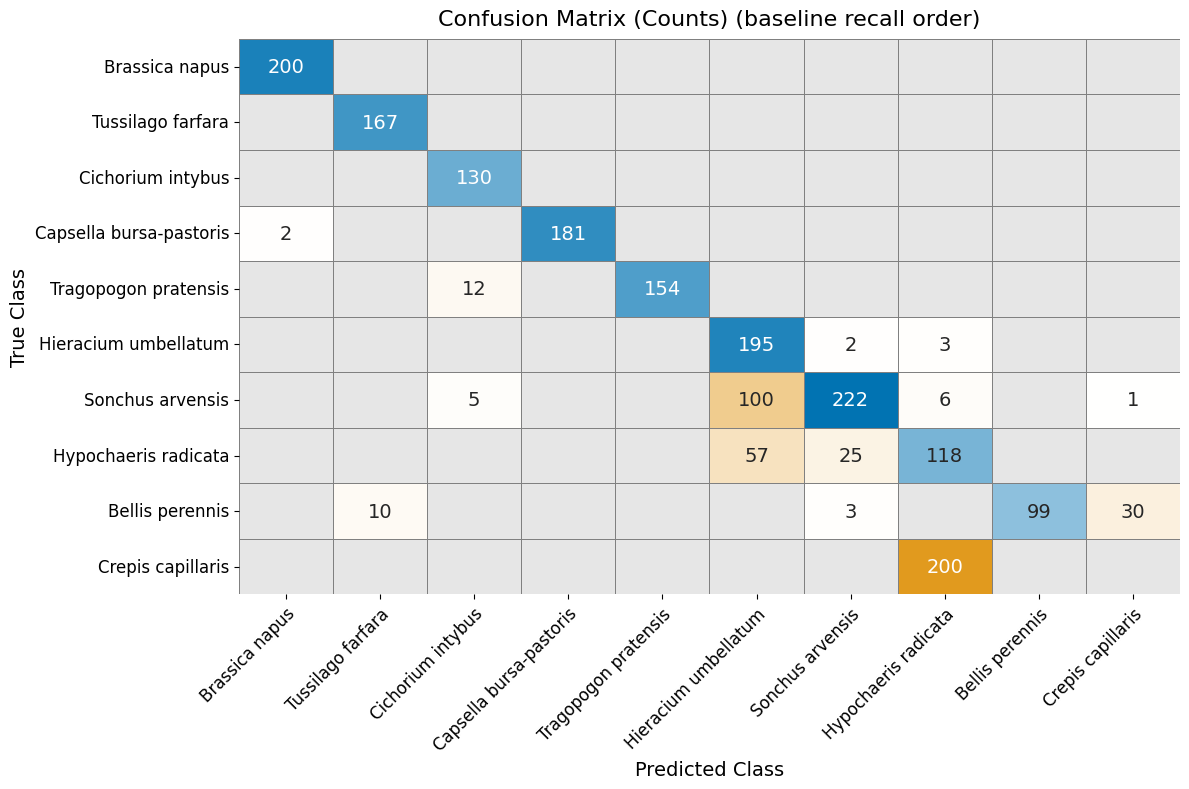

In [12]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val_seednew.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, probs_M1, y_M1, conf_M1 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M1, idx_to_class, normalize=False, save_path="figures/confmat_M1")

## Base Model (Erik's) & Filling missing size & Validation split & Augmentation

In [16]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [17]:
val_counts = Counter([val_dataset[i][2].item() for i in range(len(val_dataset))])

print("Training set class distribution:")
for k in sorted(val_counts):
    print(k, idx_to_class[int(k)], val_counts[k])

Training set class distribution:
0 Bellis perennis 169
1 Brassica napus 181
2 Capsella bursa-pastoris 185
3 Cichorium intybus 193
4 Crepis capillaris 166
5 Hieracium umbellatum 153
6 Hypochaeris radicata 166
7 Sonchus arvensis 189
8 Tragopogon pratensis 167
9 Tussilago farfara 171


In [9]:
seed_everything(SEED, deterministic=True)
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [19]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:22<00:00,  9.66it/s]


Epoch 1/40 | Train Loss: 0.3089, Train Acc: 0.8957
| Val Loss: 0.4363, Val Acc: 0.8483
Val Recall per class: tensor([0.9941, 0.8453, 0.9892, 0.2228, 0.9157, 0.6209, 0.9578, 0.9947, 0.9880,
        0.9942])
Saved new best model (Val Acc = 0.8483)


100%|██████████| 218/218 [00:22<00:00,  9.69it/s]


Epoch 2/40 | Train Loss: 0.1535, Train Acc: 0.9489
| Val Loss: 0.4283, Val Acc: 0.8552
Saved new best model (Val Acc = 0.8552)


100%|██████████| 218/218 [00:22<00:00,  9.62it/s]


...

Epoch 25/40 | Train Loss: 0.0443, Train Acc: 0.9871
| Val Loss: 0.1467, Val Acc: 0.9626
Val Recall per class: tensor([1.0000, 0.9724, 0.9838, 0.8860, 0.9819, 0.9739, 0.9639, 0.9153, 0.9641,
        1.0000])


100%|██████████| 218/218 [00:22<00:00,  9.64it/s]


Epoch 26/40 | Train Loss: 0.0153, Train Acc: 0.9951
| Val Loss: 0.0519, Val Acc: 0.9833


100%|██████████| 218/218 [00:23<00:00,  9.39it/s]


Epoch 27/40 | Train Loss: 0.0196, Train Acc: 0.9922
| Val Loss: 0.0603, Val Acc: 0.9845
Early stopping at epoch 27. Best Val Acc = 0.9925 at epoch 19.
Reloaded best model from epoch 19 (Val Acc=0.9925)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.86814022064209
Mean of batch means: 0.8290309945090872
Mean of batch stds: 0.9259786058644779

Test Accuracy: 0.7648
Test Recall per class:
Class 0 (Bellis perennis): 0.8803
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.6700
Class 7 (Sonchus arvensis): 0.5689
Class 8 (Tragopogon pratensis): 0.9036
Class 9 (Tussilago farfara): 1.0000


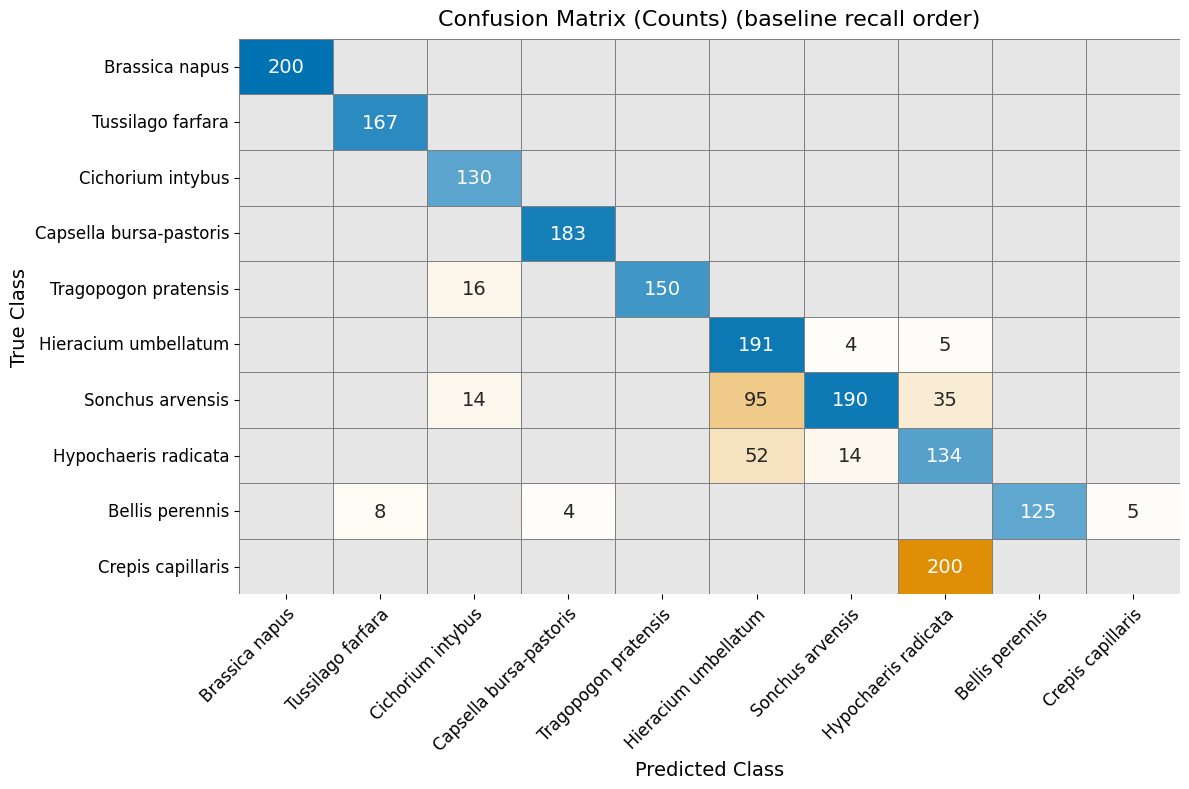

In [11]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val_aug.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, probs_M2, y_M2, conf_M2 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M2, idx_to_class, normalize=False)

## Base Model (Erik's) & Filling missing size by bootstrap & Validation split & Augmentation

In [4]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,bootstrap_impute_bool=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [12]:
seed_everything(SEED, deterministic=True)
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [32]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_val_aug_boot.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:23<00:00,  9.30it/s]


Epoch 1/40 | Train Loss: 0.3023, Train Acc: 0.9019
| Val Loss: 1.0478, Val Acc: 0.7316
Val Recall per class: tensor([0.9645, 0.8674, 0.9459, 0.3886, 0.9940, 0.2222, 0.4096, 0.9048, 0.5629,
        1.0000])
Saved new best model (Val Acc = 0.7316)


100%|██████████| 218/218 [00:22<00:00,  9.69it/s]


Epoch 2/40 | Train Loss: 0.1444, Train Acc: 0.9530
| Val Loss: 0.3937, Val Acc: 0.8655
Saved new best model (Val Acc = 0.8655)


100%|██████████| 218/218 [00:22<00:00,  9.69it/s]


...

Epoch 14/40 | Train Loss: 0.0290, Train Acc: 0.9902
| Val Loss: 0.0539, Val Acc: 0.9828


100%|██████████| 218/218 [00:22<00:00,  9.70it/s]


Epoch 15/40 | Train Loss: 0.0558, Train Acc: 0.9820
| Val Loss: 0.4383, Val Acc: 0.8851
Val Recall per class: tensor([0.8225, 0.9890, 0.9351, 1.0000, 0.8133, 0.9412, 0.9699, 0.6667, 0.7186,
        0.9942])


100%|██████████| 218/218 [00:22<00:00,  9.73it/s]


Epoch 16/40 | Train Loss: 0.0296, Train Acc: 0.9904
| Val Loss: 0.2363, Val Acc: 0.9339
Early stopping at epoch 16. Best Val Acc = 0.9845 at epoch 8.
Reloaded best model from epoch 8 (Val Acc=0.9845)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 11.596412658691406
Mean of batch means: 0.8890369172956123
Mean of batch stds: 1.038719575913226

Test Accuracy: 0.7721
Test Recall per class:
Class 0 (Bellis perennis): 0.9577
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.2600
Class 7 (Sonchus arvensis): 0.9042
Class 8 (Tragopogon pratensis): 0.7289
Class 9 (Tussilago farfara): 1.0000


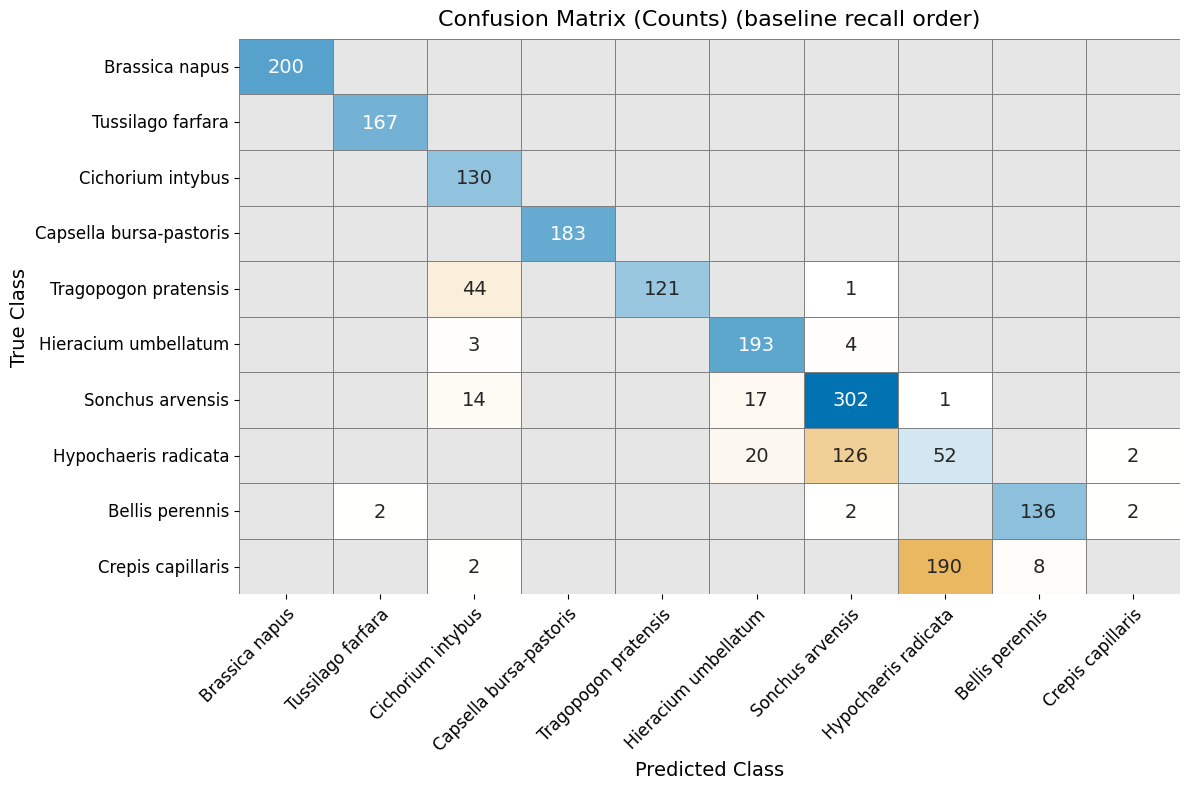

In [14]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_val_aug_boot.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class, accuracy, probs_M4, y_M4, conf_M4 = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M4, idx_to_class, normalize=False,save_path="figures/confmat_M4")

# Base model & focal loss

In [3]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [4]:
seed_everything(SEED, deterministic=True)
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [5]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_fill_val_aug_focal.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:24<00:00,  8.98it/s]


Epoch 1/40 | Train Loss: 0.1672, Train Acc: 0.8818
| Val Acc: 0.9132
Val Recall per class: tensor([1.0000, 0.9613, 0.9838, 0.9793, 0.9940, 0.5359, 0.6928, 0.9841, 0.9461,
        0.9883])
Saved new best model (Val Acc = 0.9132)


100%|██████████| 218/218 [00:23<00:00,  9.11it/s]


Epoch 2/40 | Train Loss: 0.0717, Train Acc: 0.9425
| Val Acc: 0.9115


100%|██████████| 218/218 [00:23<00:00,  9.20it/s]


...

Epoch 17/40 | Train Loss: 0.0187, Train Acc: 0.9835
| Val Acc: 0.9586


100%|██████████| 218/218 [00:22<00:00,  9.63it/s]


Epoch 18/40 | Train Loss: 0.0236, Train Acc: 0.9783
| Val Acc: 0.9621


100%|██████████| 218/218 [00:22<00:00,  9.71it/s]


Epoch 19/40 | Train Loss: 0.0277, Train Acc: 0.9777
| Val Acc: 0.9517
Early stopping at epoch 19. Best Val Acc = 0.9891 at epoch 11.
Reloaded best model from epoch 11 (Val Acc=0.9891)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.808670997619629
Mean of batch means: 0.7765520938107224
Mean of batch stds: 0.8786351670984363

Test Accuracy: 0.7940
Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9450
Class 6 (Hypochaeris radicata): 0.5800
Class 7 (Sonchus arvensis): 0.8293
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


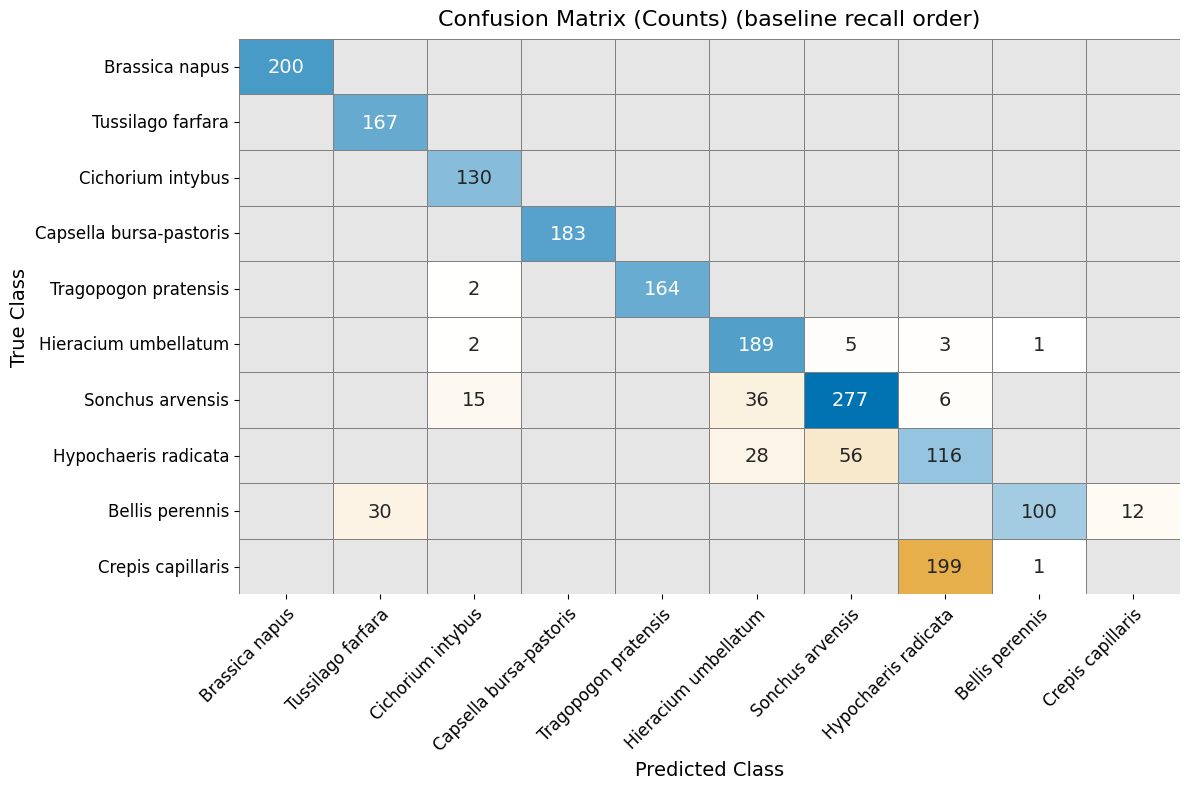

In [6]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val_aug_focal.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_FL, accuracy_FL, probs_FL, ys_FL, conf_FL = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_FL:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_FL):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_FL, idx_to_class, normalize=False,save_path="figures/confmat_M4")

In [8]:
seed_everything(SEED, deterministic=True)
model_base = CNNWithSizeMLP(num_classes=num_classes).to(device)

loss_fn = FocalLoss(gamma=1.0)
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [7]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_fill_val_aug_focalg1.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:22<00:00,  9.51it/s]


Epoch 1/40 | Train Loss: 0.0638, Train Acc: 0.9497
| Val Acc: 0.8989
Val Recall per class: tensor([0.8876, 0.9613, 0.9784, 0.4922, 1.0000, 0.7582, 0.9518, 1.0000, 0.9820,
        1.0000])
Saved new best model (Val Acc = 0.8989)


100%|██████████| 218/218 [00:22<00:00,  9.73it/s]


Epoch 2/40 | Train Loss: 0.0306, Train Acc: 0.9746
| Val Acc: 0.9086
Saved new best model (Val Acc = 0.9086)


100%|██████████| 218/218 [00:22<00:00,  9.65it/s]


...

Epoch 13/40 | Train Loss: 0.0141, Train Acc: 0.9876
| Val Acc: 0.9328


100%|██████████| 218/218 [00:22<00:00,  9.73it/s]


Epoch 14/40 | Train Loss: 0.0074, Train Acc: 0.9943
| Val Acc: 0.9649


100%|██████████| 218/218 [00:22<00:00,  9.73it/s]


Epoch 15/40 | Train Loss: 0.0167, Train Acc: 0.9869
| Val Acc: 0.9805
Val Recall per class: tensor([1.0000, 1.0000, 0.9568, 0.9534, 0.9940, 0.9804, 0.9940, 0.9683, 0.9641,
        1.0000])
Early stopping at epoch 15. Best Val Acc = 0.9897 at epoch 7.
Reloaded best model from epoch 7 (Val Acc=0.9897)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.26829719543457
Mean of batch means: 0.6940202927980267
Mean of batch stds: 0.8008723122174622

Test Accuracy: 0.7586
Test Recall per class:
Class 0 (Bellis perennis): 0.0493
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0050
Class 5 (Hieracium umbellatum): 0.9600
Class 6 (Hypochaeris radicata): 0.5600
Class 7 (Sonchus arvensis): 0.8982
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


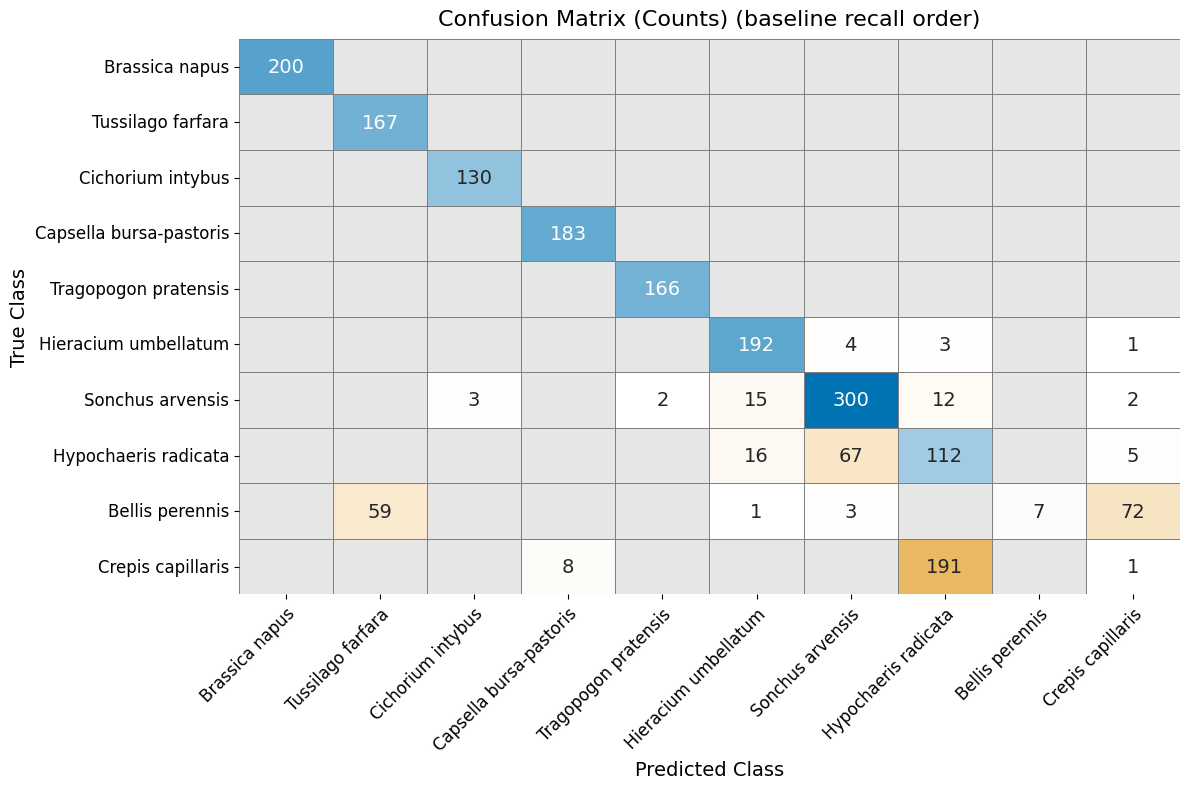

In [9]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_fill_val_aug_focalg1.pth", map_location=device)
model_base.load_state_dict(ckpt["model_state_dict"])
model_base.to(device)

recall_per_class_FL, accuracy_FL, probs_FL, ys_FL, conf_FL = eval_epoch(model_base, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_FL:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_FL):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_FL, idx_to_class, normalize=False,save_path="figures/confmat_M4")

# !!!!!!!!!!!!!!HERE!!!!!!!!!!!!!!!!

## Base Model to dense 256-dim & Filling missing size & Validation split & Augmentation

# 256-dim + MLP

In [15]:
seed_everything(SEED, deterministic=True)
model_base256MLP = CNN256WithSizeMLP_multi(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256MLP.parameters(), lr=0.001)

In [16]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [15]:
for name, param in model_base256MLP.named_parameters():
    print(f"{name} | shape={tuple(param.shape)}")
    print(param.data.view(-1)[:10])   # first 10 values
    print("-" * 50)

backbone.conv1.weight | shape=(64, 3, 7, 7)
tensor([-0.0104, -0.0061, -0.0018,  0.0748,  0.0566,  0.0171, -0.0127,  0.0111,
         0.0095, -0.1099], device='cuda:0')
--------------------------------------------------
backbone.bn1.weight | shape=(64,)
tensor([ 2.3487e-01,  2.6626e-01, -5.1096e-08,  5.1870e-01,  3.4404e-09,
         2.2239e-01,  4.2289e-01,  1.3153e-07,  2.5093e-01,  1.5152e-06],
       device='cuda:0')
--------------------------------------------------
backbone.bn1.bias | shape=(64,)
tensor([ 2.3072e-01,  2.5382e-01, -1.0543e-06, -6.6439e-01, -1.6571e-08,
         1.6152e-01,  4.5450e-01, -4.3020e-07,  3.0051e-01, -8.0052e-06],
       device='cuda:0')
--------------------------------------------------
backbone.layer1.0.conv1.weight | shape=(64, 64, 3, 3)
tensor([ 0.0576, -0.0951, -0.0203, -0.0746, -0.7993, -0.2128,  0.0656, -0.0965,
        -0.0121, -0.0070], device='cuda:0')
--------------------------------------------------
backbone.layer1.0.bn1.weight | shape=(64,)

In [ ]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:22<00:00,  9.50it/s]


Epoch 1/40 | Train Loss: 0.3434, Train Acc: 0.8874
| Val Loss: 0.9654, Val Acc: 0.7534
Val Recall per class: tensor([1.0000, 0.9669, 0.6541, 0.0104, 0.9759, 0.9477, 0.2229, 0.8677, 0.9880,
        1.0000])
Saved new best model (Val Acc = 0.7534)


100%|██████████| 218/218 [00:22<00:00,  9.61it/s]


Epoch 2/40 | Train Loss: 0.1878, Train Acc: 0.9450
| Val Loss: 0.2287, Val Acc: 0.9195
Saved new best model (Val Acc = 0.9195)


100%|██████████| 218/218 [00:23<00:00,  9.36it/s]


...

Epoch 31/40 | Train Loss: 0.0165, Train Acc: 0.9954
| Val Loss: 0.0493, Val Acc: 0.9845


100%|██████████| 218/218 [00:22<00:00,  9.63it/s]


Epoch 32/40 | Train Loss: 0.0200, Train Acc: 0.9941
| Val Loss: 0.4914, Val Acc: 0.8891


100%|██████████| 218/218 [00:22<00:00,  9.73it/s]


Epoch 33/40 | Train Loss: 0.0213, Train Acc: 0.9938
| Val Loss: 0.1103, Val Acc: 0.9759
Early stopping at epoch 33. Best Val Acc = 0.9862 at epoch 25.
Reloaded best model from epoch 25 (Val Acc=0.9862)


In [16]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256MLP
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_modelmulti_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:23<00:00,  9.20it/s]


Epoch 1/40 | Train Loss: 0.7277, Train Acc: 0.7524
| Val Loss: 0.8546, Val Acc: 0.6672
Val Recall per class: tensor([0.4615, 0.9945, 0.7838, 0.0363, 0.9458, 0.3137, 0.1325, 1.0000, 0.9820,
        1.0000])
Saved new best model (Val Acc = 0.6672)


100%|██████████| 218/218 [00:22<00:00,  9.50it/s]


Epoch 2/40 | Train Loss: 0.2979, Train Acc: 0.9171
| Val Loss: 1.0618, Val Acc: 0.7557
Saved new best model (Val Acc = 0.7557)


100%|██████████| 218/218 [00:23<00:00,  9.46it/s]


...

Epoch 32/40 | Train Loss: 0.0298, Train Acc: 0.9921
| Val Loss: 0.1156, Val Acc: 0.9724


100%|██████████| 218/218 [00:22<00:00,  9.74it/s]


Epoch 33/40 | Train Loss: 0.0489, Train Acc: 0.9876
| Val Loss: 0.0670, Val Acc: 0.9845


100%|██████████| 218/218 [00:22<00:00,  9.66it/s]


Epoch 34/40 | Train Loss: 0.0250, Train Acc: 0.9935
| Val Loss: 0.4801, Val Acc: 0.9075
Early stopping at epoch 34. Best Val Acc = 0.9902 at epoch 26.
Reloaded best model from epoch 26 (Val Acc=0.9902)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.317948341369629
Mean of batch means: 0.7193891332774865
Mean of batch stds: 0.8810300983366419

Test Accuracy: 0.8319
Test Recall per class:
Class 0 (Bellis perennis): 0.9507
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0950
Class 5 (Hieracium umbellatum): 0.9600
Class 6 (Hypochaeris radicata): 0.5700
Class 7 (Sonchus arvensis): 0.8772
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


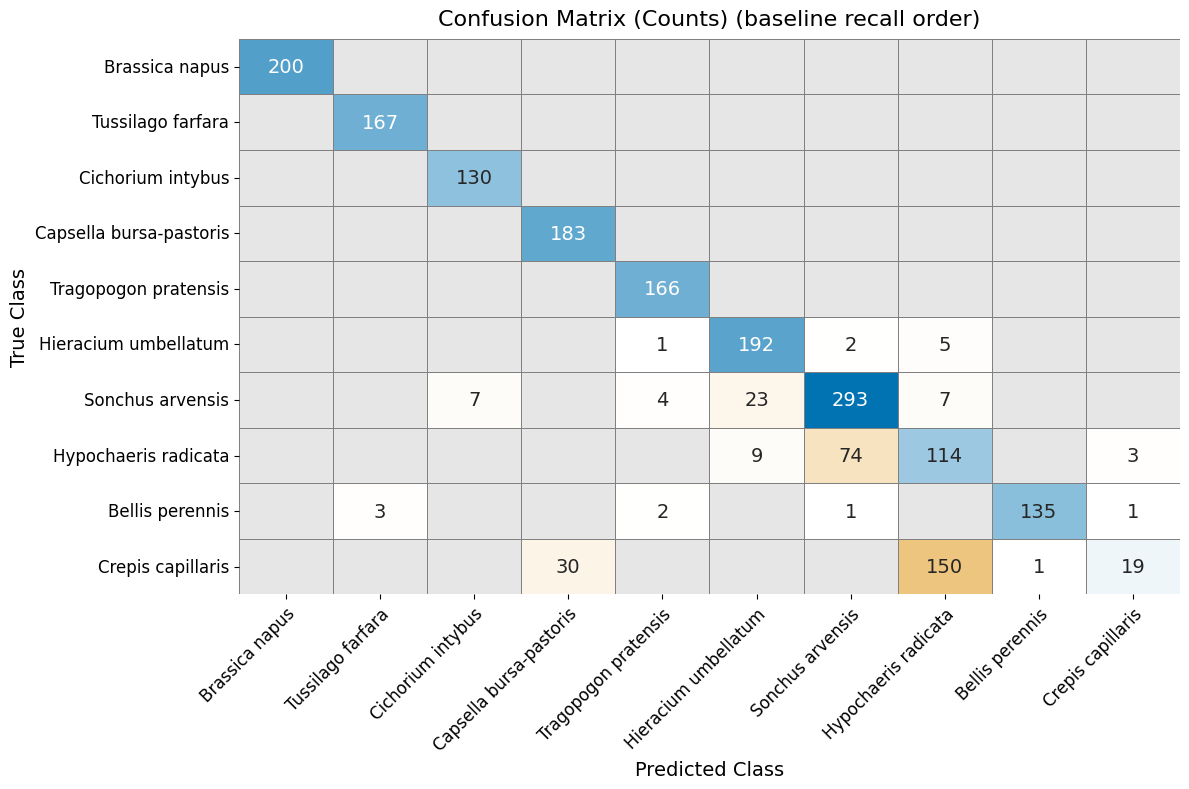

In [18]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val_aug.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, probs_M8, y_M8, conf_M8 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M8, idx_to_class, normalize=False, save_path="figures/confmat_M8")


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.228629112243652
Mean of batch means: 0.7856991466928701
Mean of batch stds: 1.030611393881626

Test Accuracy: 0.7934
Test Recall per class:
Class 0 (Bellis perennis): 0.5493
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.8415
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1900
Class 5 (Hieracium umbellatum): 0.9800
Class 6 (Hypochaeris radicata): 0.9450
Class 7 (Sonchus arvensis): 0.6617
Class 8 (Tragopogon pratensis): 0.9157
Class 9 (Tussilago farfara): 1.0000


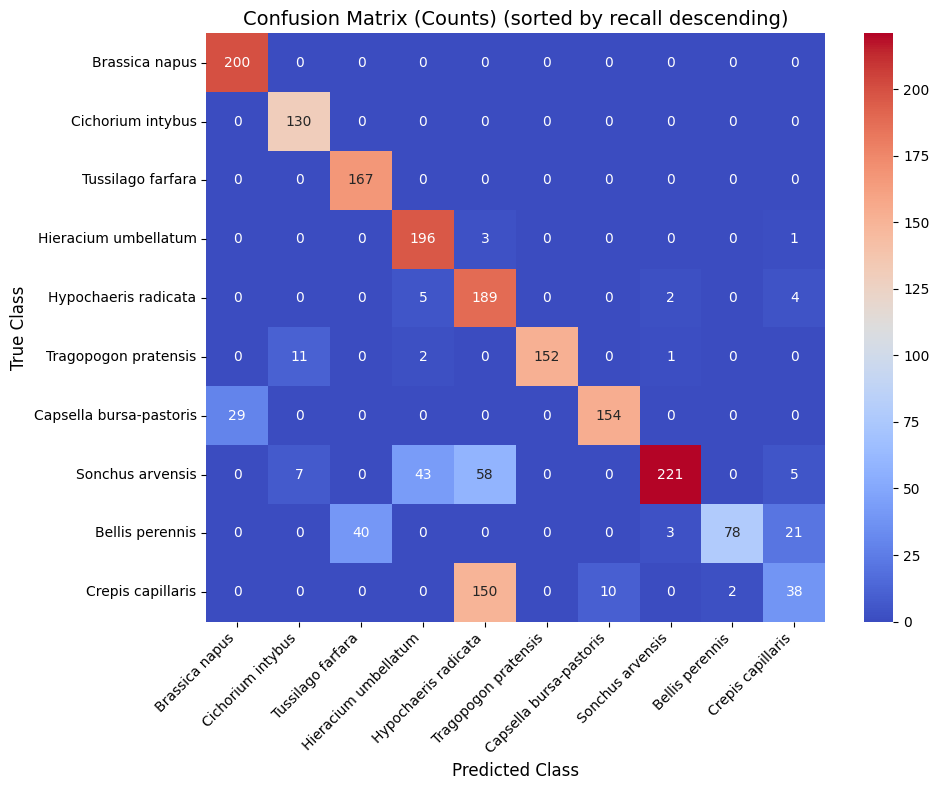

In [17]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_modelmulti_fill_val_aug.pth", map_location=device)
model_base256MLP.load_state_dict(ckpt["model_state_dict"])
model_base256MLP.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256MLP, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Base Model to dense 256-dim & Filling missing size & Validation split

In [18]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Valida

In [19]:
seed_everything(SEED, deterministic=True)
model_base256MLP = CNN256WithSizeMLP_multi(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256MLP.parameters(), lr=0.001)

In [19]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [46]:
for name, param in model_base256.named_parameters():
    print(f"{name} | shape={tuple(param.shape)}")
    print(param.data.view(-1)[:10])   # first 10 values
    print("-" * 50)

backbone.conv1.weight | shape=(64, 3, 7, 7)
tensor([-0.0104, -0.0061, -0.0018,  0.0748,  0.0566,  0.0171, -0.0127,  0.0111,
         0.0095, -0.1099], device='cuda:0')
--------------------------------------------------
backbone.bn1.weight | shape=(64,)
tensor([ 2.3487e-01,  2.6626e-01, -5.1096e-08,  5.1870e-01,  3.4404e-09,
         2.2239e-01,  4.2289e-01,  1.3153e-07,  2.5093e-01,  1.5152e-06],
       device='cuda:0')
--------------------------------------------------
backbone.bn1.bias | shape=(64,)
tensor([ 2.3072e-01,  2.5382e-01, -1.0543e-06, -6.6439e-01, -1.6571e-08,
         1.6152e-01,  4.5450e-01, -4.3020e-07,  3.0051e-01, -8.0052e-06],
       device='cuda:0')
--------------------------------------------------
backbone.layer1.0.conv1.weight | shape=(64, 64, 3, 3)
tensor([ 0.0576, -0.0951, -0.0203, -0.0746, -0.7993, -0.2128,  0.0656, -0.0965,
        -0.0121, -0.0070], device='cuda:0')
--------------------------------------------------
backbone.layer1.0.bn1.weight | shape=(64,)

In [44]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:20<00:00,  9.72it/s]


Epoch 1/40 | Train Loss: 0.3530, Train Acc: 0.8889
| Val Loss: 0.8947, Val Acc: 0.7054
Val Recall per class: tensor([0.9779, 1.0000, 0.8693, 0.1667, 1.0000, 0.9438, 0.2899, 0.4000, 0.3393,
        1.0000])
Saved new best model (Val Acc = 0.7054)


100%|██████████| 202/202 [00:20<00:00, 10.09it/s]


Epoch 2/40 | Train Loss: 0.1822, Train Acc: 0.9400
| Val Loss: 1.1694, Val Acc: 0.7519
Saved new best model (Val Acc = 0.7519)


100%|██████████| 202/202 [00:20<00:00,  9.63it/s]


...

Epoch 24/40 | Train Loss: 0.0714, Train Acc: 0.9785
| Val Loss: 0.0814, Val Acc: 0.9746


100%|██████████| 202/202 [00:19<00:00, 10.16it/s]


Epoch 25/40 | Train Loss: 0.0328, Train Acc: 0.9909
| Val Loss: 0.0536, Val Acc: 0.9845
Val Recall per class: tensor([1.0000, 0.9942, 0.9804, 0.9778, 0.9804, 0.9750, 0.9783, 0.9714, 0.9821,
        1.0000])


100%|██████████| 202/202 [00:19<00:00, 10.12it/s]


Epoch 26/40 | Train Loss: 0.0362, Train Acc: 0.9901
| Val Loss: 0.0880, Val Acc: 0.9771
Early stopping at epoch 26. Best Val Acc = 0.9938 at epoch 18.
Reloaded best model from epoch 18 (Val Acc=0.9938)


In [ ]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256MLP
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_modelmulti_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

In [20]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256MLP
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_modelmulti_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)


100%|██████████| 202/202 [00:19<00:00, 10.18it/s]


Epoch 1/40 | Train Loss: 0.7481, Train Acc: 0.7527
| Val Loss: 2.2626, Val Acc: 0.5118
Val Recall per class: tensor([0.9890, 0.8538, 0.9935, 0.3056, 0.1046, 0.0125, 0.0217, 0.2000, 0.6131,
        0.8314])
Saved new best model (Val Acc = 0.5118)


100%|██████████| 202/202 [00:19<00:00, 10.14it/s]


Epoch 2/40 | Train Loss: 0.3169, Train Acc: 0.9078
| Val Loss: 0.5733, Val Acc: 0.8632
Saved new best model (Val Acc = 0.8632)


100%|██████████| 202/202 [00:20<00:00, 10.04it/s]


...

Epoch 21/40 | Train Loss: 0.0377, Train Acc: 0.9893
| Val Loss: 0.0445, Val Acc: 0.9882


100%|██████████| 202/202 [00:20<00:00, 10.08it/s]


Epoch 22/40 | Train Loss: 0.0563, Train Acc: 0.9865
| Val Loss: 0.6939, Val Acc: 0.8317


100%|██████████| 202/202 [00:20<00:00, 10.00it/s]


Epoch 23/40 | Train Loss: 0.0627, Train Acc: 0.9824
| Val Loss: 0.1418, Val Acc: 0.9641
Early stopping at epoch 23. Best Val Acc = 0.9944 at epoch 15.
Reloaded best model from epoch 15 (Val Acc=0.9944)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.504186630249023
Mean of batch means: 0.753193600255935
Mean of batch stds: 0.9894544765597484

Test Accuracy: 0.8371
Test Recall per class:
Class 0 (Bellis perennis): 0.8521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9150
Class 6 (Hypochaeris radicata): 0.9150
Class 7 (Sonchus arvensis): 0.8533
Class 8 (Tragopogon pratensis): 0.9759
Class 9 (Tussilago farfara): 1.0000


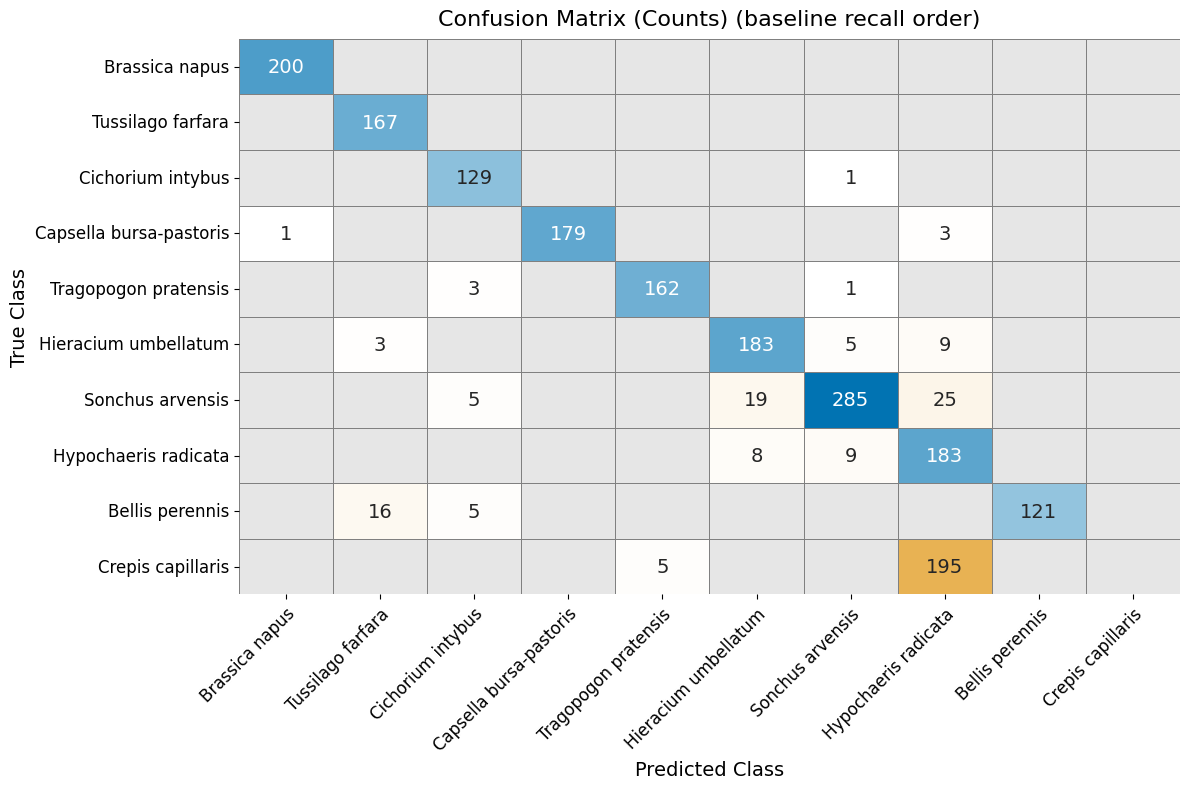

In [20]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, probs_256, y_256, conf_best256 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_best256, idx_to_class, normalize=False, save_path="figures/confmat_M6")


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 7.579156398773193
Mean of batch means: 0.7145817866090869
Mean of batch stds: 0.9557263255119324

Test Accuracy: 0.7201
Test Recall per class:
Class 0 (Bellis perennis): 0.0423
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.4400
Class 7 (Sonchus arvensis): 0.8413
Class 8 (Tragopogon pratensis): 0.8253
Class 9 (Tussilago farfara): 1.0000


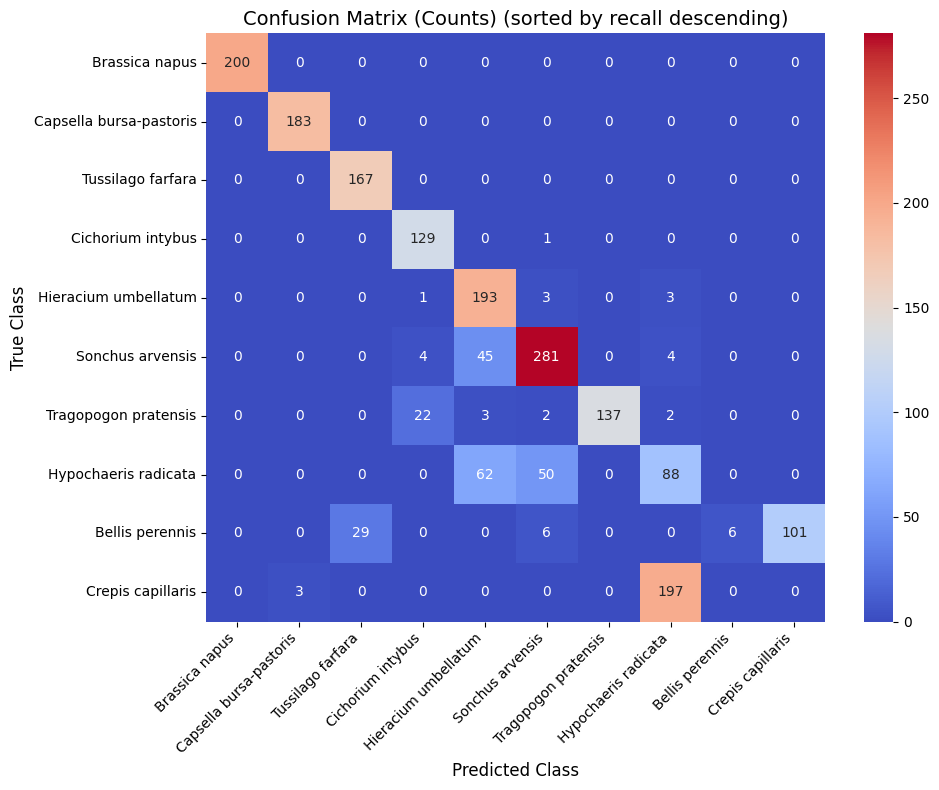

In [21]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_modelmulti_fill_val.pth", map_location=device)
model_base256MLP.load_state_dict(ckpt["model_state_dict"])
model_base256MLP.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256MLP, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Base Model to dense 256-dim & Filling missing size BOOTSTRAP & Validation split

In [22]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
    ,bootstrap_impute_bool=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Validat

In [23]:
seed_everything(SEED, deterministic=True)
model_base256MLP = CNN256WithSizeMLP_multi(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256MLP.parameters(), lr=0.001)

In [4]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [5]:
for name, param in model_base256.named_parameters():
    print(f"{name} | shape={tuple(param.shape)}")
    print(param.data.view(-1)[:10])   # first 10 values
    print("-" * 50)

backbone.conv1.weight | shape=(64, 3, 7, 7)
tensor([-0.0104, -0.0061, -0.0018,  0.0748,  0.0566,  0.0171, -0.0127,  0.0111,
         0.0095, -0.1099], device='cuda:0')
--------------------------------------------------
backbone.bn1.weight | shape=(64,)
tensor([ 2.3487e-01,  2.6626e-01, -5.1096e-08,  5.1870e-01,  3.4404e-09,
         2.2239e-01,  4.2289e-01,  1.3153e-07,  2.5093e-01,  1.5152e-06],
       device='cuda:0')
--------------------------------------------------
backbone.bn1.bias | shape=(64,)
tensor([ 2.3072e-01,  2.5382e-01, -1.0543e-06, -6.6439e-01, -1.6571e-08,
         1.6152e-01,  4.5450e-01, -4.3020e-07,  3.0051e-01, -8.0052e-06],
       device='cuda:0')
--------------------------------------------------
backbone.layer1.0.conv1.weight | shape=(64, 64, 3, 3)
tensor([ 0.0576, -0.0951, -0.0203, -0.0746, -0.7993, -0.2128,  0.0656, -0.0965,
        -0.0121, -0.0070], device='cuda:0')
--------------------------------------------------
backbone.layer1.0.bn1.weight | shape=(64,)

In [6]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_fill_val_boot.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:20<00:00, 10.05it/s]


Epoch 1/40 | Train Loss: 0.3611, Train Acc: 0.8833
| Val Loss: 0.4726, Val Acc: 0.8490
Val Recall per class: tensor([0.9945, 0.9064, 0.9935, 0.8000, 0.9673, 0.9438, 0.0507, 0.8429, 0.9821,
        0.8837])
Saved new best model (Val Acc = 0.8490)


100%|██████████| 202/202 [00:20<00:00,  9.86it/s]


Epoch 2/40 | Train Loss: 0.1510, Train Acc: 0.9505
| Val Loss: 0.5528, Val Acc: 0.8391


100%|██████████| 202/202 [00:19<00:00, 10.17it/s]


...

Epoch 17/40 | Train Loss: 0.0360, Train Acc: 0.9885
| Val Loss: 0.0832, Val Acc: 0.9802


100%|██████████| 202/202 [00:19<00:00, 10.25it/s]


Epoch 18/40 | Train Loss: 0.0247, Train Acc: 0.9910
| Val Loss: 0.9986, Val Acc: 0.8756


100%|██████████| 202/202 [00:19<00:00, 10.28it/s]


Epoch 19/40 | Train Loss: 0.0347, Train Acc: 0.9892
| Val Loss: 0.2875, Val Acc: 0.9387
Early stopping at epoch 19. Best Val Acc = 0.9851 at epoch 11.
Reloaded best model from epoch 11 (Val Acc=0.9851)


In [24]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256MLP
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_modelmulti_fill_val_boot.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:19<00:00, 10.14it/s]


Epoch 1/40 | Train Loss: 0.7479, Train Acc: 0.7488
| Val Loss: 1.8218, Val Acc: 0.6454
Val Recall per class: tensor([0.9724, 0.9181, 0.9804, 0.0278, 0.8497, 1.0000, 0.3841, 0.1143, 0.2857,
        0.8605])
Saved new best model (Val Acc = 0.6454)


100%|██████████| 202/202 [00:20<00:00, 10.07it/s]


Epoch 2/40 | Train Loss: 0.2958, Train Acc: 0.9115
| Val Loss: 3.4364, Val Acc: 0.3744


100%|██████████| 202/202 [00:19<00:00, 10.12it/s]


...

Epoch 21/40 | Train Loss: 0.0472, Train Acc: 0.9872
| Val Loss: 0.1201, Val Acc: 0.9691


100%|██████████| 202/202 [00:20<00:00, 10.03it/s]


Epoch 22/40 | Train Loss: 0.0562, Train Acc: 0.9858
| Val Loss: 0.1810, Val Acc: 0.9505


100%|██████████| 202/202 [00:20<00:00, 10.04it/s]


Epoch 23/40 | Train Loss: 0.0331, Train Acc: 0.9895
| Val Loss: 0.2021, Val Acc: 0.9505
Early stopping at epoch 23. Best Val Acc = 0.9851 at epoch 15.
Reloaded best model from epoch 15 (Val Acc=0.9851)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 10.501511573791504
Mean of batch means: 0.7974957784668344
Mean of batch stds: 1.0212229842045268

Test Accuracy: 0.7503
Test Recall per class:
Class 0 (Bellis perennis): 0.9296
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9727
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9500
Class 6 (Hypochaeris radicata): 0.2500
Class 7 (Sonchus arvensis): 0.6916
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 0.9940


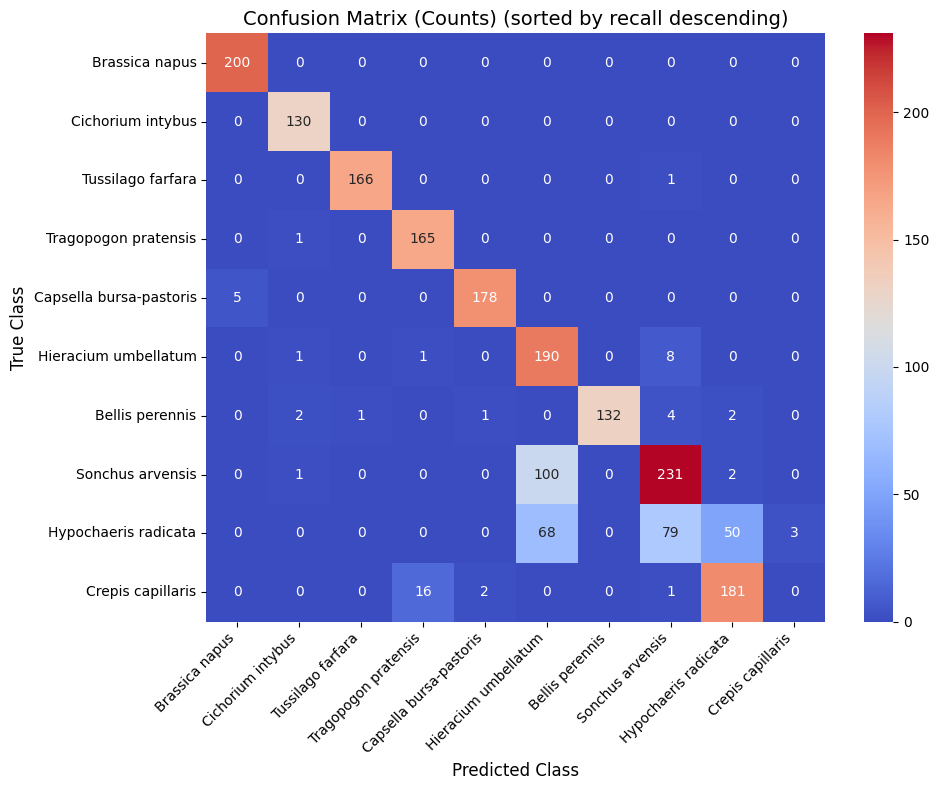

In [7]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val_boot.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 9.427200317382812
Mean of batch means: 0.7371789373335291
Mean of batch stds: 1.0095957068146253

Test Accuracy: 0.7086
Test Recall per class:
Class 0 (Bellis perennis): 0.1268
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9836
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9850
Class 6 (Hypochaeris radicata): 0.2900
Class 7 (Sonchus arvensis): 0.8174
Class 8 (Tragopogon pratensis): 0.8434
Class 9 (Tussilago farfara): 1.0000


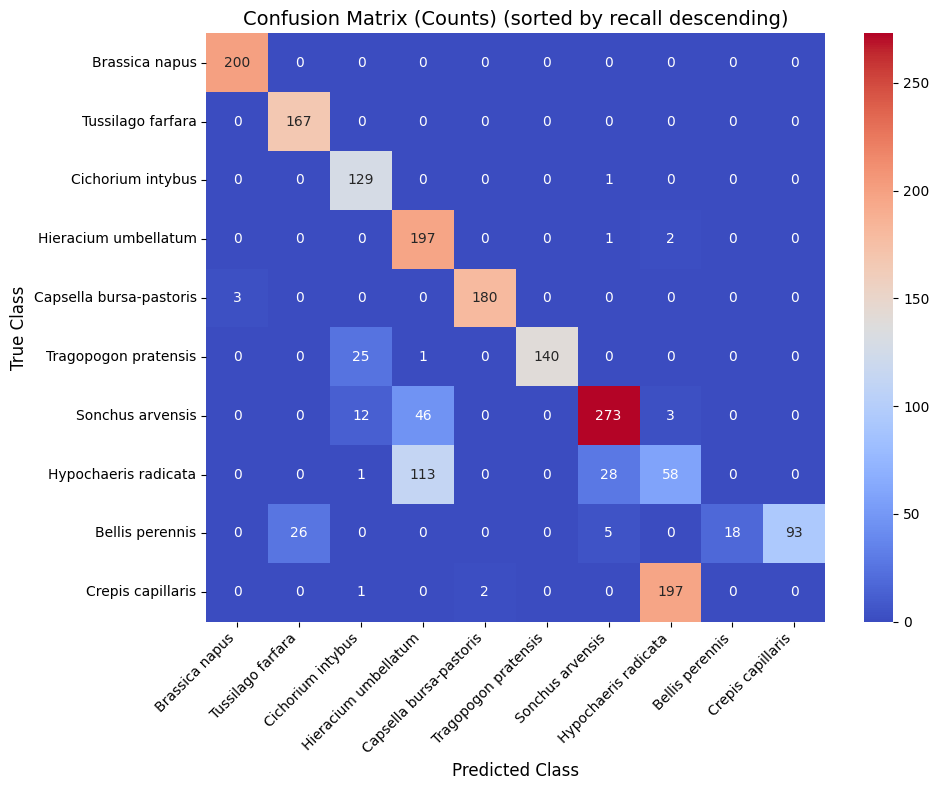

In [25]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_modelmulti_fill_val_boot.pth", map_location=device)
model_base256MLP.load_state_dict(ckpt["model_state_dict"])
model_base256MLP.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256MLP, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Base Model to dense 256-dim & Filling missing size & Validation split & quota

In [35]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Valida

In [36]:
train_dataset[3]

(tensor([[[1.8893, 1.9064, 1.9407,  ..., 2.2318, 1.9064, 1.7352],
          [2.0092, 1.9407, 1.8379,  ..., 2.1119, 1.9749, 1.8893],
          [2.2147, 1.9920, 1.6495,  ..., 1.8722, 2.0434, 2.1462],
          ...,
          [2.0092, 1.9235, 1.8037,  ..., 1.7865, 1.9407, 2.0263],
          [1.9235, 1.8550, 1.7865,  ..., 1.9749, 1.8893, 1.8208],
          [1.8550, 1.8208, 1.7865,  ..., 2.0948, 1.8722, 1.7180]],
 
         [[1.7458, 1.7633, 1.7983,  ..., 2.1485, 1.8158, 1.6057],
          [1.8859, 1.8158, 1.7108,  ..., 1.9909, 1.8683, 1.7808],
          [2.1134, 1.8859, 1.5532,  ..., 1.7458, 1.9384, 2.0609],
          ...,
          [1.9909, 1.9034, 1.7808,  ..., 1.6933, 1.8508, 1.9384],
          [1.9034, 1.8333, 1.7633,  ..., 1.8859, 1.7983, 1.7283],
          [1.8333, 1.7983, 1.7633,  ..., 2.0084, 1.7808, 1.6232]],
 
         [[2.1171, 2.1346, 2.1694,  ..., 2.4483, 2.0997, 1.8731],
          [2.2391, 2.1694, 2.0648,  ..., 2.3088, 2.1346, 2.0474],
          [2.4483, 2.2217, 1.8905,  ...,

In [37]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10,size_dim=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [38]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_fill_val_quota.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:20<00:00,  9.97it/s]


Epoch 1/40 | Train Loss: 0.4201, Train Acc: 0.8689
| Val Loss: 0.8158, Val Acc: 0.7512
Val Recall per class: tensor([0.7735, 1.0000, 0.9085, 0.4167, 1.0000, 0.8375, 0.2391, 0.4214, 0.9643,
        0.8605])
Saved new best model (Val Acc = 0.7512)


100%|██████████| 202/202 [00:20<00:00, 10.08it/s]


Epoch 2/40 | Train Loss: 0.1848, Train Acc: 0.9407
| Val Loss: 1.1921, Val Acc: 0.6856


100%|██████████| 202/202 [00:19<00:00, 10.17it/s]


...

Epoch 11/40 | Train Loss: 0.0338, Train Acc: 0.9892
| Val Loss: 1.8890, Val Acc: 0.7661


100%|██████████| 202/202 [00:20<00:00, 10.07it/s]


Epoch 12/40 | Train Loss: 0.0479, Train Acc: 0.9848
| Val Loss: 0.3350, Val Acc: 0.9047


100%|██████████| 202/202 [00:19<00:00, 10.12it/s]


Epoch 13/40 | Train Loss: 0.0738, Train Acc: 0.9776
| Val Loss: 0.4022, Val Acc: 0.8830
Early stopping at epoch 13. Best Val Acc = 0.9851 at epoch 5.
Reloaded best model from epoch 5 (Val Acc=0.9851)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 10.359058380126953
Mean of batch means: 0.7867879251964757
Mean of batch stds: 1.065523265815172

Test Accuracy: 0.7201
Test Recall per class:
Class 0 (Bellis perennis): 0.8169
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.7486
Class 3 (Cichorium intybus): 0.9769
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9850
Class 6 (Hypochaeris radicata): 0.8250
Class 7 (Sonchus arvensis): 0.3293
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 0.9940


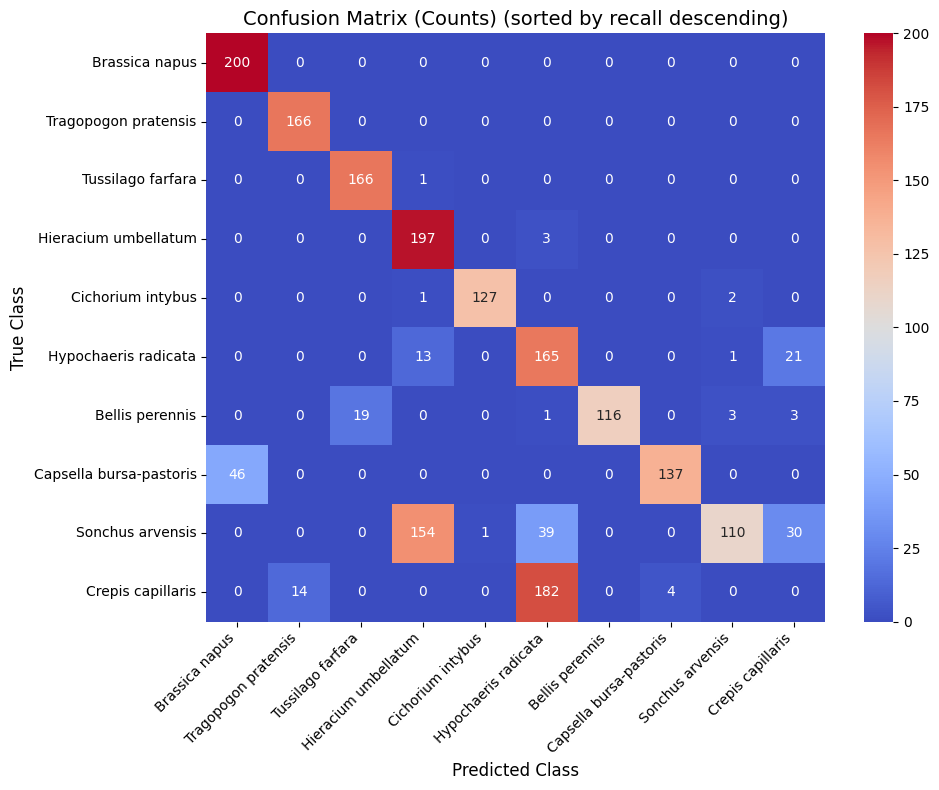

In [39]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val_quota.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Base Model to dense 256-dim & Filling missing size & Validation split & Augmentation & quota

In [40]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [41]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10,size_dim=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [ ]:
BATCHSIZE = 3

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_fill_val_aug_quota.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:22<00:00,  9.69it/s]


Epoch 1/40 | Train Loss: 0.4059, Train Acc: 0.8658
| Val Loss: 1.8893, Val Acc: 0.5500
Val Recall per class: tensor([0.2130, 0.9890, 0.8000, 0.1088, 0.5482, 0.2092, 0.2410, 0.9947, 0.3114,
        0.9942])
Saved new best model (Val Acc = 0.5500)


100%|██████████| 218/218 [00:22<00:00,  9.69it/s]


Epoch 2/40 | Train Loss: 0.2015, Train Acc: 0.9375
| Val Loss: 0.3950, Val Acc: 0.8695
Saved new best model (Val Acc = 0.8695)


100%|██████████| 218/218 [00:22<00:00,  9.59it/s]


...

Epoch 19/40 | Train Loss: 0.0426, Train Acc: 0.9861
| Val Loss: 0.4176, Val Acc: 0.8810


100%|██████████| 218/218 [00:22<00:00,  9.51it/s]


Epoch 20/40 | Train Loss: 0.0565, Train Acc: 0.9836
| Val Loss: 2.0050, Val Acc: 0.7552
Val Recall per class: tensor([0.9941, 0.9834, 0.9730, 0.5440, 0.9578, 0.6536, 0.4699, 0.0476, 1.0000,
        0.9942])


100%|██████████| 218/218 [00:23<00:00,  9.15it/s]


Epoch 21/40 | Train Loss: 0.0260, Train Acc: 0.9911
| Val Loss: 0.0803, Val Acc: 0.9747
Early stopping at epoch 21. Best Val Acc = 0.9862 at epoch 13.
Reloaded best model from epoch 13 (Val Acc=0.9862)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 9.859895706176758
Mean of batch means: 0.745831555030385
Mean of batch stds: 1.0142077647271703

Test Accuracy: 0.8158
Test Recall per class:
Class 0 (Bellis perennis): 0.9085
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0100
Class 5 (Hieracium umbellatum): 0.8550
Class 6 (Hypochaeris radicata): 0.8150
Class 7 (Sonchus arvensis): 0.7754
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 0.9940


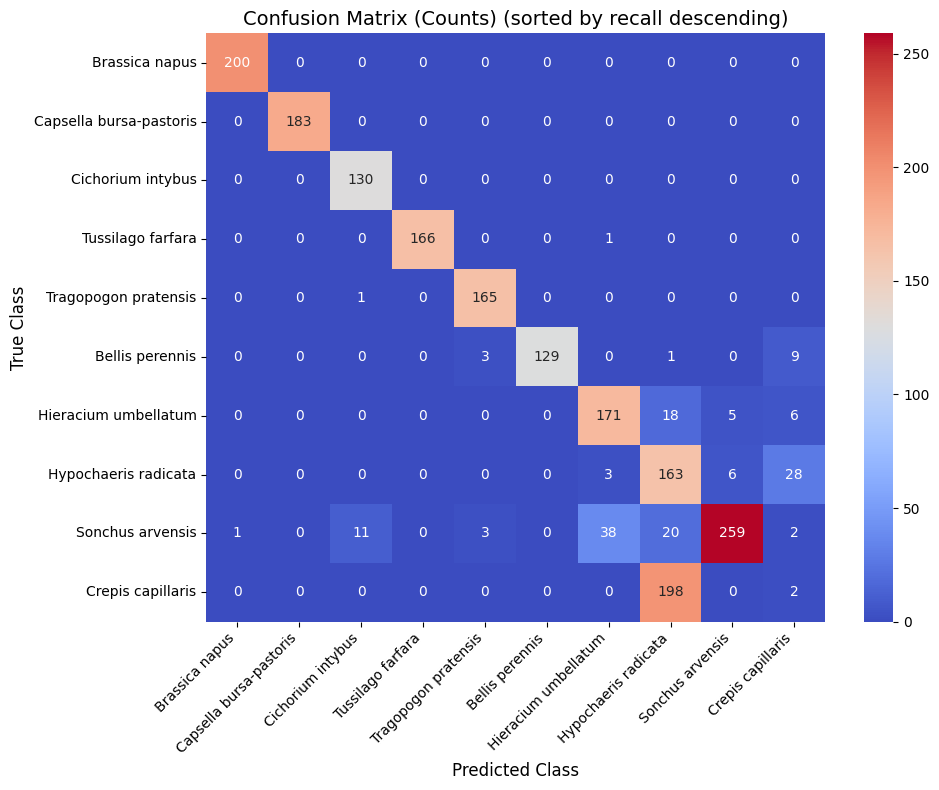

In [43]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val_aug_quota.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# Focal loss

## Choosing optimal gamma
- gamma=1, alpha=None
- gamma=2, alpha=None

- alpha = 2,3,5

Train on dataset with filled missing size measurements and validation dataset

### gamma = 1, alpha = None

### Augmentation

In [46]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [21]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)
loss_fn = FocalLoss(gamma=1.0)
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [48]:
for name, param in model_base256.named_parameters():
    print(f"{name} | shape={tuple(param.shape)}")
    print(param.data.view(-1)[:10])   # first 10 values
    print("-" * 50)

backbone.conv1.weight | shape=(64, 3, 7, 7)
tensor([-0.0104, -0.0061, -0.0018,  0.0748,  0.0566,  0.0171, -0.0127,  0.0111,
         0.0095, -0.1099], device='cuda:0')
--------------------------------------------------
backbone.bn1.weight | shape=(64,)
tensor([ 2.3487e-01,  2.6626e-01, -5.1096e-08,  5.1870e-01,  3.4404e-09,
         2.2239e-01,  4.2289e-01,  1.3153e-07,  2.5093e-01,  1.5152e-06],
       device='cuda:0')
--------------------------------------------------
backbone.bn1.bias | shape=(64,)
tensor([ 2.3072e-01,  2.5382e-01, -1.0543e-06, -6.6439e-01, -1.6571e-08,
         1.6152e-01,  4.5450e-01, -4.3020e-07,  3.0051e-01, -8.0052e-06],
       device='cuda:0')
--------------------------------------------------
backbone.layer1.0.conv1.weight | shape=(64, 64, 3, 3)
tensor([ 0.0576, -0.0951, -0.0203, -0.0746, -0.7993, -0.2128,  0.0656, -0.0965,
        -0.0121, -0.0070], device='cuda:0')
--------------------------------------------------
backbone.layer1.0.bn1.weight | shape=(64,)

In [49]:
print("Loss function:", loss_fn)

Loss function: FocalLoss()


In [50]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_focal_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:22<00:00,  9.53it/s]


Epoch 1/40 | Train Loss: 0.2408, Train Acc: 0.8828
| Val Loss: 0.5170, Val Acc: 0.7868
Val Recall per class: tensor([0.6213, 1.0000, 0.9243, 0.9741, 0.0904, 0.7908, 0.9518, 0.8466, 0.5928,
        1.0000])
Saved new best model (Val Acc = 0.7868)


100%|██████████| 218/218 [00:22<00:00,  9.68it/s]


Epoch 2/40 | Train Loss: 0.1047, Train Acc: 0.9455
| Val Loss: 0.4186, Val Acc: 0.8293
Saved new best model (Val Acc = 0.8293)


100%|██████████| 218/218 [00:22<00:00,  9.65it/s]


...

Epoch 21/40 | Train Loss: 0.0352, Train Acc: 0.9822
| Val Loss: 0.0796, Val Acc: 0.9678


100%|██████████| 218/218 [00:23<00:00,  9.43it/s]


Epoch 22/40 | Train Loss: 0.0173, Train Acc: 0.9915
| Val Loss: 0.0335, Val Acc: 0.9851


100%|██████████| 218/218 [00:23<00:00,  9.45it/s]


Epoch 23/40 | Train Loss: 0.0241, Train Acc: 0.9881
| Val Loss: 0.0516, Val Acc: 0.9776
Early stopping at epoch 23. Best Val Acc = 0.9862 at epoch 15.
Reloaded best model from epoch 15 (Val Acc=0.9862)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.725157737731934
Mean of batch means: 0.7143316640228522
Mean of batch stds: 0.8647256386084635

Test Accuracy: 0.8132
Test Recall per class:
Class 0 (Bellis perennis): 0.9437
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 0.9769
Class 4 (Crepis capillaris): 0.0550
Class 5 (Hieracium umbellatum): 0.9400
Class 6 (Hypochaeris radicata): 0.4300
Class 7 (Sonchus arvensis): 0.9012
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


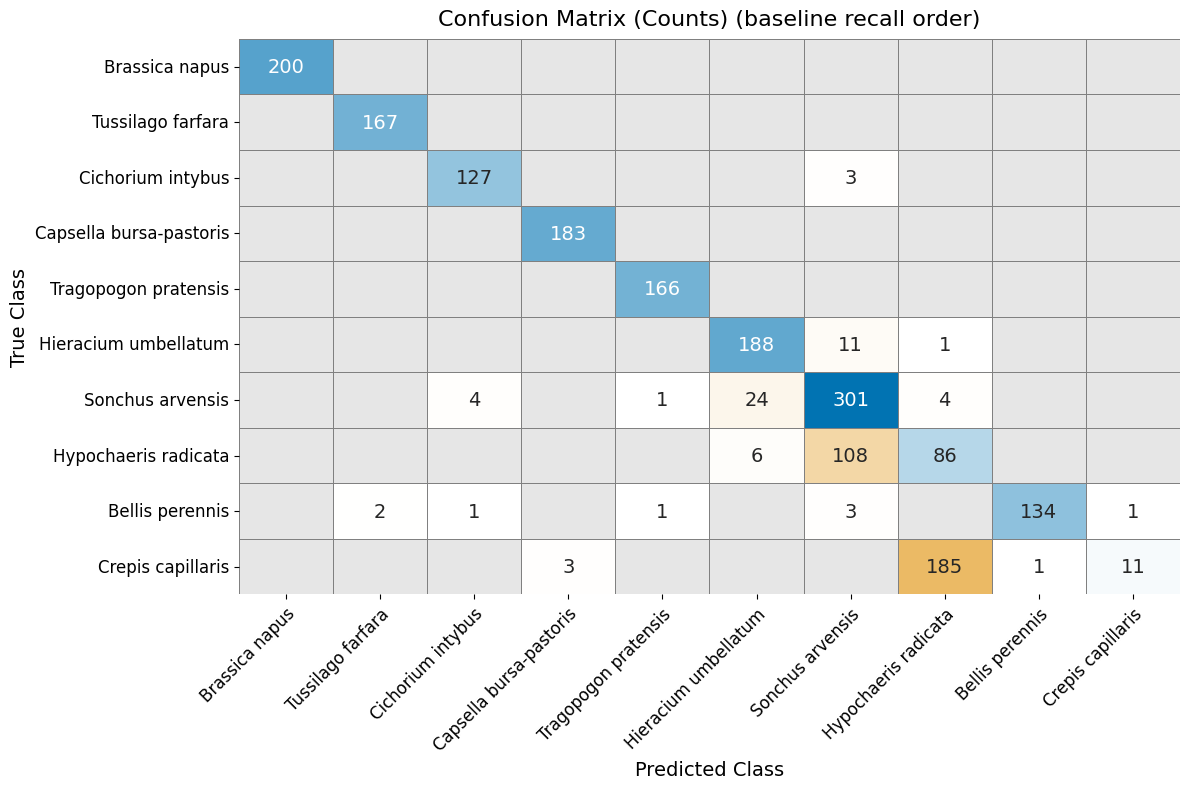

In [22]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_focal_fill_val_aug.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, probs_M9,ys_M9, conf_M9 = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf_M9, idx_to_class, normalize=False)

In [24]:
recall_per_class, accuracy

(tensor([0.9437, 1.0000, 1.0000, 0.9769, 0.0550, 0.9400, 0.4300, 0.9012, 1.0000,
         1.0000]),
 0.8132153749465942)

### gamma = 2.0, alpha = None

In [52]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)
loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [53]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_focal2_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:22<00:00,  9.61it/s]


Epoch 1/40 | Train Loss: 0.1900, Train Acc: 0.8749
| Val Loss: 0.2249, Val Acc: 0.8397
Val Recall per class: tensor([0.9941, 0.9669, 0.9514, 0.2280, 0.9699, 0.5882, 0.8373, 0.9894, 0.9042,
        0.9942])
Saved new best model (Val Acc = 0.8397)


100%|██████████| 218/218 [00:22<00:00,  9.60it/s]


Epoch 2/40 | Train Loss: 0.0898, Train Acc: 0.9313
| Val Loss: 0.1841, Val Acc: 0.8644
Saved new best model (Val Acc = 0.8644)


100%|██████████| 218/218 [00:23<00:00,  9.42it/s]


...

Epoch 17/40 | Train Loss: 0.0088, Train Acc: 0.9917
| Val Loss: 0.1544, Val Acc: 0.9063


100%|██████████| 218/218 [00:23<00:00,  9.13it/s]


Epoch 18/40 | Train Loss: 0.0258, Train Acc: 0.9793
| Val Loss: 0.1136, Val Acc: 0.9534


100%|██████████| 218/218 [00:23<00:00,  9.42it/s]


Epoch 19/40 | Train Loss: 0.0149, Train Acc: 0.9858
| Val Loss: 0.0235, Val Acc: 0.9799
Early stopping at epoch 19. Best Val Acc = 0.9828 at epoch 11.
Reloaded best model from epoch 11 (Val Acc=0.9828)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.449967384338379
Mean of batch means: 0.7736976088070479
Mean of batch stds: 0.9549817198612651

Test Accuracy: 0.7898
Test Recall per class:
Class 0 (Bellis perennis): 0.7676
Class 1 (Brassica napus): 0.9950
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.4750
Class 7 (Sonchus arvensis): 0.8263
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


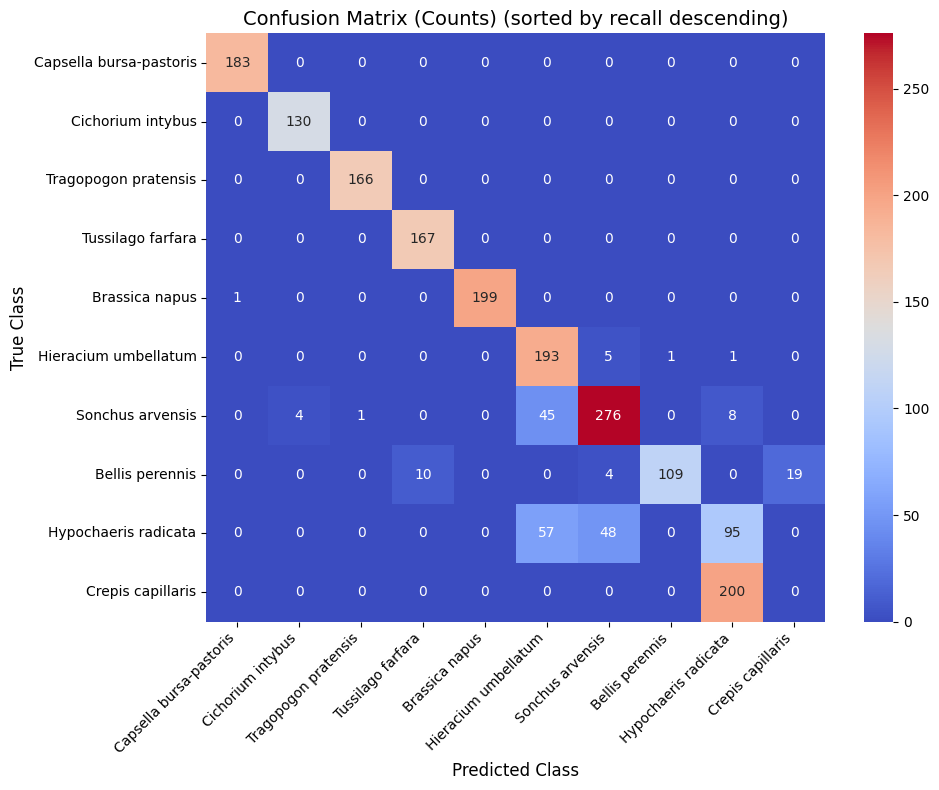

In [54]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_focal2_fill_val_aug.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

### Non-Augmentation

In [5]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Valida

In [56]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)
loss_fn = FocalLoss(gamma=1.0)
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [57]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_focal_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:19<00:00, 10.13it/s]


Epoch 1/40 | Train Loss: 0.2612, Train Acc: 0.8680
| Val Loss: 0.2056, Val Acc: 0.8985
Val Recall per class: tensor([0.9890, 0.8713, 1.0000, 0.7389, 1.0000, 0.9563, 0.5290, 0.9500, 0.9940,
        0.9244])
Saved new best model (Val Acc = 0.8985)


100%|██████████| 202/202 [00:20<00:00,  9.86it/s]


Epoch 2/40 | Train Loss: 0.1078, Train Acc: 0.9375
| Val Loss: 0.4384, Val Acc: 0.8422


100%|██████████| 202/202 [00:20<00:00,  9.81it/s]


...

Epoch 10/40 | Train Loss: 0.0594, Train Acc: 0.9706
| Val Loss: 0.1175, Val Acc: 0.9363
Val Recall per class: tensor([0.9945, 1.0000, 0.9412, 0.6333, 1.0000, 0.9812, 0.8841, 0.9857, 0.9821,
        0.9826])


100%|██████████| 202/202 [00:19<00:00, 10.11it/s]


Epoch 11/40 | Train Loss: 0.0350, Train Acc: 0.9799
| Val Loss: 0.0774, Val Acc: 0.9660


100%|██████████| 202/202 [00:20<00:00, 10.08it/s]


Epoch 12/40 | Train Loss: 0.0243, Train Acc: 0.9873
| Val Loss: 0.0373, Val Acc: 0.9790
Early stopping at epoch 12. Best Val Acc = 0.9814 at epoch 4.
Reloaded best model from epoch 4 (Val Acc=0.9814)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.194999694824219
Mean of batch means: 0.8456680374067338
Mean of batch stds: 1.0691500540639534

Test Accuracy: 0.7622
Test Recall per class:
Class 0 (Bellis perennis): 0.6338
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9500
Class 6 (Hypochaeris radicata): 0.2600
Class 7 (Sonchus arvensis): 0.8623
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


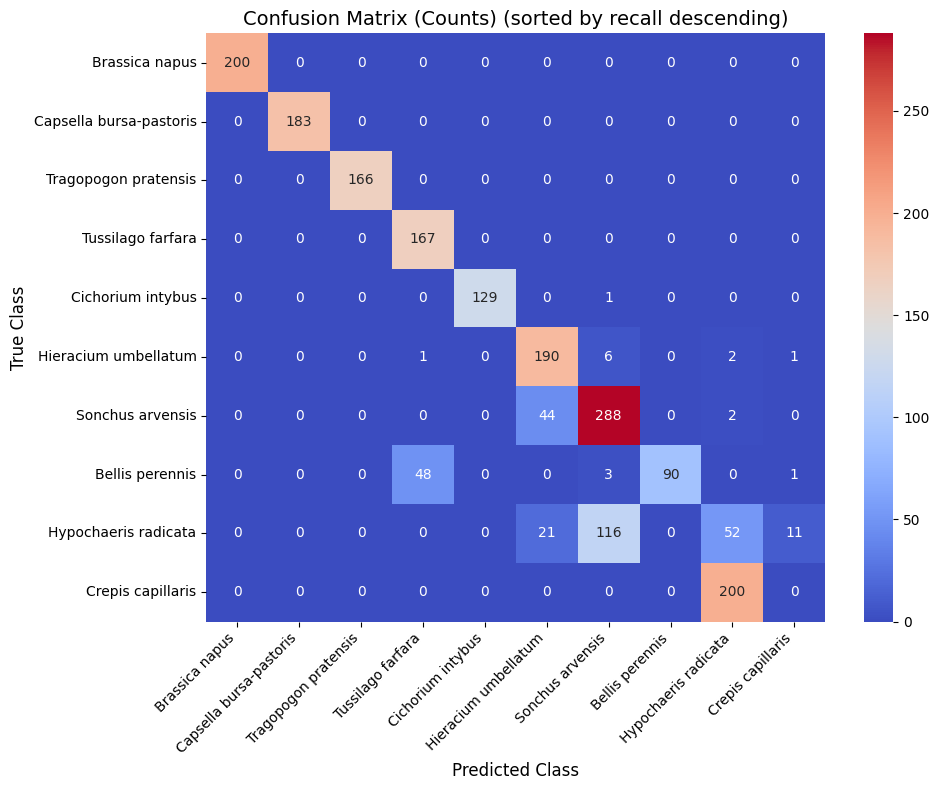

In [58]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_focal_fill_val.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [6]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)
loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [60]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="base_model_focal2_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:19<00:00, 10.13it/s]


Epoch 1/40 | Train Loss: 0.1849, Train Acc: 0.8802
| Val Loss: 0.1531, Val Acc: 0.9127
Val Recall per class: tensor([0.9724, 0.9883, 0.9935, 0.9167, 0.9020, 0.9250, 0.5870, 0.7643, 0.9940,
        1.0000])
Saved new best model (Val Acc = 0.9127)


100%|██████████| 202/202 [00:20<00:00, 10.01it/s]


Epoch 2/40 | Train Loss: 0.0841, Train Acc: 0.9347
| Val Loss: 0.6139, Val Acc: 0.5903


100%|██████████| 202/202 [00:20<00:00,  9.97it/s]


...

Epoch 28/40 | Train Loss: 0.0093, Train Acc: 0.9890
| Val Loss: 0.0232, Val Acc: 0.9870


100%|██████████| 202/202 [00:20<00:00,  9.96it/s]


Epoch 29/40 | Train Loss: 0.0216, Train Acc: 0.9836
| Val Loss: 0.0292, Val Acc: 0.9845


100%|██████████| 202/202 [00:19<00:00, 10.14it/s]


Epoch 30/40 | Train Loss: 0.0113, Train Acc: 0.9916
| Val Loss: 0.0134, Val Acc: 0.9920
Val Recall per class: tensor([1.0000, 0.9942, 0.9935, 0.9833, 0.9935, 0.9750, 1.0000, 0.9786, 1.0000,
        1.0000])
Early stopping at epoch 30. Best Val Acc = 0.9932 at epoch 22.
Reloaded best model from epoch 22 (Val Acc=0.9932)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 10.537983894348145
Mean of batch means: 0.7555135429882612
Mean of batch stds: 0.9290549667155157

Test Accuracy: 0.7711
Test Recall per class:
Class 0 (Bellis perennis): 0.4085
Class 1 (Brassica napus): 0.9950
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9800
Class 6 (Hypochaeris radicata): 0.7950
Class 7 (Sonchus arvensis): 0.6766
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


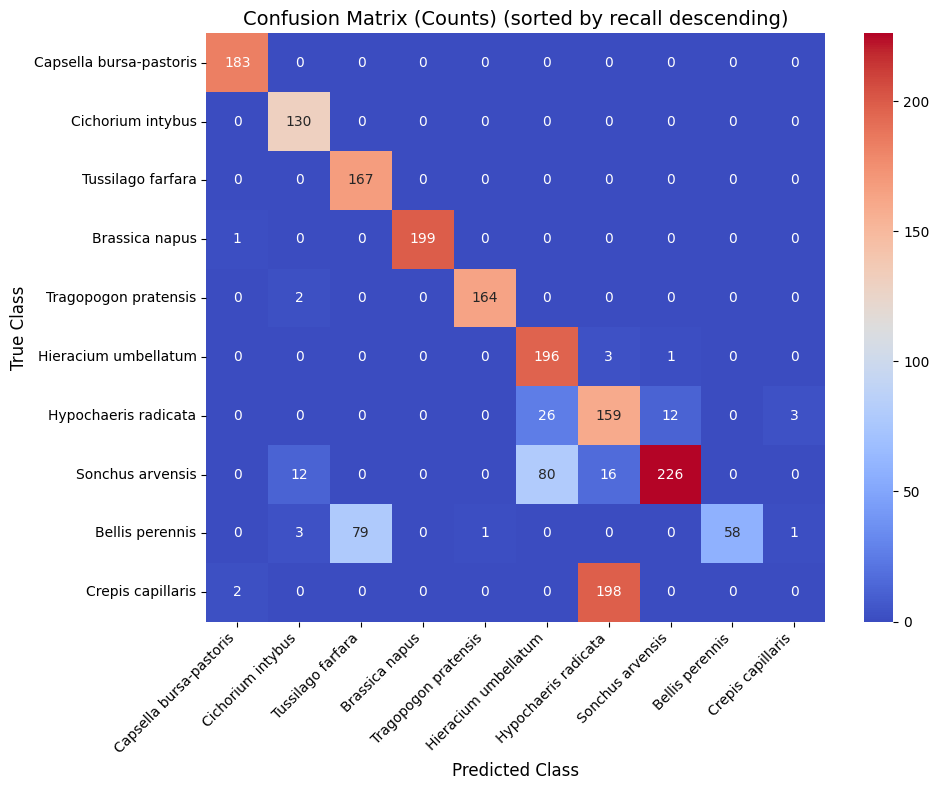

In [7]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_focal2_fill_val.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## 0 gamma + alpha special for class 4

In [15]:
# base weights (inverse freq or effective num)
alpha = train_dataset.get_effective_num_weights(beta=0.999, device=device)

# boost Crepis capillaris (class 4)
boost = 2.0  # try 2, 3, 5
alpha[4] *= boost

alpha

AttributeError: 'Subset' object has no attribute 'get_effective_num_weights'

In [ ]:
seed_everything(SEED, deterministic=True)
model_base256 = CNN256WithSizeMLP(num_classes=10).to(device)

loss_fn = FocalLoss(gamma=0.0, alpha = alpha)
optimizer = torch.optim.Adam(model_base256.parameters(), lr=0.001)

In [ ]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model_base256
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="256base_model_focal0a_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

In [ ]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/base_model_focal2_fill_val.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# 256-dim + MLP (multi layers)

# ConvNext + val + aug + quota

In [50]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=True
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [25]:
train_dataset[0]

(tensor([[[1.3584, 1.5297, 1.9064,  ..., 1.8208, 1.8722, 1.9064],
          [1.5125, 1.6153, 1.8722,  ..., 1.8037, 1.8722, 1.9064],
          [1.8379, 1.8379, 1.8208,  ..., 1.7694, 1.8893, 1.9407],
          ...,
          [1.6667, 1.5297, 1.2385,  ..., 1.7009, 1.7865, 1.8208],
          [1.6153, 1.5297, 1.3584,  ..., 1.4783, 2.0092, 2.2318],
          [1.5810, 1.5297, 1.4098,  ..., 1.3755, 2.0605, 2.2489]],
 
         [[1.2556, 1.4307, 1.8158,  ..., 1.6408, 1.6933, 1.7283],
          [1.4132, 1.5182, 1.7808,  ..., 1.6232, 1.7108, 1.7458],
          [1.7458, 1.7458, 1.7283,  ..., 1.6232, 1.7458, 1.7983],
          ...,
          [1.5357, 1.4132, 1.1155,  ..., 1.6057, 1.6933, 1.7283],
          [1.5007, 1.4132, 1.2381,  ..., 1.3957, 1.9734, 2.2185],
          [1.4657, 1.4132, 1.2906,  ..., 1.3081, 2.0959, 2.4286]],
 
         [[1.5942, 1.7685, 2.1520,  ..., 2.0125, 2.0648, 2.0997],
          [1.7511, 1.8557, 2.1171,  ..., 1.9951, 2.0648, 2.0997],
          [2.0823, 2.0823, 2.0648,  ...,

In [52]:
image, size, label = train_dataset[0]

print("Image shape:", image.shape)
print("Size tensor:", size)
print("Size tensor shape:", size.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Size tensor: tensor([34.2380, 32.3213,  0.9440])
Size tensor shape: torch.Size([3])
Label: tensor(6)


In [53]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=3, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [54]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="convnext_fill_val_quota.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=30
    ,early_stopping_patience=8
)

 50%|█████     | 109/218 [00:27<00:27,  4.00it/s]


KeyboardInterrupt: 


=== Backbone Feature Inspection ===
Min of mins: -14.622772216796875
Max of maxs: 24.179859161376953
Mean of batch means: 0.022423578945339702
Mean of batch stds: 1.1185343617298564

Test Accuracy: 0.8345
Test Recall per class:
Class 0 (Bellis perennis): 0.8662
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.4250
Class 5 (Hieracium umbellatum): 0.8650
Class 6 (Hypochaeris radicata): 0.2700
Class 7 (Sonchus arvensis): 0.9790
Class 8 (Tragopogon pratensis): 0.9819
Class 9 (Tussilago farfara): 0.9940


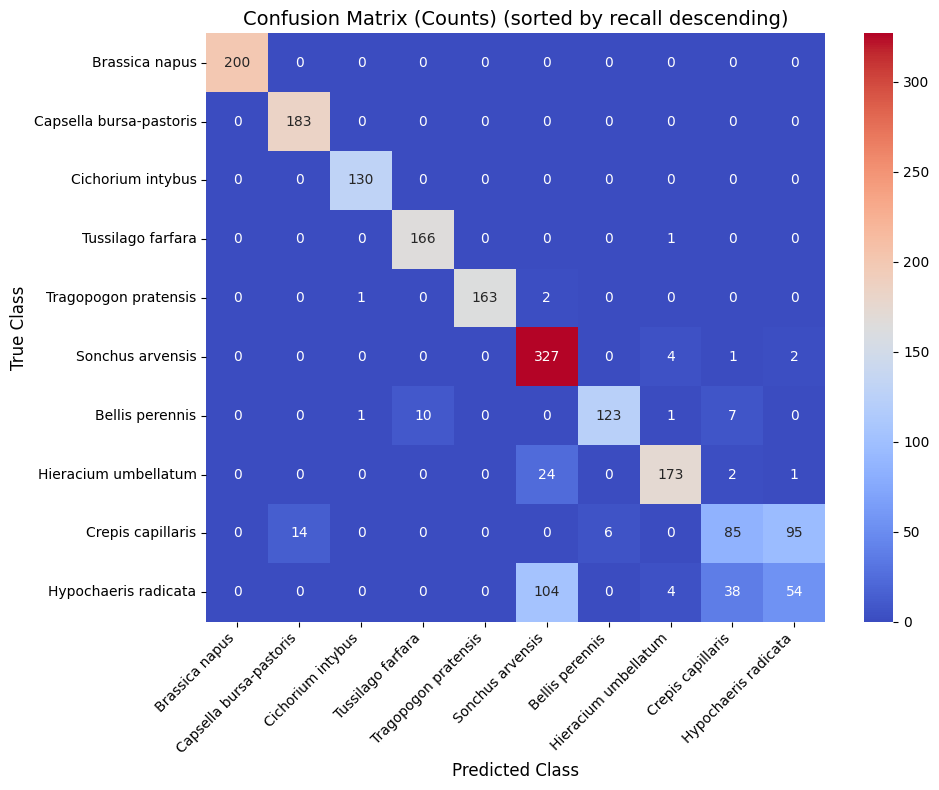

In [ ]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val_quota.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# ConvNext + val

In [16]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Valida

In [17]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [18]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="convnext_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:49<00:00,  4.06it/s]


Epoch 1/40 | Train Loss: 0.3654, Train Acc: 0.8802
| Val Loss: 0.1882, Val Acc: 0.9412
Val Recall per class: tensor([1.0000, 0.9766, 0.9935, 0.8722, 1.0000, 0.9937, 0.6667, 0.8643, 0.9940,
        1.0000])
Saved new best model (Val Acc = 0.9412)


100%|██████████| 202/202 [00:49<00:00,  4.08it/s]


Epoch 2/40 | Train Loss: 0.0999, Train Acc: 0.9690
| Val Loss: 0.0249, Val Acc: 0.9920
Saved new best model (Val Acc = 0.9920)


100%|██████████| 202/202 [00:53<00:00,  3.78it/s]


...

Epoch 29/40 | Train Loss: 0.0190, Train Acc: 0.9954
| Val Loss: 0.0786, Val Acc: 0.9734


100%|██████████| 202/202 [01:10<00:00,  2.86it/s]


Epoch 30/40 | Train Loss: 0.0068, Train Acc: 0.9977
| Val Loss: 0.0255, Val Acc: 0.9932
Val Recall per class: tensor([1.0000, 0.9942, 0.9935, 0.9833, 1.0000, 0.9875, 0.9855, 0.9857, 1.0000,
        1.0000])


100%|██████████| 202/202 [01:06<00:00,  3.02it/s]


Epoch 31/40 | Train Loss: 0.0005, Train Acc: 0.9998
| Val Loss: 0.0187, Val Acc: 0.9957
Early stopping at epoch 31. Best Val Acc = 0.9975 at epoch 23.
Reloaded best model from epoch 23 (Val Acc=0.9975)



=== Backbone Feature Inspection ===
Min of mins: -10.834009170532227
Max of maxs: 16.42815589904785
Mean of batch means: 0.018412627378997744
Mean of batch stds: 1.106119463678266

Test Accuracy: 0.7997
Test Recall per class:
Class 0 (Bellis perennis): 0.6620
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0600
Class 5 (Hieracium umbellatum): 0.8650
Class 6 (Hypochaeris radicata): 0.4500
Class 7 (Sonchus arvensis): 0.9671
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


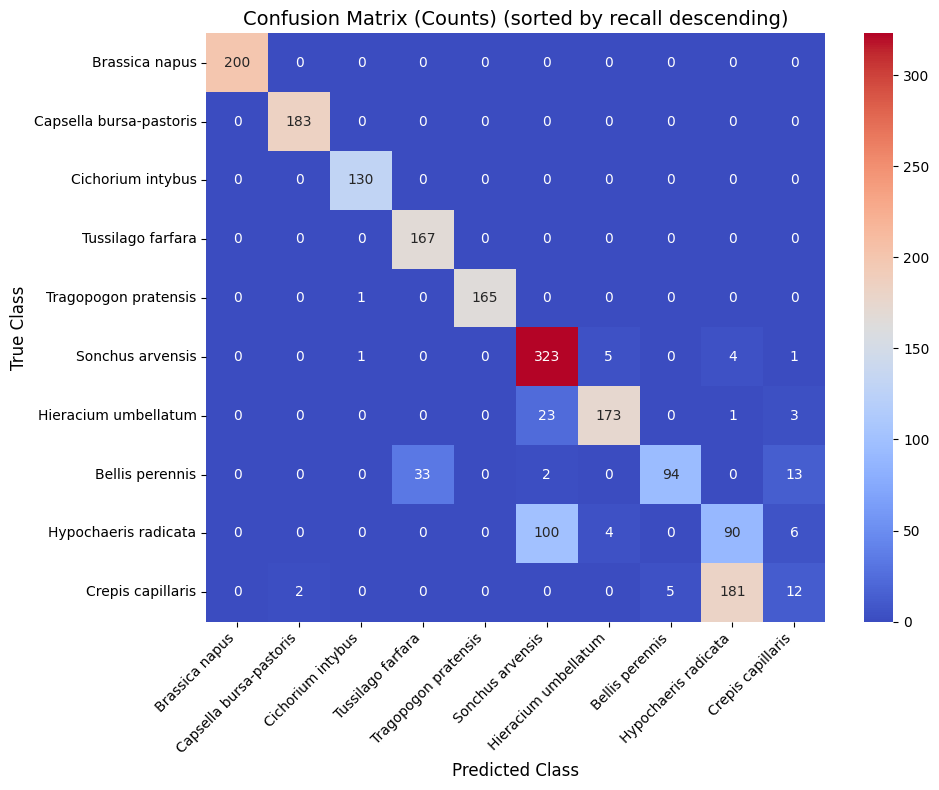

In [19]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# ConvNext + val + aug

In [3]:
seed_everything(SEED, deterministic=True)
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [4]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [5]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="convnext_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

  0%|          | 0/218 [00:00<?, ?it/s]

100%|██████████| 218/218 [00:59<00:00,  3.66it/s]


Epoch 1/40 | Train Loss: 0.3696, Train Acc: 0.8784
| Val Acc: 0.8937
Val Recall per class: tensor([1.0000, 0.9945, 0.9622, 0.1451, 0.9940, 0.9608, 0.9880, 1.0000, 0.9820,
        1.0000])
Saved new best model (Val Acc = 0.8937)


100%|██████████| 218/218 [00:54<00:00,  4.02it/s]


Epoch 2/40 | Train Loss: 0.0863, Train Acc: 0.9736
| Val Acc: 0.9707
Saved new best model (Val Acc = 0.9707)


...

Epoch 15/40 | Train Loss: 0.0120, Train Acc: 0.9966
| Val Acc: 0.9638
Val Recall per class: tensor([1.0000, 0.9503, 0.9892, 0.9896, 1.0000, 0.9673, 0.9940, 0.7725, 0.9940,
        1.0000])


100%|██████████| 218/218 [01:17<00:00,  2.80it/s]


Epoch 16/40 | Train Loss: 0.0220, Train Acc: 0.9932
| Val Acc: 0.9856


100%|██████████| 218/218 [01:23<00:00,  2.62it/s]


Epoch 17/40 | Train Loss: 0.0224, Train Acc: 0.9932
| Val Acc: 0.9782
Early stopping at epoch 17. Best Val Acc = 0.9966 at epoch 9.
Reloaded best model from epoch 9 (Val Acc=0.9966)



=== Backbone Feature Inspection ===
Min of mins: -13.187943458557129
Max of maxs: 18.59029769897461
Mean of batch means: 0.027836144504854915
Mean of batch stds: 1.2281185271310024

Test Accuracy: 0.8892
Test Recall per class:
Class 0 (Bellis perennis): 0.9366
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.4300
Class 5 (Hieracium umbellatum): 0.9350
Class 6 (Hypochaeris radicata): 0.7650
Class 7 (Sonchus arvensis): 0.9162
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 0.9940


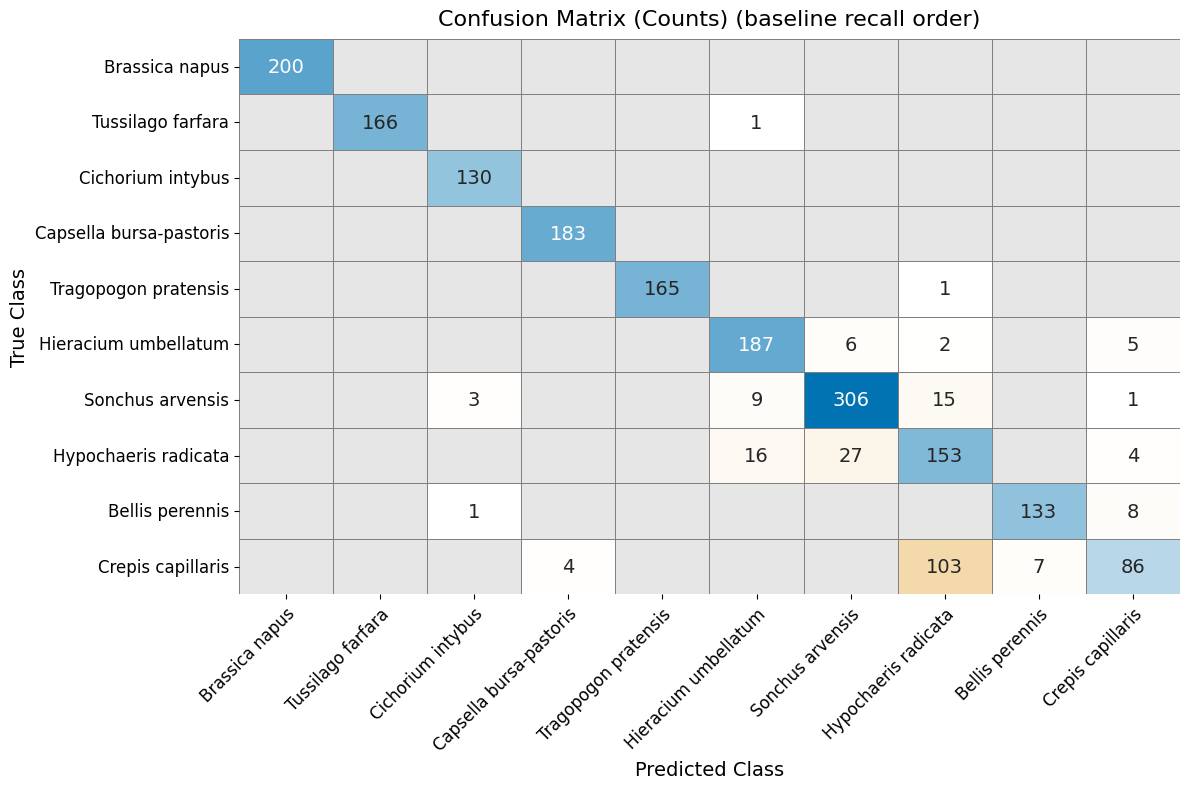

In [7]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val_aug.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, probs, ys, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# ConvNext + val + aug + bootstrap

In [34]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=False
    ,bootstrap_impute_bool=True
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [35]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [36]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="convnext_fill_val_boot.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [00:54<00:00,  4.01it/s]


Epoch 1/40 | Train Loss: 0.3881, Train Acc: 0.8690
| Val Loss: 0.0615, Val Acc: 0.9793
Val Recall per class: tensor([1.0000, 0.9945, 0.9784, 0.9119, 1.0000, 0.9739, 0.9759, 0.9735, 0.9940,
        1.0000])
Saved new best model (Val Acc = 0.9793)


100%|██████████| 218/218 [00:54<00:00,  4.01it/s]


Epoch 2/40 | Train Loss: 0.0824, Train Acc: 0.9733
| Val Loss: 0.2591, Val Acc: 0.9259


100%|██████████| 218/218 [01:04<00:00,  3.37it/s]


...

Epoch 15/40 | Train Loss: 0.0423, Train Acc: 0.9858
| Val Loss: 0.0482, Val Acc: 0.9885
Val Recall per class: tensor([1.0000, 0.9834, 0.9838, 0.9948, 1.0000, 1.0000, 0.9578, 0.9735, 0.9940,
        1.0000])


100%|██████████| 218/218 [01:14<00:00,  2.91it/s]


Epoch 16/40 | Train Loss: 0.0084, Train Acc: 0.9978
| Val Loss: 0.0431, Val Acc: 0.9897


100%|██████████| 218/218 [01:19<00:00,  2.74it/s]


Epoch 17/40 | Train Loss: 0.0288, Train Acc: 0.9912
| Val Loss: 0.1258, Val Acc: 0.9730
Early stopping at epoch 17. Best Val Acc = 0.9954 at epoch 9.
Reloaded best model from epoch 9 (Val Acc=0.9954)



=== Backbone Feature Inspection ===
Min of mins: -13.263544082641602
Max of maxs: 18.445526123046875
Mean of batch means: 0.021382223242191505
Mean of batch stds: 1.1183133789750397

Test Accuracy: 0.8039
Test Recall per class:
Class 0 (Bellis perennis): 0.6549
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0200
Class 5 (Hieracium umbellatum): 0.9550
Class 6 (Hypochaeris radicata): 0.5050
Class 7 (Sonchus arvensis): 0.9281
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


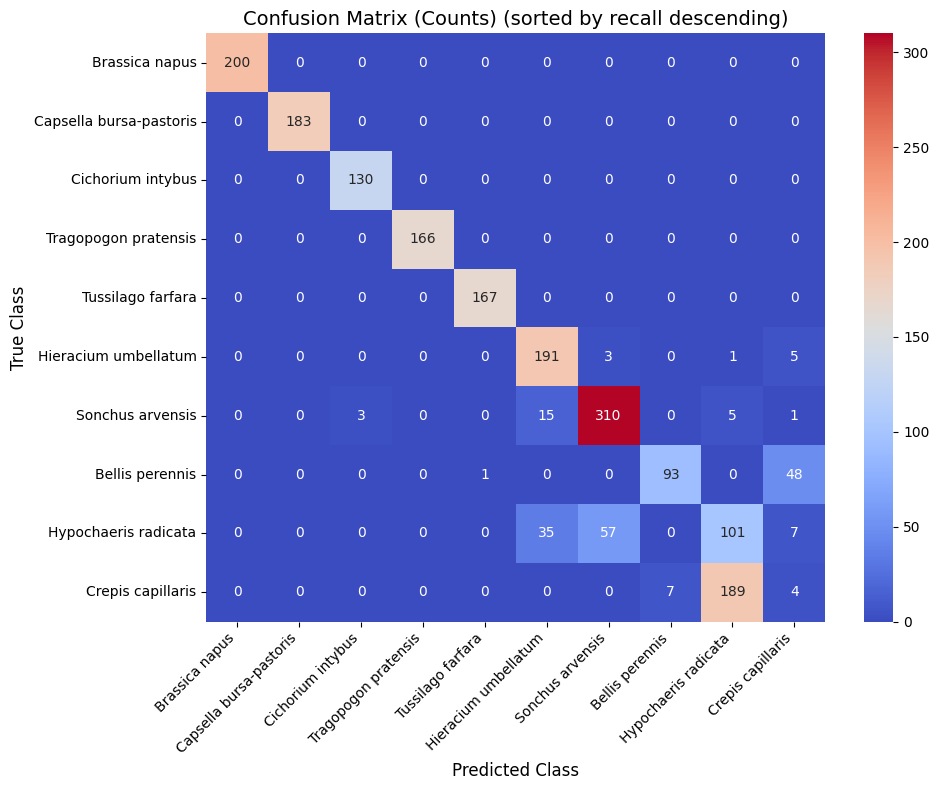

In [37]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val_boot.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# ConvNext + val + aug + quota + bootstrap

In [23]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=True
    ,bootstrap_impute_bool=True
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [24]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])

print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 701
1 Brassica napus 689
2 Capsella bursa-pastoris 685
3 Cichorium intybus 677
4 Crepis capillaris 704
5 Hieracium umbellatum 717
6 Hypochaeris radicata 704
7 Sonchus arvensis 681
8 Tragopogon pratensis 703
9 Tussilago farfara 699


In [25]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=3, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [26]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="convnext_fill_val_quota_boot.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [01:08<00:00,  3.18it/s]


Epoch 1/40 | Train Loss: 0.3345, Train Acc: 0.8875
| Val Loss: 0.0692, Val Acc: 0.9736
Val Recall per class: tensor([1.0000, 0.9890, 0.9784, 0.9016, 0.9940, 0.9150, 0.9759, 0.9947, 0.9880,
        1.0000])
Saved new best model (Val Acc = 0.9736)


100%|██████████| 218/218 [01:13<00:00,  2.95it/s]


Epoch 2/40 | Train Loss: 0.0864, Train Acc: 0.9724
| Val Loss: 0.1403, Val Acc: 0.9529


100%|██████████| 218/218 [01:15<00:00,  2.87it/s]


...

Epoch 21/40 | Train Loss: 0.0044, Train Acc: 0.9990
| Val Loss: 0.1609, Val Acc: 0.9655


100%|██████████| 218/218 [01:19<00:00,  2.73it/s]


Epoch 22/40 | Train Loss: 0.0197, Train Acc: 0.9947
| Val Loss: 0.0232, Val Acc: 0.9937


100%|██████████| 218/218 [01:16<00:00,  2.87it/s]


Epoch 23/40 | Train Loss: 0.0013, Train Acc: 0.9997
| Val Loss: 0.0453, Val Acc: 0.9879
Early stopping at epoch 23. Best Val Acc = 0.9983 at epoch 15.
Reloaded best model from epoch 15 (Val Acc=0.9983)



=== Backbone Feature Inspection ===
Min of mins: -9.8237886428833
Max of maxs: 13.038021087646484
Mean of batch means: 0.00573912952725058
Mean of batch stds: 1.0377784332291025

Test Accuracy: 0.7992
Test Recall per class:
Class 0 (Bellis perennis): 0.6056
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9891
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.2750
Class 5 (Hieracium umbellatum): 0.8300
Class 6 (Hypochaeris radicata): 0.3050
Class 7 (Sonchus arvensis): 0.9731
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


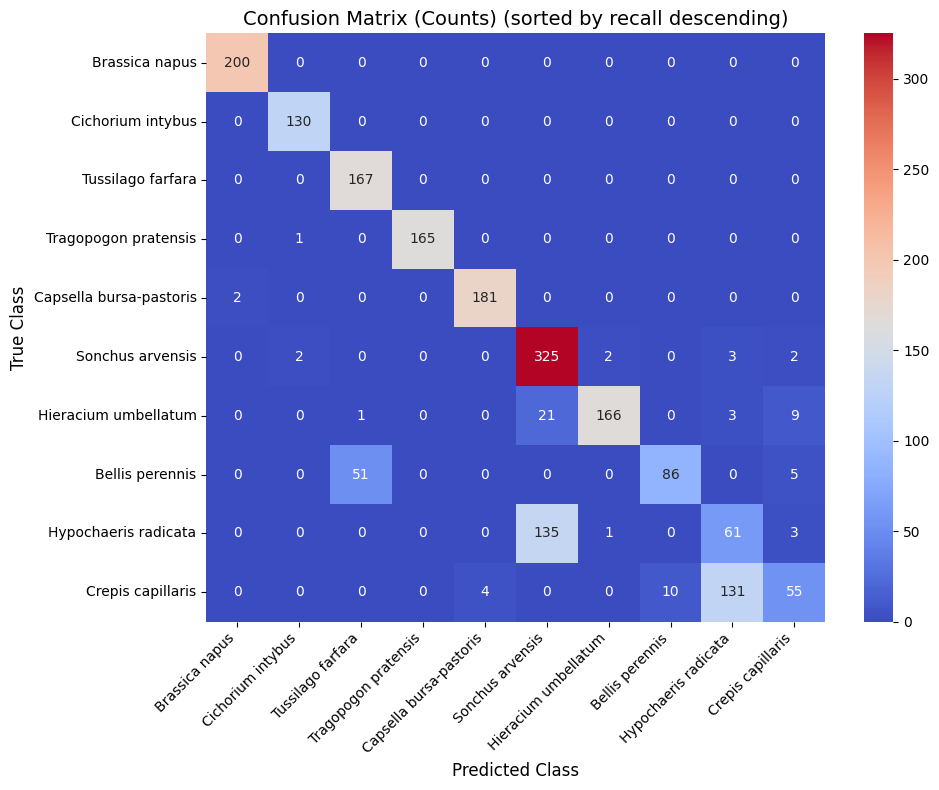

In [27]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnext_fill_val_quota_boot.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [3]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=True
    ,bootstrap_impute_bool=True
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [4]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])

print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])


Sampling from flower pool for species 'Hypochaeris radicata', flower_id '1001325'.
quota_bool=True | Sampled for species 'Hypochaeris radicata', flower_id '1001325': (32.1946, 28.4998, 0.8852354121498637)

Sampling from flower pool for species 'Brassica napus', flower_id '1000406'.
quota_bool=True | Sampled for species 'Brassica napus', flower_id '1000406': (30.3508, 26.1045, 0.8600926499466242)

Sampling from flower pool for species 'Hypochaeris radicata', flower_id '1001325'.
quota_bool=True | Sampled for species 'Hypochaeris radicata', flower_id '1001325': (30.7452, 28.3611, 0.9224561882830491)

Sampling from flower pool for species 'Hypochaeris radicata', flower_id '1001325'.
quota_bool=True | Sampled for species 'Hypochaeris radicata', flower_id '1001325': (32.164, 29.7593, 0.9252362890187787)

Sampling from flower pool for species 'Hypochaeris radicata', flower_id '1001325'.
quota_bool=True | Sampled for species 'Hypochaeris radicata', flower_id '1001325': (35.8385, 29.017, 0.80

# 384-dim ConvNeXt model

## Fill + Val

In [11]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Train subset size: 6462
Valida

In [12]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTiny384WithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [13]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="384convnext_fill_val.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 202/202 [00:52<00:00,  3.85it/s]


Epoch 1/40 | Train Loss: 0.4231, Train Acc: 0.8559
| Val Loss: 0.0721, Val Acc: 0.9808
Val Recall per class: tensor([1.0000, 0.9766, 0.9869, 0.9389, 0.9739, 0.9937, 0.9855, 0.9643, 0.9940,
        0.9942])
Saved new best model (Val Acc = 0.9808)


100%|██████████| 202/202 [00:53<00:00,  3.74it/s]


Epoch 2/40 | Train Loss: 0.0980, Train Acc: 0.9725
| Val Loss: 0.0375, Val Acc: 0.9913
Saved new best model (Val Acc = 0.9913)


100%|██████████| 202/202 [01:12<00:00,  2.80it/s]


...

Epoch 19/40 | Train Loss: 0.0076, Train Acc: 0.9985
| Val Loss: 0.0171, Val Acc: 0.9950


100%|██████████| 202/202 [01:10<00:00,  2.87it/s]


Epoch 20/40 | Train Loss: 0.0003, Train Acc: 1.0000
| Val Loss: 0.0195, Val Acc: 0.9957
Val Recall per class: tensor([1.0000, 0.9942, 0.9935, 1.0000, 1.0000, 0.9937, 0.9928, 0.9857, 0.9940,
        1.0000])


100%|██████████| 202/202 [01:15<00:00,  2.69it/s]


Epoch 21/40 | Train Loss: 0.0002, Train Acc: 1.0000
| Val Loss: 0.0201, Val Acc: 0.9957
Early stopping at epoch 21. Best Val Acc = 0.9975 at epoch 13.
Reloaded best model from epoch 13 (Val Acc=0.9975)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 22.072322845458984
Mean of batch means: 1.4880958228814798
Mean of batch stds: 2.5755742026157065

Test Accuracy: 0.7648
Test Recall per class:
Class 0 (Bellis perennis): 0.7254
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0400
Class 5 (Hieracium umbellatum): 0.8100
Class 6 (Hypochaeris radicata): 0.1050
Class 7 (Sonchus arvensis): 0.9880
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


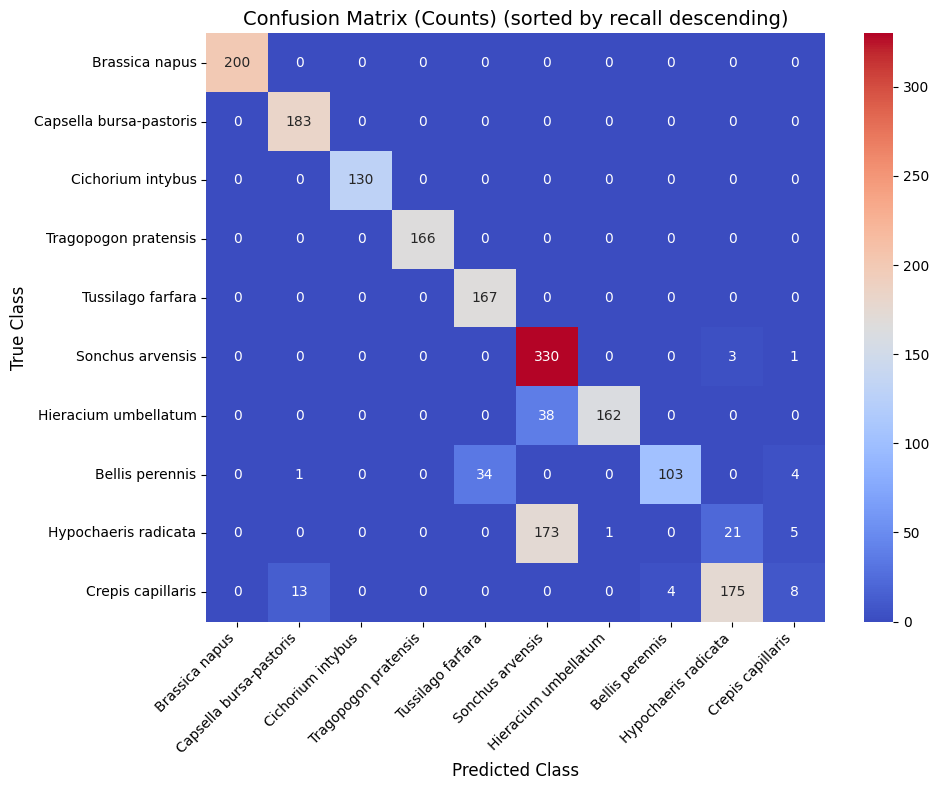

In [14]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/384convnext_fill_val.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Fill + Val + Aug

In [28]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=True
    ,val_bool=True
    ,aug_bool=True
    ,norm_bool=False
    ,sep_val_bool=False
    ,quota_bool=False
)
num_classes = len(classes)


Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
bootstrap_impute_bool: False
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  C

In [8]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTiny384WithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [9]:
BATCHSIZE = 32
EPOCHS = 20

history = train_model(
    model=model
    ,train_dataset=train_dataset
    ,val_dataset=val_dataset
    ,optimizer=optimizer
    ,loss_fn=loss_fn
    ,device=device
    ,model_name="384convnext_fill_val_aug.pth"
    ,num_classes=num_classes
    ,batch_size=32
    ,epochs=40
    ,early_stopping_patience=8
)

100%|██████████| 218/218 [01:06<00:00,  3.30it/s]


Epoch 1/40 | Train Loss: 0.4161, Train Acc: 0.8628
| Val Loss: 0.0731, Val Acc: 0.9839
Val Recall per class: tensor([1.0000, 0.9945, 0.9730, 0.9948, 0.9458, 0.9673, 0.9759, 0.9894, 0.9940,
        1.0000])
Saved new best model (Val Acc = 0.9839)


100%|██████████| 218/218 [01:18<00:00,  2.78it/s]


Epoch 2/40 | Train Loss: 0.0958, Train Acc: 0.9721
| Val Loss: 0.0787, Val Acc: 0.9747


100%|██████████| 218/218 [01:18<00:00,  2.76it/s]


...

Epoch 19/40 | Train Loss: 0.0186, Train Acc: 0.9961
| Val Loss: 0.0276, Val Acc: 0.9925


100%|██████████| 218/218 [01:18<00:00,  2.78it/s]


Epoch 20/40 | Train Loss: 0.0377, Train Acc: 0.9904
| Val Loss: 0.0250, Val Acc: 0.9948
Val Recall per class: tensor([1.0000, 1.0000, 0.9838, 0.9948, 1.0000, 1.0000, 0.9880, 0.9894, 0.9940,
        1.0000])


100%|██████████| 218/218 [01:17<00:00,  2.83it/s]


Epoch 21/40 | Train Loss: 0.0174, Train Acc: 0.9951
| Val Loss: 0.0714, Val Acc: 0.9805
Early stopping at epoch 21. Best Val Acc = 0.9960 at epoch 13.
Reloaded best model from epoch 13 (Val Acc=0.9960)



=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 18.257173538208008
Mean of batch means: 1.107156600131363
Mean of batch stds: 1.9840630117009899

Test Accuracy: 0.7716
Test Recall per class:
Class 0 (Bellis perennis): 0.6972
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.3100
Class 5 (Hieracium umbellatum): 0.6950
Class 6 (Hypochaeris radicata): 0.0750
Class 7 (Sonchus arvensis): 0.9701
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


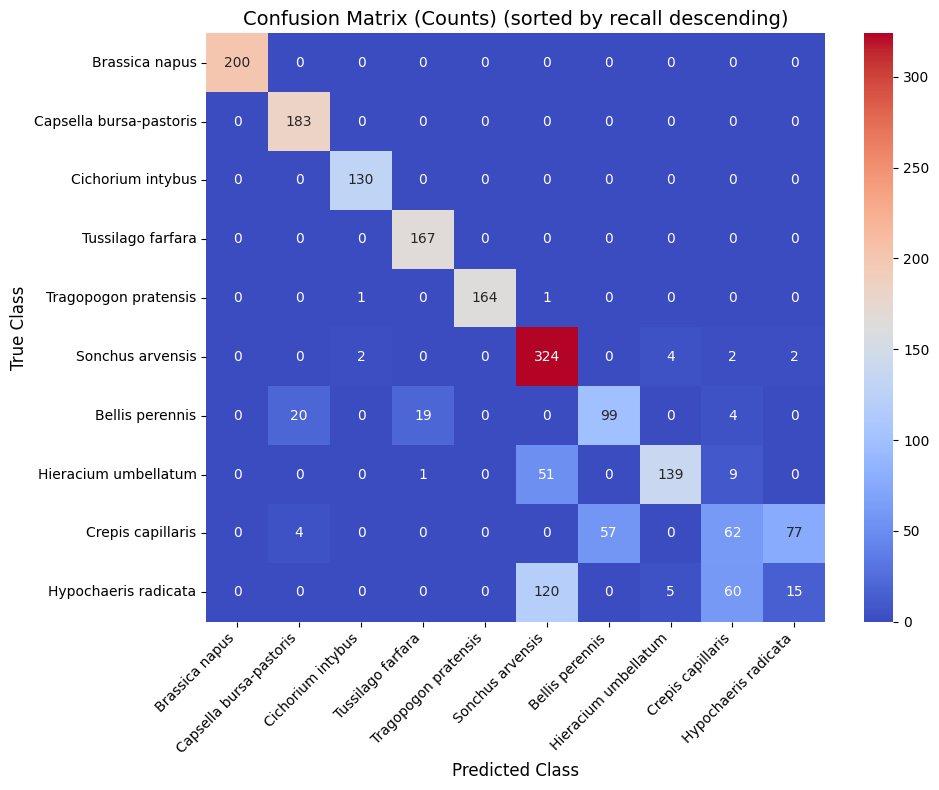

In [10]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/384convnext_fill_val_aug.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

# Linear ConvNext

In [15]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyLinearWithSize(num_classes=10, size_dim=3, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)


=== Backbone Feature Inspection ===
Min of mins: -9.39969539642334
Max of maxs: 10.604273796081543
Mean of batch means: 0.023414184832678285
Mean of batch stds: 1.0920299018015627

Test Accuracy: 0.7586
Test Recall per class:
Class 0 (Bellis perennis): 0.1197
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1150
Class 5 (Hieracium umbellatum): 0.8150
Class 6 (Hypochaeris radicata): 0.4300
Class 7 (Sonchus arvensis): 0.9701
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


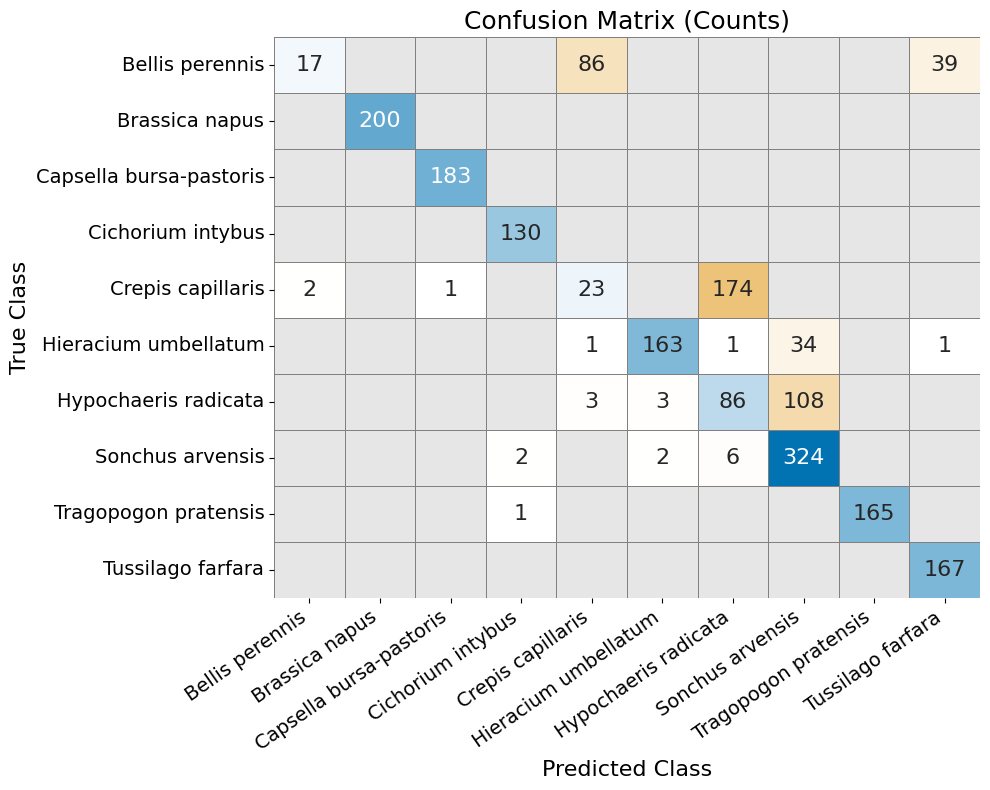

In [10]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnextlinear_fill_val_aug.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [16]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/convnextlinear_fill_val_aug_quota.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x770 and 771x10)

# Best ConvNext from old Notebook

In [75]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)


=== Backbone Feature Inspection ===
Min of mins: -12.666570663452148
Max of maxs: 14.322230339050293
Mean of batch means: 0.018298786706777793
Mean of batch stds: 1.0869133560383906

Test Accuracy: 0.8517
Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.3850
Class 5 (Hieracium umbellatum): 0.8500
Class 6 (Hypochaeris radicata): 0.6550
Class 7 (Sonchus arvensis): 0.9371
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


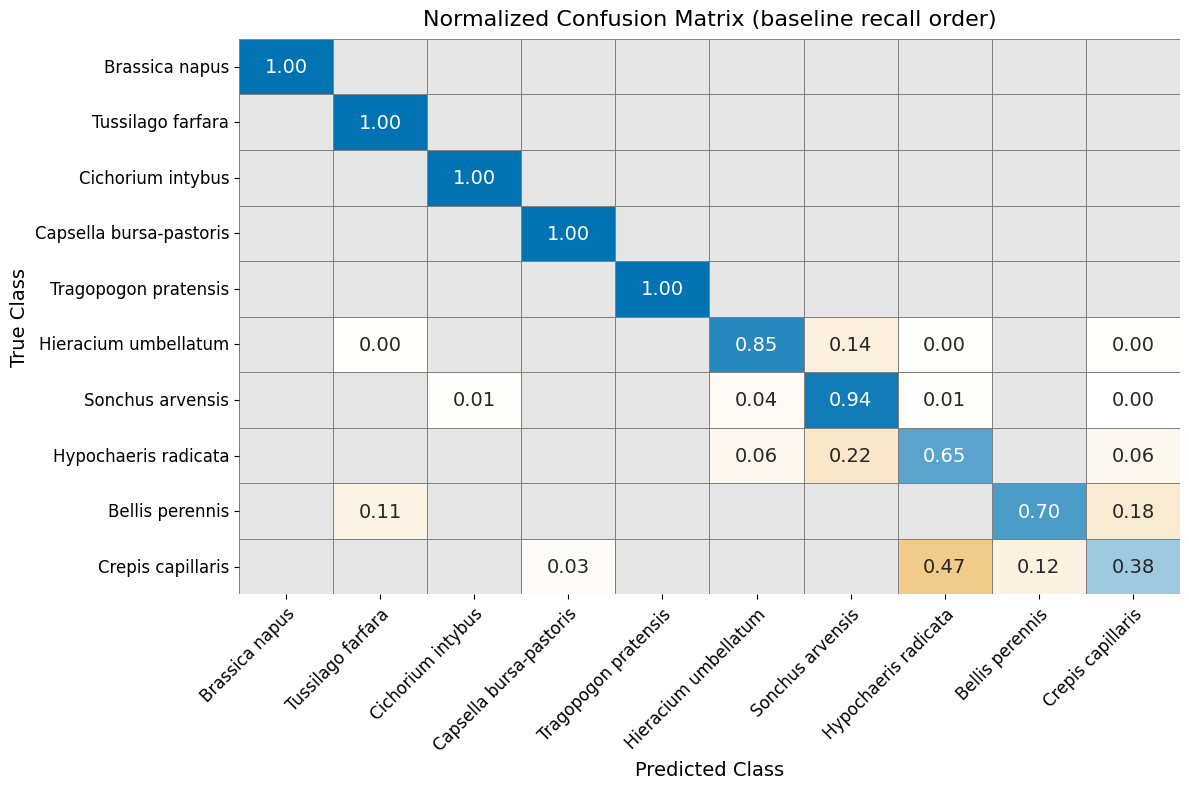

In [76]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_models/convnext_tiny_size_aug.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class, accuracy, probs_np, y_np, conf = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

#plot_confusion_matrix(conf, idx_to_class, normalize=False, sort_by_recall_desc=True, figsize=(14,10), annot_size=18, tick_size=16,label_size=18, title_size=20)
plot_confusion_matrix(conf=conf, idx_to_class=idx_to_class,)

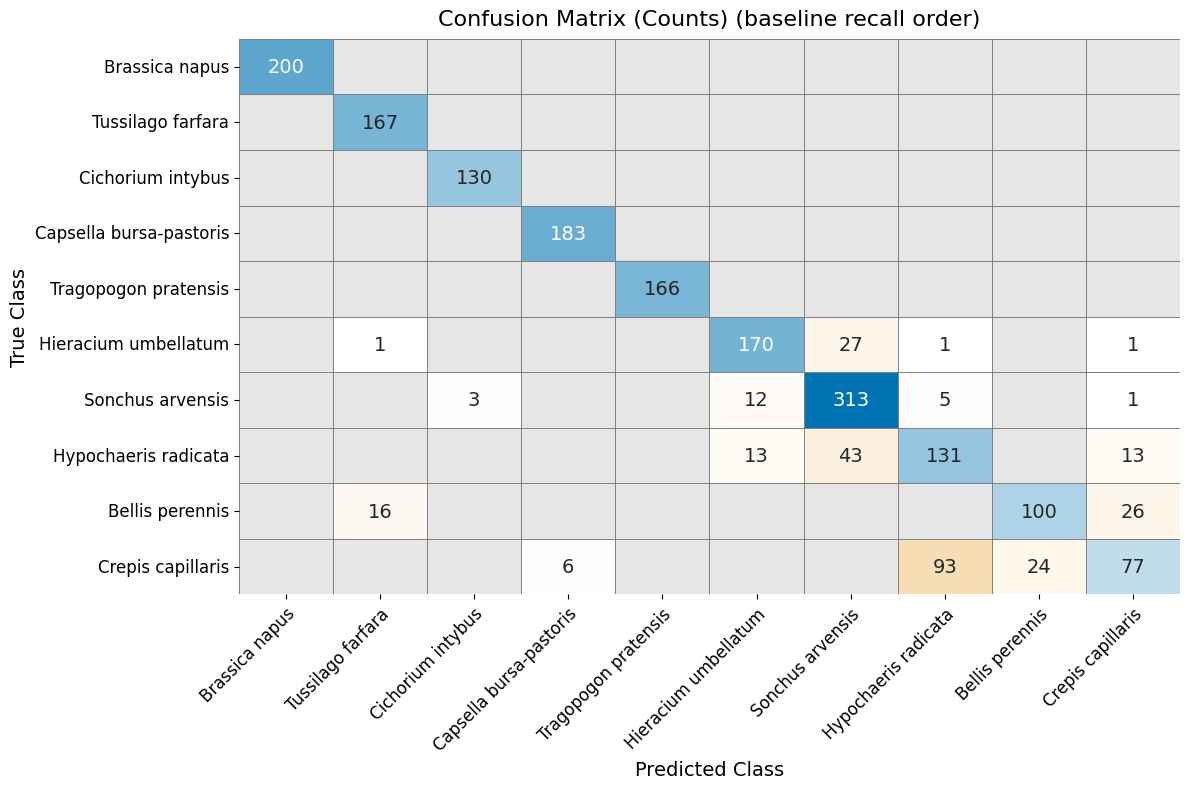

In [6]:
plot_confusion_matrix(conf, idx_to_class, normalize=False,sort_by_recall_desc=True)

In [31]:
def count_classes_above_threshold_for_true_class(probs, y_true, class_names, true_class_name, threshold=0.01):
    true_idx = class_names.index(true_class_name)
    subset = probs[y_true == true_idx]

    if subset.shape[0] == 0:
        return {}

    counts = (subset > threshold).sum(axis=0)

    return {class_names[i]: int(counts[i]) for i in range(len(class_names))}

In [34]:
print(classes)

['Bellis perennis', 'Brassica napus', 'Capsella bursa-pastoris', 'Cichorium intybus', 'Crepis capillaris', 'Hieracium umbellatum', 'Hypochaeris radicata', 'Sonchus arvensis', 'Tragopogon pratensis', 'Tussilago farfara']


In [35]:
counts = count_classes_above_threshold_for_true_class(
    probs_np, y_np, classes, "Crepis capillaris", threshold=0.05
)

for cls, count in counts.items():
    print(f"{cls}: {count}")

Bellis perennis: 66
Brassica napus: 0
Capsella bursa-pastoris: 20
Cichorium intybus: 0
Crepis capillaris: 130
Hieracium umbellatum: 0
Hypochaeris radicata: 152
Sonchus arvensis: 0
Tragopogon pratensis: 0
Tussilago farfara: 0


In [36]:
def mean_softmax_for_true_class(probs, y_true, class_names, true_class_name):
    true_idx = class_names.index(true_class_name)
    subset = probs[y_true == true_idx]

    if subset.shape[0] == 0:
        return {}

    mean_vec = subset.mean(axis=0)
    return {class_names[i]: float(mean_vec[i]) for i in range(len(class_names))}

In [37]:
mean_probs = mean_softmax_for_true_class(probs_np, y_np, classes, "Crepis capillaris")

for cls, val in mean_probs.items():
    print(f"{cls}: {val:.4f}")

Bellis perennis: 0.1346
Brassica napus: 0.0000
Capsella bursa-pastoris: 0.0358
Cichorium intybus: 0.0000
Crepis capillaris: 0.3682
Hieracium umbellatum: 0.0001
Hypochaeris radicata: 0.4611
Sonchus arvensis: 0.0000
Tragopogon pratensis: 0.0001
Tussilago farfara: 0.0000


In [38]:
def summarize_probabilities_for_true_class(probs, y_true, class_names, true_class_name, threshold=0.05):
    true_idx = class_names.index(true_class_name)
    subset = probs[y_true == true_idx]

    if subset.shape[0] == 0:
        return None

    mean_probs = subset.mean(axis=0)
    counts_above = (subset > threshold).sum(axis=0)

    summary = []
    for i, cls in enumerate(class_names):
        summary.append({
            "class": cls,
            "mean_probability": float(mean_probs[i]),
            "count_above_threshold": int(counts_above[i])
        })

    return summary

In [39]:
summary = summarize_probabilities_for_true_class(
    probs_np, y_np, classes, "Crepis capillaris", threshold=0.05
)

for row in summary:
    print(row)

{'class': 'Bellis perennis', 'mean_probability': 0.13462017476558685, 'count_above_threshold': 66}
{'class': 'Brassica napus', 'mean_probability': 1.5336749129346572e-05, 'count_above_threshold': 0}
{'class': 'Capsella bursa-pastoris', 'mean_probability': 0.035764746367931366, 'count_above_threshold': 20}
{'class': 'Cichorium intybus', 'mean_probability': 3.474090772215277e-05, 'count_above_threshold': 0}
{'class': 'Crepis capillaris', 'mean_probability': 0.36824455857276917, 'count_above_threshold': 130}
{'class': 'Hieracium umbellatum', 'mean_probability': 5.4027765145292506e-05, 'count_above_threshold': 0}
{'class': 'Hypochaeris radicata', 'mean_probability': 0.46114078164100647, 'count_above_threshold': 152}
{'class': 'Sonchus arvensis', 'mean_probability': 1.3227108865976334e-06, 'count_above_threshold': 0}
{'class': 'Tragopogon pratensis', 'mean_probability': 9.355199290439487e-05, 'count_above_threshold': 0}
{'class': 'Tussilago farfara', 'mean_probability': 3.059829032281414e-0

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def get_active_classes_for_true_class(probs, y_true, class_names, true_class_name, threshold=0.05):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    true_idx = class_names.index(true_class_name)
    subset = probs[y_true == true_idx]

    if subset.shape[0] == 0:
        raise ValueError(f"No samples found with true class = {true_class_name}")

    active_mask = (subset > threshold).any(axis=0)
    active_indices = np.where(active_mask)[0]
    active_class_names = [class_names[i] for i in active_indices]

    return active_indices, active_class_names


def plot_true_class_heatmap_and_boxplot_threshold(
    probs,
    y_true,
    class_names,
    true_class_name="Crepis",
    threshold=0.05,
    sort_by="true_class_prob",
    figsize_heatmap=(10, 8),
    figsize_boxplot=(10, 6),
    title_fontsize=18,
    label_fontsize=15,
    tick_fontsize=13,
    colorbar_fontsize=14
):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    if probs.ndim != 2:
        raise ValueError("probs must have shape (n_samples, n_classes)")
    if y_true.ndim != 1:
        raise ValueError("y_true must have shape (n_samples,)")
    if probs.shape[0] != y_true.shape[0]:
        raise ValueError("probs and y_true must have the same number of samples")
    if probs.shape[1] != len(class_names):
        raise ValueError("Number of columns in probs must match len(class_names)")
    if true_class_name not in class_names:
        raise ValueError(f"{true_class_name!r} not found in class_names")

    true_idx = class_names.index(true_class_name)
    subset = probs[y_true == true_idx]

    if subset.shape[0] == 0:
        raise ValueError(f"No samples found with true class = {true_class_name}")

    active_indices, active_class_names = get_active_classes_for_true_class(
        probs, y_true, class_names, true_class_name, threshold=threshold
    )

    if len(active_indices) == 0:
        raise ValueError(f"No class probabilities exceeded threshold={threshold}")

    subset_reduced = subset[:, active_indices]
    reduced_true_idx = active_class_names.index(true_class_name)

    if sort_by == "true_class_prob":
        order = np.argsort(subset_reduced[:, reduced_true_idx])
        subset_sorted = subset_reduced[order]
    elif sort_by == "predicted_class":
        pred_class = np.argmax(subset_reduced, axis=1)
        order = np.lexsort((subset_reduced[:, reduced_true_idx], pred_class))
        subset_sorted = subset_reduced[order]
    elif sort_by is None:
        subset_sorted = subset_reduced
    else:
        raise ValueError("sort_by must be 'true_class_prob', 'predicted_class', or None")

    # Heatmap
    plt.figure(figsize=figsize_heatmap)
    im = plt.imshow(subset_sorted, aspect="auto")
    cbar = plt.colorbar(im)
    cbar.set_label("Softmax probability", fontsize=colorbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    plt.xticks(range(len(active_class_names)), active_class_names, rotation=45, ha="right", fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.xlabel("Class / softmax coordinate", fontsize=label_fontsize)
    plt.ylabel(f"Samples with true class = {true_class_name}", fontsize=label_fontsize)
    plt.title(
        f"Heatmap of softmax vectors for true class = {true_class_name}\n"
        f"(only classes with prob > {threshold})",
        fontsize=title_fontsize
    )
    plt.tight_layout()
    plt.show()

    # Boxplot
    data = [subset_reduced[:, j] for j in range(len(active_class_names))]

    plt.figure(figsize=figsize_boxplot)
    plt.boxplot(data, tick_labels=active_class_names)
    plt.xticks(rotation=45, ha="right", fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.xlabel("Class / softmax coordinate", fontsize=label_fontsize)
    plt.ylabel("Softmax probability", fontsize=label_fontsize)
    plt.title(
        f"Boxplot of softmax coordinates for true class = {true_class_name}\n"
        f"(only classes with prob > {threshold})",
        fontsize=title_fontsize
    )
    plt.tight_layout()
    plt.show()

    return active_indices, active_class_names

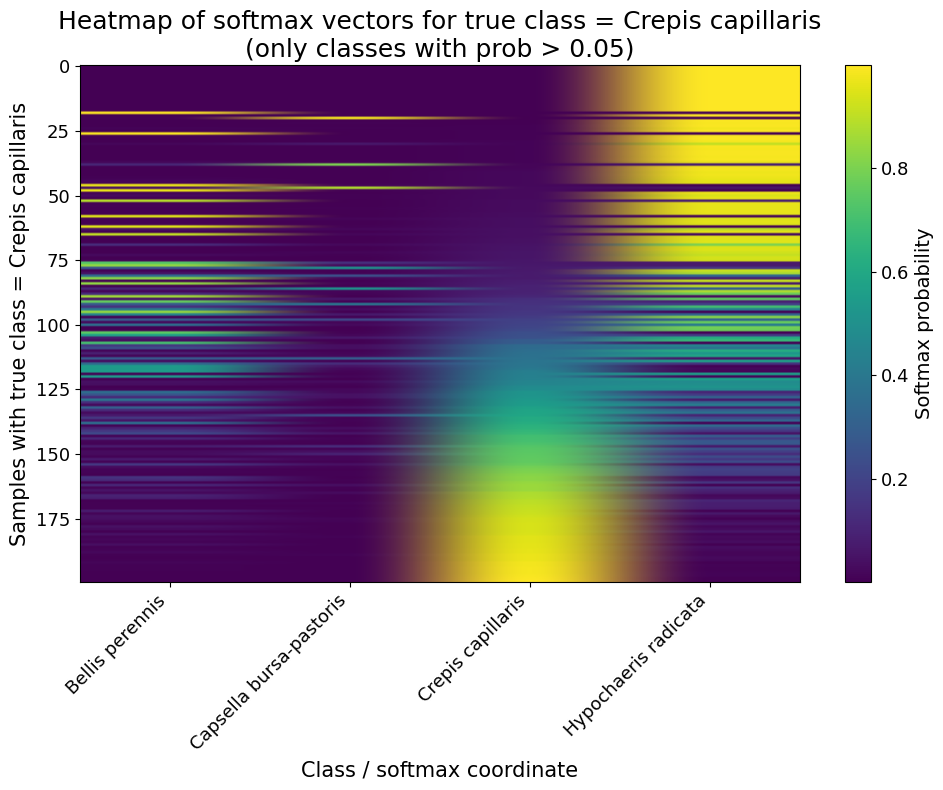

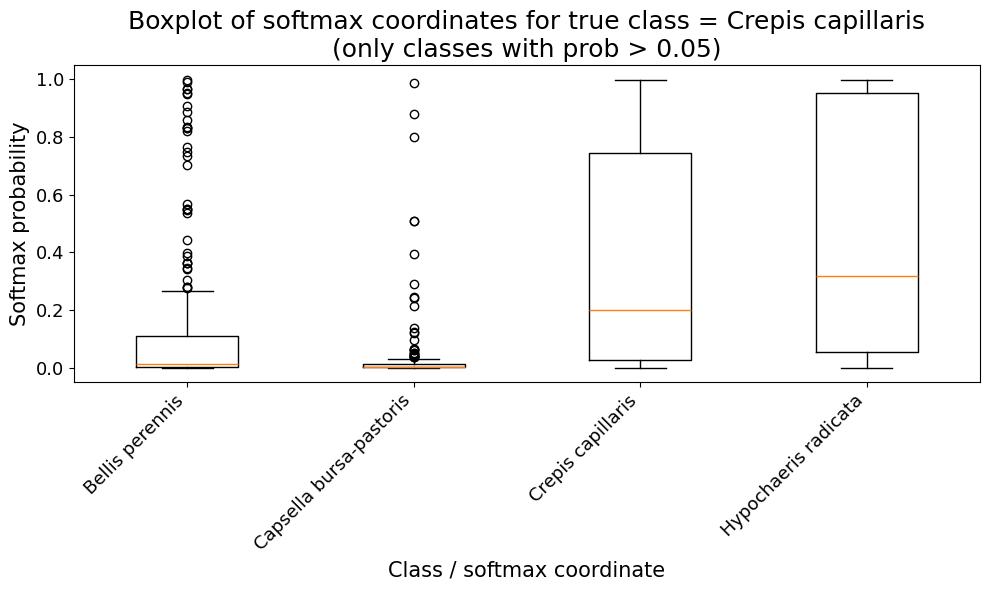

In [41]:
active_indices, active_class_names = plot_true_class_heatmap_and_boxplot_threshold(
    probs=probs_np,
    y_true=y_np,
    class_names=classes,
    true_class_name="Crepis capillaris",
    threshold=0.05,
    sort_by="true_class_prob"
)

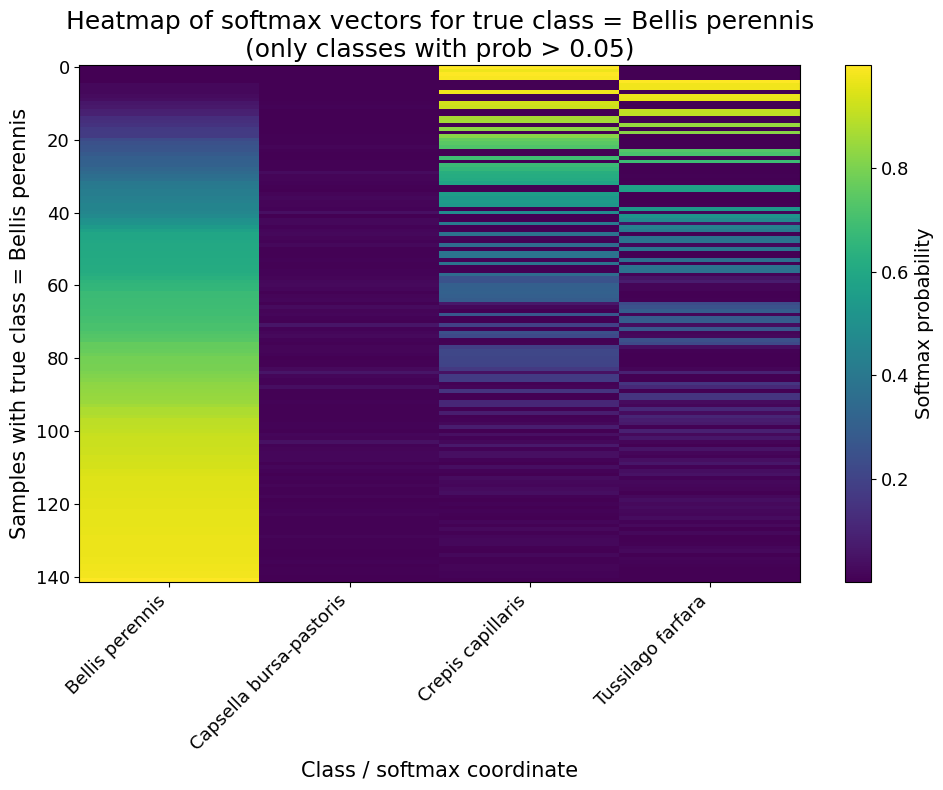

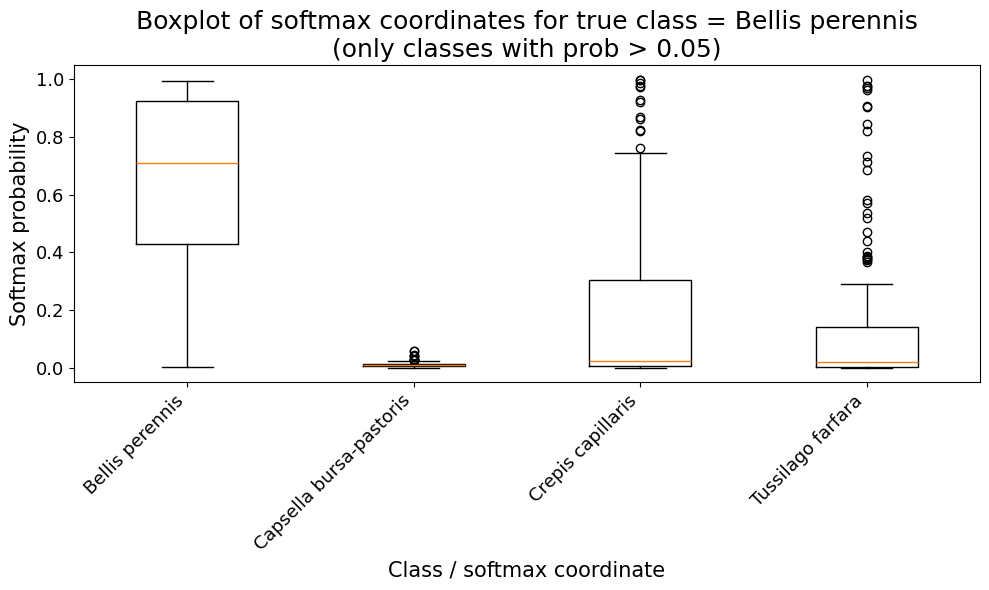

In [42]:
active_indices, active_class_names = plot_true_class_heatmap_and_boxplot_threshold(
    probs=probs_np,
    y_true=y_np,
    class_names=classes,
    true_class_name="Bellis perennis",
    threshold=0.05,
    sort_by="true_class_prob"
)

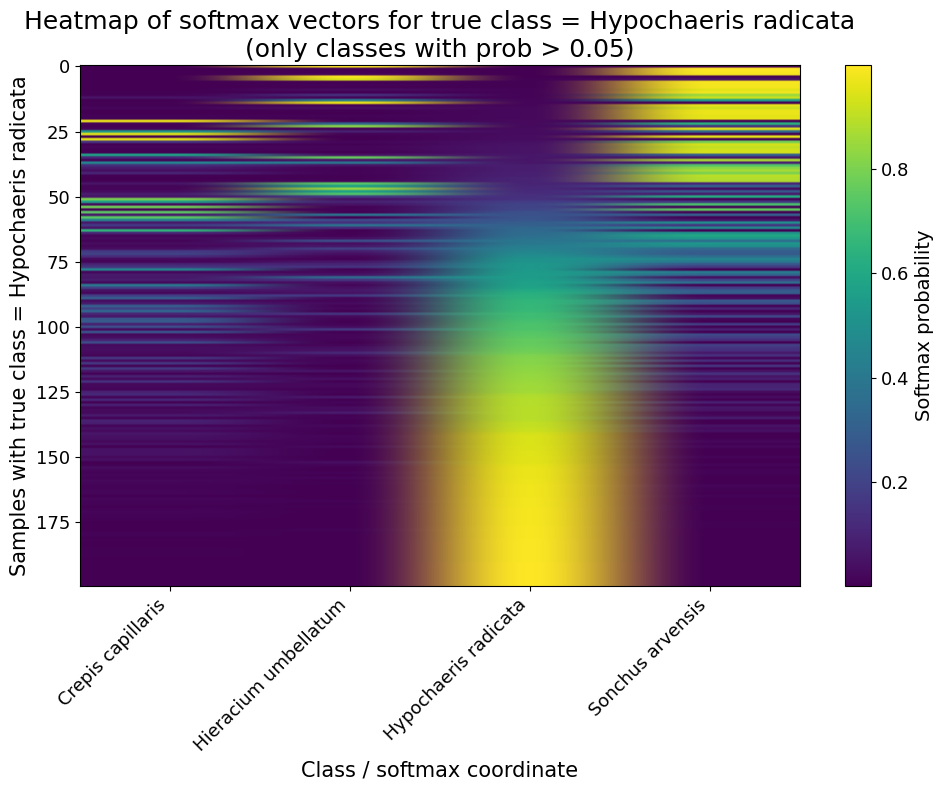

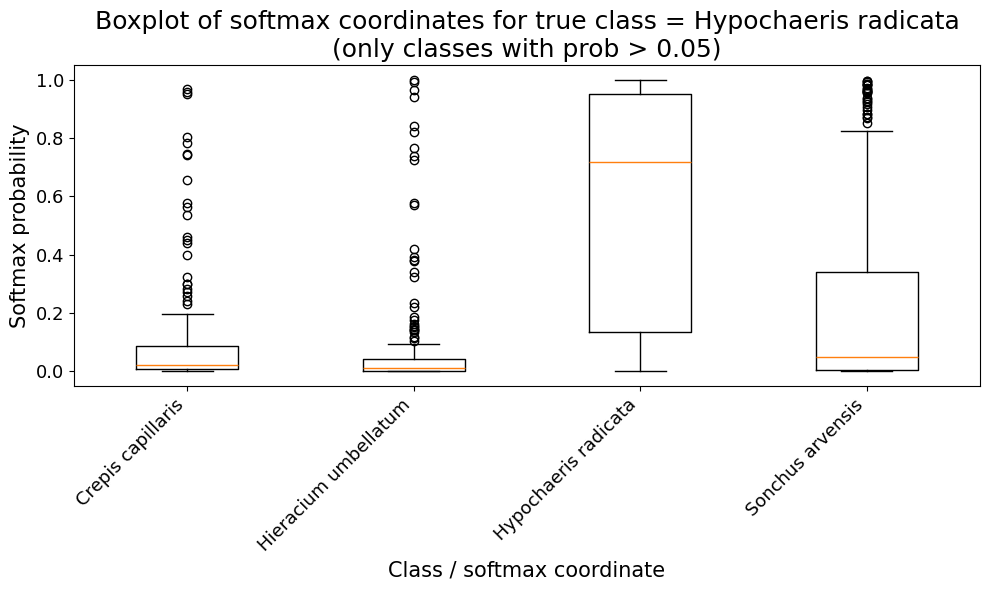

In [43]:
active_indices, active_class_names = plot_true_class_heatmap_and_boxplot_threshold(
    probs=probs_np,
    y_true=y_np,
    class_names=classes,
    true_class_name="Hypochaeris radicata",
    threshold=0.05,
    sort_by="true_class_prob"
)

In [77]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
    ,return_flowerid=True
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [45]:
train_dataset[0]

(tensor([[[1.3584, 1.5297, 1.9064,  ..., 1.8208, 1.8722, 1.9064],
          [1.5125, 1.6153, 1.8722,  ..., 1.8037, 1.8722, 1.9064],
          [1.8379, 1.8379, 1.8208,  ..., 1.7694, 1.8893, 1.9407],
          ...,
          [1.6667, 1.5297, 1.2385,  ..., 1.7009, 1.7865, 1.8208],
          [1.6153, 1.5297, 1.3584,  ..., 1.4783, 2.0092, 2.2318],
          [1.5810, 1.5297, 1.4098,  ..., 1.3755, 2.0605, 2.2489]],
 
         [[1.2556, 1.4307, 1.8158,  ..., 1.6408, 1.6933, 1.7283],
          [1.4132, 1.5182, 1.7808,  ..., 1.6232, 1.7108, 1.7458],
          [1.7458, 1.7458, 1.7283,  ..., 1.6232, 1.7458, 1.7983],
          ...,
          [1.5357, 1.4132, 1.1155,  ..., 1.6057, 1.6933, 1.7283],
          [1.5007, 1.4132, 1.2381,  ..., 1.3957, 1.9734, 2.2185],
          [1.4657, 1.4132, 1.2906,  ..., 1.3081, 2.0959, 2.4286]],
 
         [[1.5942, 1.7685, 2.1520,  ..., 2.0125, 2.0648, 2.0997],
          [1.7511, 1.8557, 2.1171,  ..., 1.9951, 2.0648, 2.0997],
          [2.0823, 2.0823, 2.0648,  ...,

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_pca_tsne_two_panels(
    X_train,
    y_train,
    X_test,
    y_test,
    class_names,
    confusing_classes,
    method="pca",
    figsize=(14, 6),
    point_size=45,
    alpha=0.75,
    title_fontsize=18,
    label_fontsize=14,
    tick_fontsize=12,
    legend_fontsize=11,
    random_state=42
):
    confusing_idx = [class_names.index(c) for c in confusing_classes]

    train_mask = np.isin(y_train, confusing_idx)
    test_mask = np.isin(y_test, confusing_idx)

    X_train_sub = X_train[train_mask]
    y_train_sub = y_train[train_mask]

    X_test_sub = X_test[test_mask]
    y_test_sub = y_test[test_mask]

    if len(X_train_sub) == 0 or len(X_test_sub) == 0:
        raise ValueError("Filtered train or test set is empty.")

    if method.lower() == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        X_train_2d = reducer.fit_transform(X_train_sub)
        X_test_2d = reducer.transform(X_test_sub)
        xlabel, ylabel = "PC1", "PC2"

    elif method.lower() == "tsne":
        X_all = np.vstack([X_train_sub, X_test_sub])
        reducer = TSNE(
            n_components=2,
            perplexity=30,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )
        X_all_2d = reducer.fit_transform(X_all)
        X_train_2d = X_all_2d[:len(X_train_sub)]
        X_test_2d = X_all_2d[len(X_train_sub):]
        xlabel, ylabel = "t-SNE 1", "t-SNE 2"

    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False, sharey=False)

    for cls_idx in confusing_idx:
        mask_train = y_train_sub == cls_idx
        mask_test = y_test_sub == cls_idx

        axes[0].scatter(
            X_train_2d[mask_train, 0],
            X_train_2d[mask_train, 1],
            s=point_size,
            alpha=alpha,
            label=class_names[cls_idx]
        )

        axes[1].scatter(
            X_test_2d[mask_test, 0],
            X_test_2d[mask_test, 1],
            s=point_size,
            alpha=alpha,
            label=class_names[cls_idx]
        )

    x_min = min(X_train_2d[:, 0].min(), X_test_2d[:, 0].min())
    x_max = max(X_train_2d[:, 0].max(), X_test_2d[:, 0].max())
    y_min = min(X_train_2d[:, 1].min(), X_test_2d[:, 1].min())
    y_max = max(X_train_2d[:, 1].max(), X_test_2d[:, 1].max())

    axes[0].set_xlim(x_min, x_max)
    axes[1].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[1].set_ylim(y_min, y_max)
    
    axes[0].set_title("Train", fontsize=title_fontsize - 2)
    axes[1].set_title("Test", fontsize=title_fontsize - 2)

    for ax in axes:
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
        ax.tick_params(labelsize=tick_fontsize)

    handles, labels = axes[1].get_legend_handles_labels()
    
    fig.legend(handles, labels, fontsize=legend_fontsize, loc="upper left")
    fig.suptitle(f"{method.upper()} of confusing classes", fontsize=title_fontsize)
    plt.tight_layout(rect=[0, 0, 0.88, 0.95])
    plt.show()

In [62]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_pca_tsne_flowerid_two_panels(
    X_train,
    y_train,
    flower_id_train,
    X_test,
    y_test,
    flower_id_test,
    class_names,
    confusing_classes,
    method="pca",
    figsize=(6.8, 3.4),   # LaTeX-friendly full-width figure
    point_size=14,
    alpha=0.80,
    title_fontsize=11,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=8,
    random_state=42,
    show_flower_legend=False,
    max_flower_ids_in_legend=12,
    same_axes=True,
    save_path=None,
    dpi=300
):
    """
    Two-panel PCA/t-SNE plot:
      - left panel: Train
      - right panel: Test
      - species encoded by marker shape
      - flower_id encoded by color

    Parameters
    ----------
    flower_id_train, flower_id_test : array-like of shape (n_samples,)
        Flower IDs aligned with X_train/y_train and X_test/y_test.
    show_flower_legend : bool
        Whether to show a flower-ID legend.
    max_flower_ids_in_legend : int
        Only show flower legend if number of unique flower IDs is small enough.
    """

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)
    flower_id_train = np.asarray(flower_id_train)

    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test)
    flower_id_test = np.asarray(flower_id_test)

    confusing_idx = [class_names.index(c) for c in confusing_classes]

    train_mask = np.isin(y_train, confusing_idx)
    test_mask = np.isin(y_test, confusing_idx)

    X_train_sub = X_train[train_mask]
    y_train_sub = y_train[train_mask]
    flower_train_sub = flower_id_train[train_mask]

    X_test_sub = X_test[test_mask]
    y_test_sub = y_test[test_mask]
    flower_test_sub = flower_id_test[test_mask]

    if len(X_train_sub) == 0 or len(X_test_sub) == 0:
        raise ValueError("Filtered train or test set is empty.")

    # Same embedding space
    if method.lower() == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        X_train_2d = reducer.fit_transform(X_train_sub)
        X_test_2d = reducer.transform(X_test_sub)
        xlabel, ylabel = "PC1", "PC2"

    elif method.lower() == "tsne":
        X_all = np.vstack([X_train_sub, X_test_sub])
        reducer = TSNE(
            n_components=2,
            perplexity=30,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )
        X_all_2d = reducer.fit_transform(X_all)
        X_train_2d = X_all_2d[:len(X_train_sub)]
        X_test_2d = X_all_2d[len(X_train_sub):]
        xlabel, ylabel = "t-SNE 1", "t-SNE 2"

    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=False, sharey=False)

    # Same species = same marker shape
    available_markers = ["o", "^", "s", "D", "P", "X", "v", "<", ">", "*"]
    if len(confusing_idx) > len(available_markers):
        raise ValueError("Too many confusing classes for available marker styles.")

    marker_map = {
        cls_idx: available_markers[i]
        for i, cls_idx in enumerate(confusing_idx)
    }

    # Same flower_id = same color across train and test
    all_flower_ids = np.unique(np.concatenate([flower_train_sub, flower_test_sub]))
    cmap = plt.get_cmap("tab20", len(all_flower_ids))
    flower_color_map = {fid: cmap(i) for i, fid in enumerate(all_flower_ids)}

    # --- Train panel ---
    for cls_idx in confusing_idx:
        cls_mask = (y_train_sub == cls_idx)
        for fid in np.unique(flower_train_sub[cls_mask]):
            mask = cls_mask & (flower_train_sub == fid)
            axes[0].scatter(
                X_train_2d[mask, 0],
                X_train_2d[mask, 1],
                s=point_size,
                alpha=alpha,
                marker=marker_map[cls_idx],
                color=flower_color_map[fid],
                edgecolors="black",
                linewidths=0.35
            )

    # --- Test panel ---
    for cls_idx in confusing_idx:
        cls_mask = (y_test_sub == cls_idx)
        for fid in np.unique(flower_test_sub[cls_mask]):
            mask = cls_mask & (flower_test_sub == fid)
            axes[1].scatter(
                X_test_2d[mask, 0],
                X_test_2d[mask, 1],
                s=point_size,
                alpha=alpha,
                marker=marker_map[cls_idx],
                color=flower_color_map[fid],
                edgecolors="black",
                linewidths=0.35
            )

    # Same scale across panels
    if same_axes:
        x_min = min(X_train_2d[:, 0].min(), X_test_2d[:, 0].min())
        x_max = max(X_train_2d[:, 0].max(), X_test_2d[:, 0].max())
        y_min = min(X_train_2d[:, 1].min(), X_test_2d[:, 1].min())
        y_max = max(X_train_2d[:, 1].max(), X_test_2d[:, 1].max())

        axes[0].set_xlim(x_min, x_max)
        axes[1].set_xlim(x_min, x_max)
        axes[0].set_ylim(y_min, y_max)
        axes[1].set_ylim(y_min, y_max)

    axes[0].set_title("Train", fontsize=title_fontsize - 2)
    axes[1].set_title("Test", fontsize=title_fontsize - 2)

    for ax in axes:
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
        ax.tick_params(labelsize=tick_fontsize)
    # Species legend: shape only, shown inside left panel at upper-left corner
    # Species legend: shape only
    species_handles = [
        Line2D(
            [0], [0],
            marker=marker_map[cls_idx],
            linestyle="None",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=8,
            label=class_names[cls_idx]
        )
        for cls_idx in confusing_idx
    ]

    fig.legend(
        handles=species_handles,
        #title="Species",
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
        loc="upper left",
        #bbox_to_anchor=(0.86, 0.98)
    )

    # Optional flower legend
    if show_flower_legend and len(all_flower_ids) <= max_flower_ids_in_legend:
        flower_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markerfacecolor=flower_color_map[fid],
                markeredgecolor="black",
                markersize=7,
                label=str(fid)
            )
            for fid in all_flower_ids
        ]

        fig.legend(
            handles=flower_handles,
            title="Flower ID",
            fontsize=max(8, legend_fontsize - 1),
            title_fontsize=max(8, legend_fontsize - 1),
            loc="upper right",
            #bbox_to_anchor=(0.86, 0.10)
            #frameon=True
        )

    fig.suptitle(f"{method.upper()}", fontsize=title_fontsize)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    return {
        "flower_color_map": flower_color_map,
        "marker_map": marker_map
    }

In [48]:
train_dataset[0]

(tensor([[[1.3584, 1.5297, 1.9064,  ..., 1.8208, 1.8722, 1.9064],
          [1.5125, 1.6153, 1.8722,  ..., 1.8037, 1.8722, 1.9064],
          [1.8379, 1.8379, 1.8208,  ..., 1.7694, 1.8893, 1.9407],
          ...,
          [1.6667, 1.5297, 1.2385,  ..., 1.7009, 1.7865, 1.8208],
          [1.6153, 1.5297, 1.3584,  ..., 1.4783, 2.0092, 2.2318],
          [1.5810, 1.5297, 1.4098,  ..., 1.3755, 2.0605, 2.2489]],
 
         [[1.2556, 1.4307, 1.8158,  ..., 1.6408, 1.6933, 1.7283],
          [1.4132, 1.5182, 1.7808,  ..., 1.6232, 1.7108, 1.7458],
          [1.7458, 1.7458, 1.7283,  ..., 1.6232, 1.7458, 1.7983],
          ...,
          [1.5357, 1.4132, 1.1155,  ..., 1.6057, 1.6933, 1.7283],
          [1.5007, 1.4132, 1.2381,  ..., 1.3957, 1.9734, 2.2185],
          [1.4657, 1.4132, 1.2906,  ..., 1.3081, 2.0959, 2.4286]],
 
         [[1.5942, 1.7685, 2.1520,  ..., 2.0125, 2.0648, 2.0997],
          [1.7511, 1.8557, 2.1171,  ..., 1.9951, 2.0648, 2.0997],
          [2.0823, 2.0823, 2.0648,  ...,

In [49]:
import numpy as np
import torch

def extract_fused_features(model, loader, device):
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for x_img, x_size, y in loader:
            x_img = x_img.to(device)
            x_size = x_size.to(device).float()
            y = y.to(device)

            features = model.forward_features(x_img, x_size)

            all_features.append(features.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y

In [50]:
import numpy as np
import torch

def extract_features_labels_flowerids(model, loader, device):
    model.eval()

    all_features = []
    all_labels = []
    all_filenames = []
    all_flower_ids = []

    with torch.no_grad():
        for x_img, x_size, y, filenames, flower_ids in loader:
            x_img = x_img.to(device)
            x_size = x_size.to(device).float()
            y = y.to(device)

            feats = model.forward_features(x_img, x_size)

            all_features.append(feats.cpu().numpy())
            all_labels.append(y.cpu().numpy())
            all_filenames.extend(list(filenames))
            all_flower_ids.extend(list(flower_ids))

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0)

    return X, y, np.array(all_filenames), np.array(all_flower_ids)

In [51]:
train_dataset[0]

(tensor([[[1.3584, 1.5297, 1.9064,  ..., 1.8208, 1.8722, 1.9064],
          [1.5125, 1.6153, 1.8722,  ..., 1.8037, 1.8722, 1.9064],
          [1.8379, 1.8379, 1.8208,  ..., 1.7694, 1.8893, 1.9407],
          ...,
          [1.6667, 1.5297, 1.2385,  ..., 1.7009, 1.7865, 1.8208],
          [1.6153, 1.5297, 1.3584,  ..., 1.4783, 2.0092, 2.2318],
          [1.5810, 1.5297, 1.4098,  ..., 1.3755, 2.0605, 2.2489]],
 
         [[1.2556, 1.4307, 1.8158,  ..., 1.6408, 1.6933, 1.7283],
          [1.4132, 1.5182, 1.7808,  ..., 1.6232, 1.7108, 1.7458],
          [1.7458, 1.7458, 1.7283,  ..., 1.6232, 1.7458, 1.7983],
          ...,
          [1.5357, 1.4132, 1.1155,  ..., 1.6057, 1.6933, 1.7283],
          [1.5007, 1.4132, 1.2381,  ..., 1.3957, 1.9734, 2.2185],
          [1.4657, 1.4132, 1.2906,  ..., 1.3081, 2.0959, 2.4286]],
 
         [[1.5942, 1.7685, 2.1520,  ..., 2.0125, 2.0648, 2.0997],
          [1.7511, 1.8557, 2.1171,  ..., 1.9951, 2.0648, 2.0997],
          [2.0823, 2.0823, 2.0648,  ...,

In [78]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

X_train, y_train,filenames_train, flower_ids_train = extract_features_labels_flowerids(model, train_loader, device)
X_test, y_test,filenames_test, flower_ids_test = extract_features_labels_flowerids(model, test_loader, device)

#X_train, y_train = extract_fused_features(model, train_loader, device)
#X_test, y_test = extract_fused_features(model, test_loader, device)

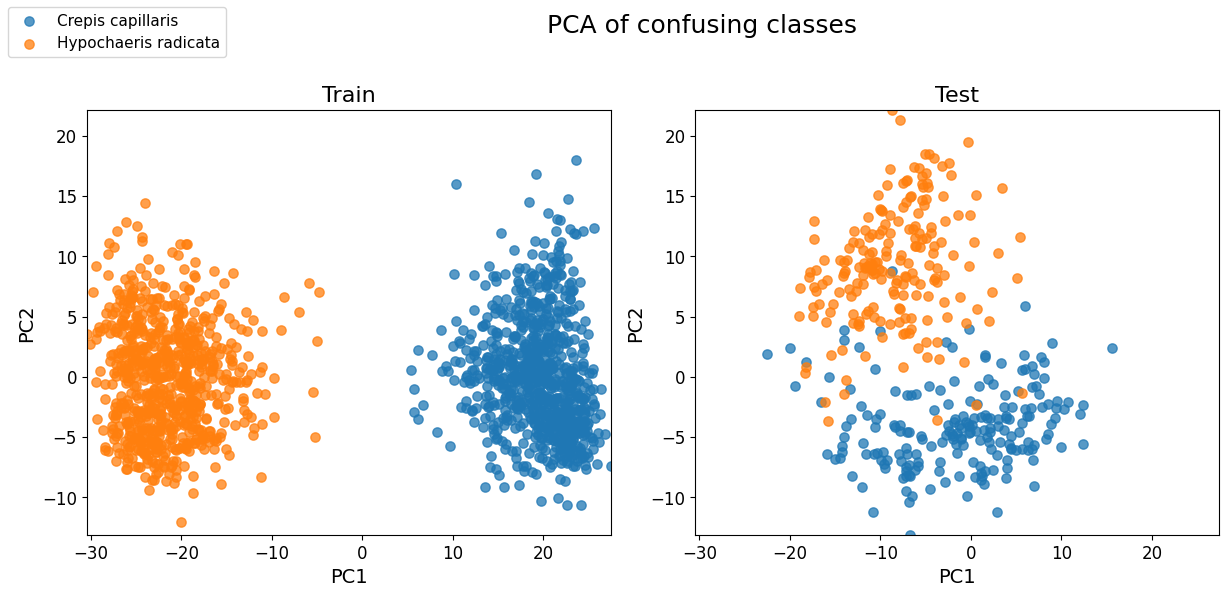

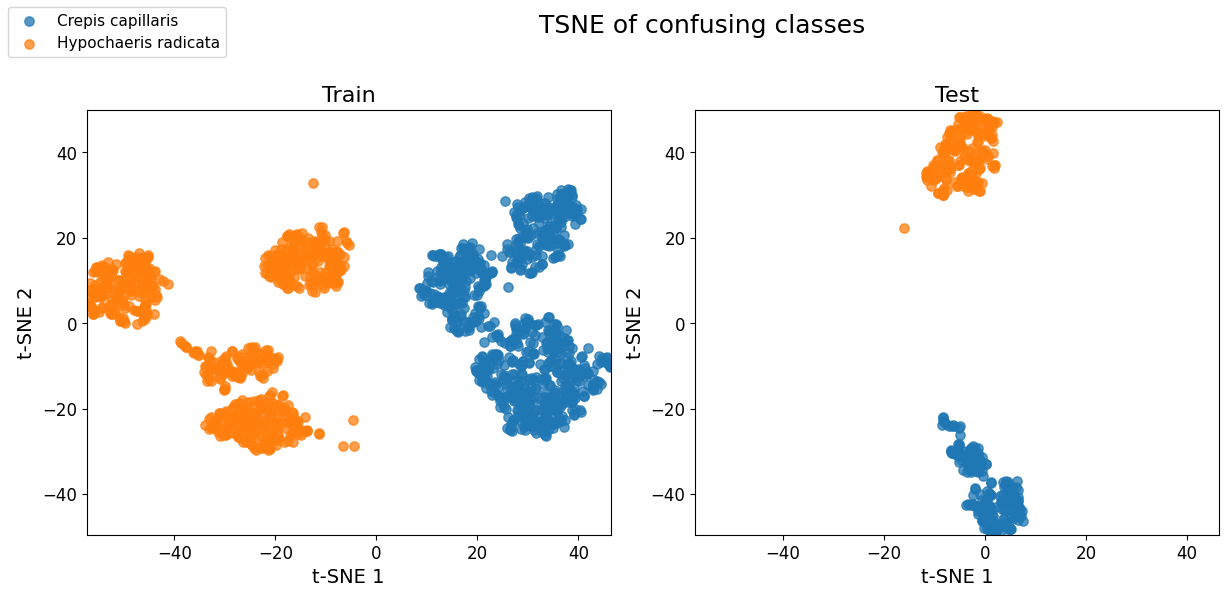

In [ ]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata"
]

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca"
    
)

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne"
)

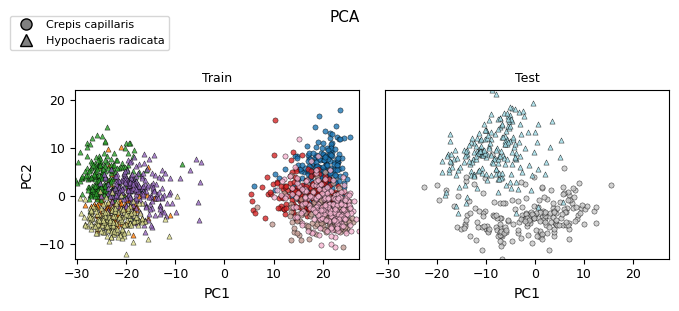

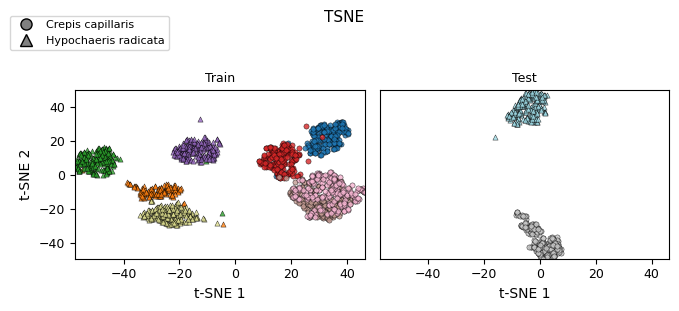

{'flower_color_map': {'1000322': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1001325': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
  '1005278': (0.17254901960784313,
   0.6274509803921569,
   0.17254901960784313,
   1.0),
  '1005299': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1005327': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1009502': (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
  '1009512': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
  '1010538': (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
  '1010554': (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
  '1012069': (0.6196078431372549,
   0.8549019607843137,
   0.8980392156862745,
   1.0)},
 'marker_map': {4: 'o', 6: '^'}}

In [79]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata"
]

plot_pca_tsne_flowerid_two_panels(
    X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca",
    show_flower_legend=False,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/pca_crepis_hypo.png"
)

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne",
    show_flower_legend=False,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_crepis_hypo.png"
)

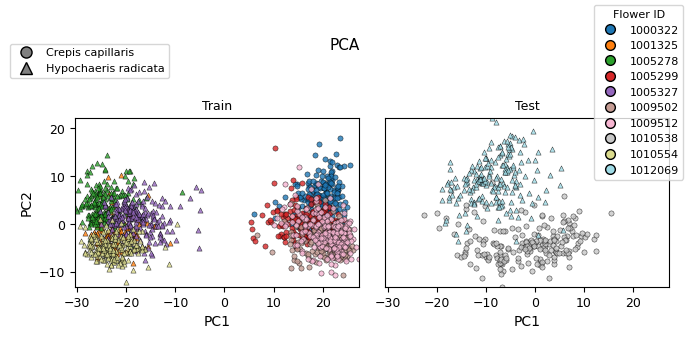

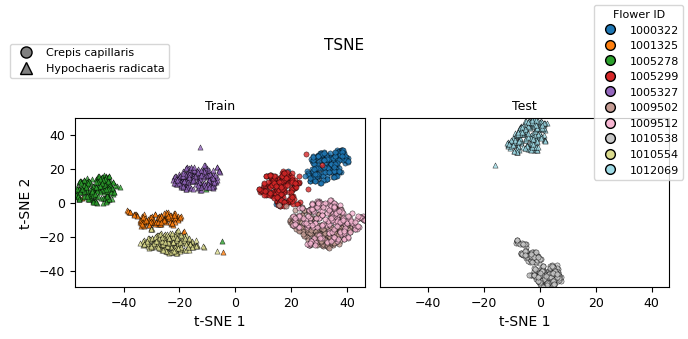

{'flower_color_map': {'1000322': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1001325': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
  '1005278': (0.17254901960784313,
   0.6274509803921569,
   0.17254901960784313,
   1.0),
  '1005299': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1005327': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1009502': (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
  '1009512': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
  '1010538': (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
  '1010554': (0.8588235294117647, 0.8588235294117647, 0.5529411764705883, 1.0),
  '1012069': (0.6196078431372549,
   0.8549019607843137,
   0.8980392156862745,
   1.0)},
 'marker_map': {4: 'o', 6: '^'}}

In [80]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata"
]

plot_pca_tsne_flowerid_two_panels(
    X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/pca_crepis_hypo.png"
   
)

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_crepis_hypo.png"
    
)

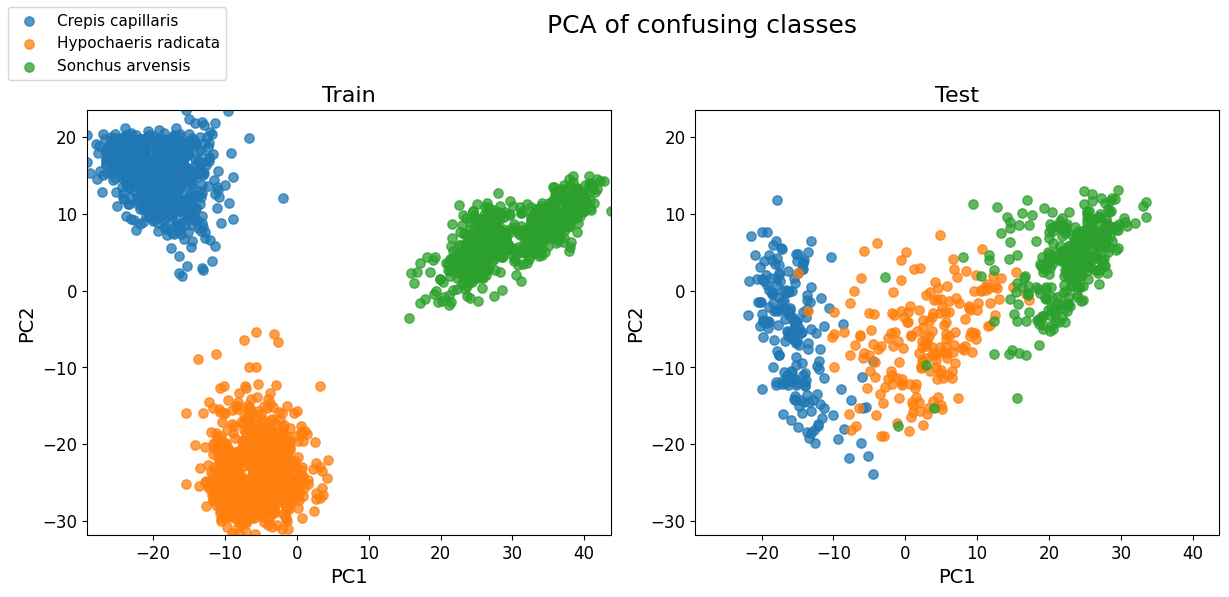

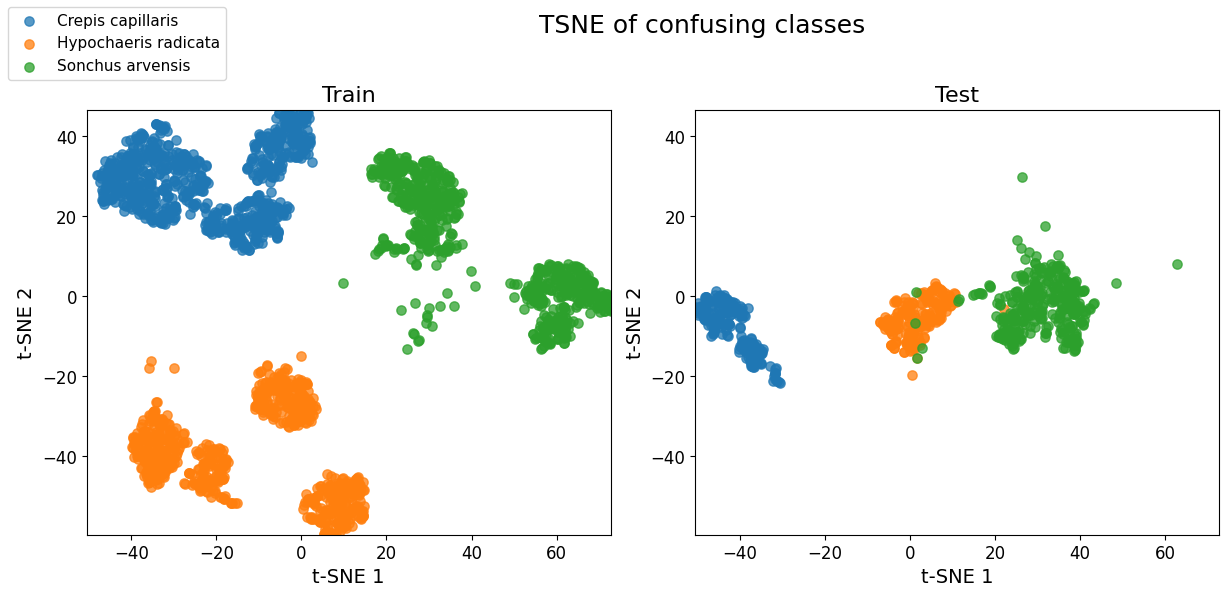

In [ ]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata",
    "Sonchus arvensis"
]

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca"
)

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne"
)

In [ ]:
flower_ids_train

array(['1001572', '1001572', '1001572', ..., '1005387', '1005387',
       '1005387'], dtype='<U7')

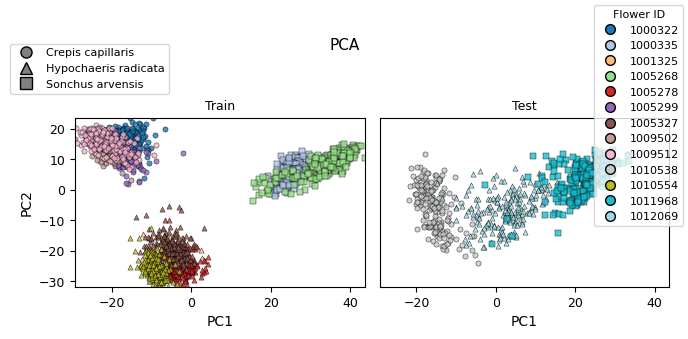

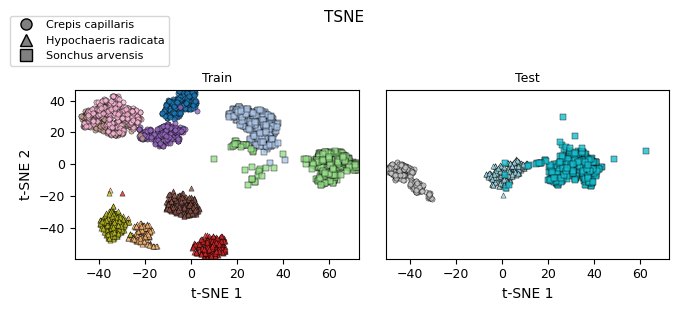

{'flower_color_map': {'1000322': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1000335': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
  '1001325': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
  '1005268': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
  '1005278': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1005299': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1005327': (0.5490196078431373,
   0.33725490196078434,
   0.29411764705882354,
   1.0),
  '1009502': (0.7686274509803922, 0.611764705882353, 0.5803921568627451, 1.0),
  '1009512': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058, 1.0),
  '1010538': (0.7803921568627451, 0.7803921568627451, 0.7803921568627451, 1.0),
  '1010554': (0.7372549019607844,
   0.7411764705882353,
   0.13333333333333333,
   1.0),
  '1011968': (0.09019607843137255,
   0.7450980392156863,
   0.8117647058823

In [81]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata",
    "Sonchus arvensis"
]


plot_pca_tsne_flowerid_two_panels(
    X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca",
    show_flower_legend=True,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/pca_crepis_hypo.png"
    ,max_flower_ids_in_legend=50
   
)

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne",
    show_flower_legend=False,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_crepis_hypo_son.png"
    ,max_flower_ids_in_legend=50
    
)

In [ ]:


train_mask = np.isin([classes[i] for i in y_train], confusing_classes)
test_mask  = np.isin([classes[i] for i in y_test], confusing_classes)

print("Train unique flower IDs:", np.unique(np.array(flower_ids_train)[train_mask]))
print("Test unique flower IDs:", np.unique(np.array(flower_ids_test)[test_mask]))

print("N train flower IDs:", len(np.unique(np.array(flower_ids_train)[train_mask])))
print("N test flower IDs:", len(np.unique(np.array(flower_ids_test)[test_mask])))

Train unique flower IDs: ['1000322' '1000335' '1001325' '1005268' '1005278' '1005299' '1005327'
 '1009502' '1009512' '1010554']
Test unique flower IDs: ['1010538' '1011968' '1012069']
N train flower IDs: 10
N test flower IDs: 3


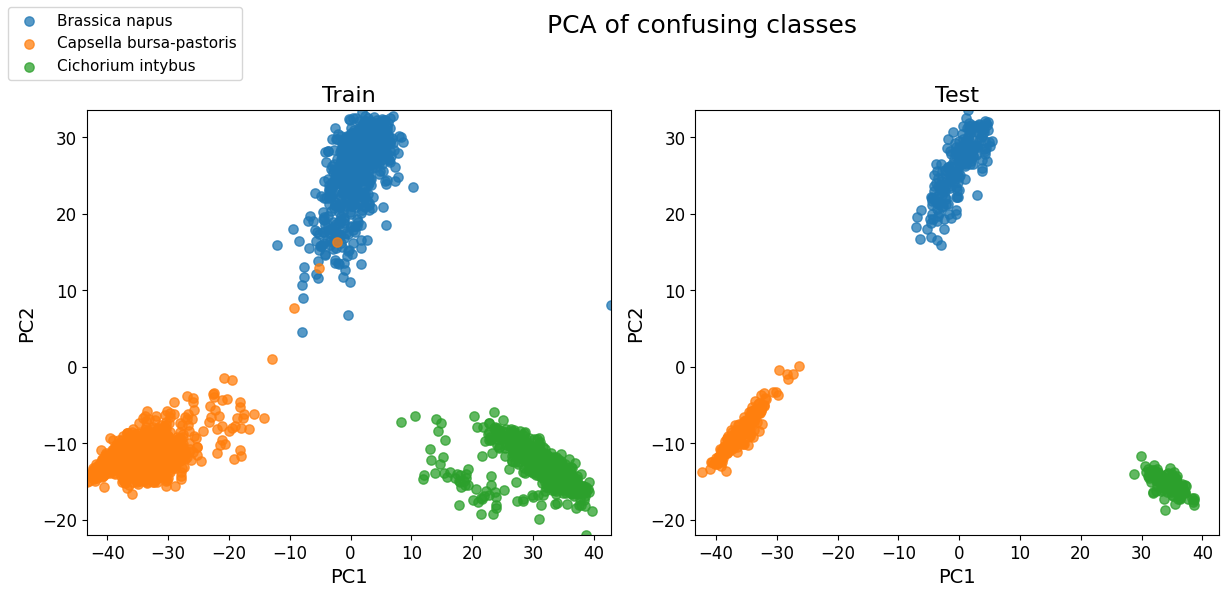

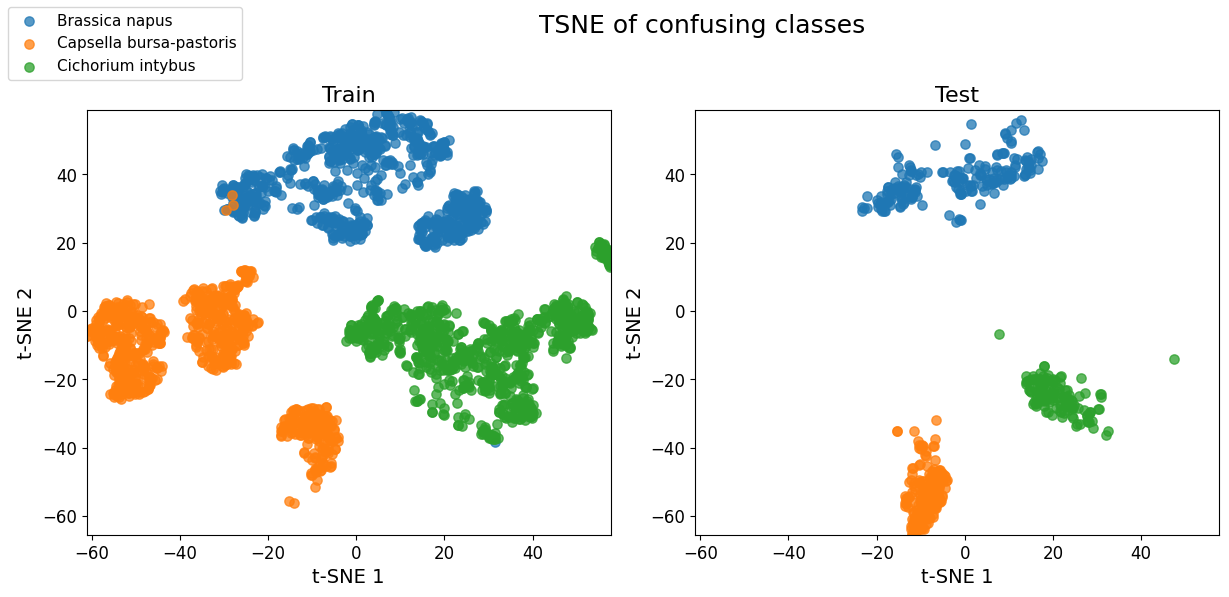

In [ ]:
well_classified_classes = [
    "Brassica napus",
    "Capsella bursa-pastoris",
    "Cichorium intybus"
]

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=well_classified_classes,
    method="pca"
)

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=well_classified_classes,
    method="tsne"
)

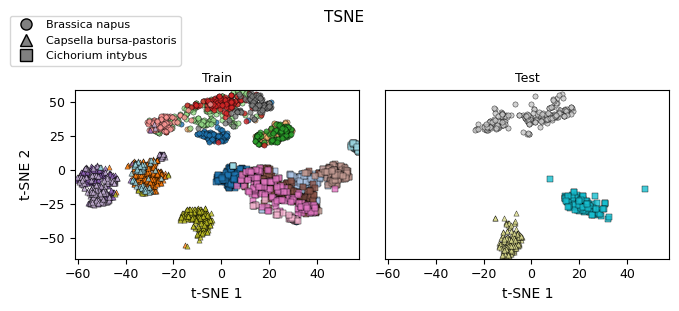

{'flower_color_map': {'1000318': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1000406': (0.12156862745098039,
   0.4666666666666667,
   0.7058823529411765,
   1.0),
  '1001372': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
  '1001617': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
  '1001635': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
  '1001647': (0.17254901960784313,
   0.6274509803921569,
   0.17254901960784313,
   1.0),
  '1004452': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
  '1004453': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
  '1004454': (0.8392156862745098,
   0.15294117647058825,
   0.1568627450980392,
   1.0),
  '1004455': (1.0, 0.596078431372549, 0.5882352941176471, 1.0),
  '1004520': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0),
  '1004521': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589, 1.0),
  '1005059': (0.549019607

In [82]:
well_classified_classes = [
    "Brassica napus",
    "Capsella bursa-pastoris",
    "Cichorium intybus"
]

plot_pca_tsne_flowerid_two_panels(
   X_train=X_train,
    y_train=y_train,
    flower_id_train=flower_ids_train,
    X_test=X_test,
    y_test=y_test,
    flower_id_test=flower_ids_test,
    class_names=classes,
    confusing_classes=well_classified_classes,
    method="tsne",
    show_flower_legend=False,
    save_path="/home/na1488tr-s/Bachelor_Project_Statistics/figures/tsne_brass_capsell_cicho.png"
    ,max_flower_ids_in_legend=50
    
)

In [54]:
classes

['Bellis perennis',
 'Brassica napus',
 'Capsella bursa-pastoris',
 'Cichorium intybus',
 'Crepis capillaris',
 'Hieracium umbellatum',
 'Hypochaeris radicata',
 'Sonchus arvensis',
 'Tragopogon pratensis',
 'Tussilago farfara']

In [67]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    fill_missing_bool=False
    ,val_bool=False
    ,aug_bool=False
    ,norm_bool=False
    ,sep_val_bool=False
)
num_classes = len(classes)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
bootstrap_impute_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 7922
Dataset setup complete.


In [68]:
seed_everything(SEED, deterministic=True)
model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

In [69]:
TARGET_CASES = [
    ("1010538", "1005327"),
    ("1009512", "1005278"),
]


=== Backbone Feature Inspection ===
Min of mins: -10.16848087310791
Max of maxs: 16.1893310546875
Mean of batch means: 0.01056515338895537
Mean of batch stds: 0.9929588534792916

Test Accuracy: 0.8398
Test Recall per class:
Class 0 (Bellis perennis): 0.5070
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.1100
Class 5 (Hieracium umbellatum): 0.9300
Class 6 (Hypochaeris radicata): 1.0000
Class 7 (Sonchus arvensis): 0.8653
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


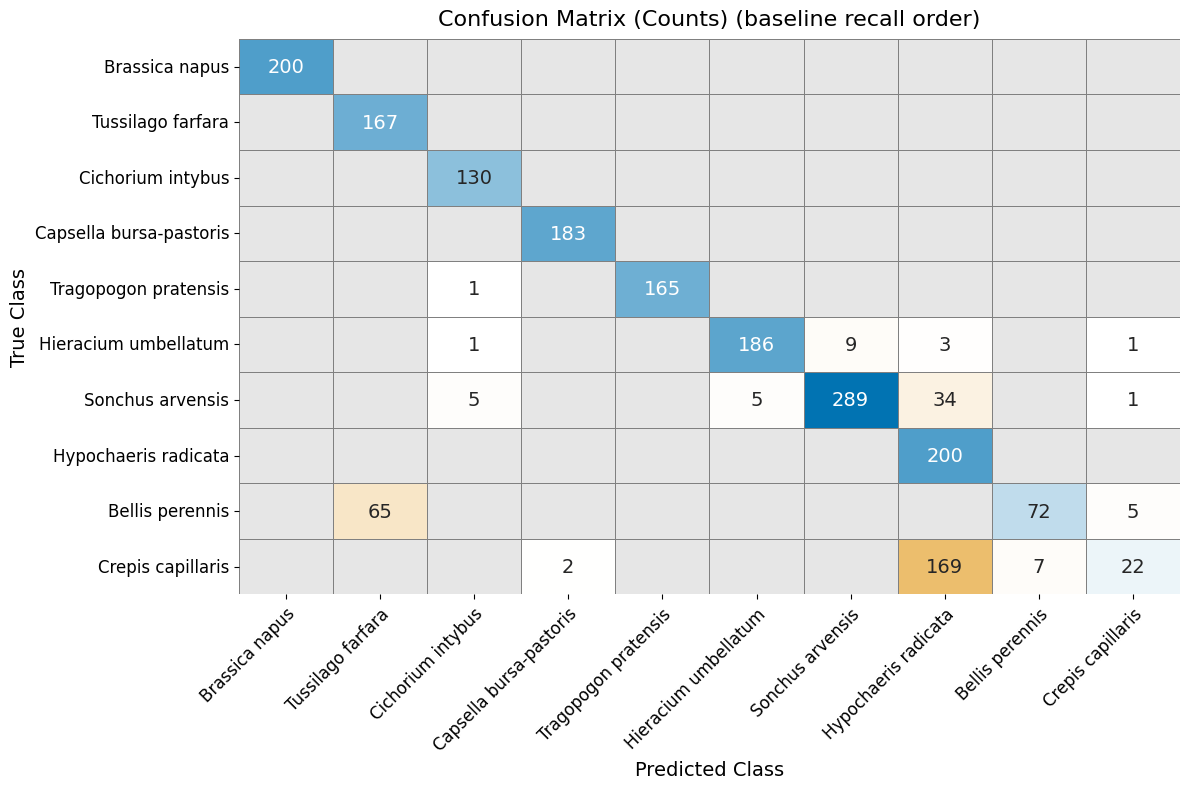

In [71]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )



ckpt = torch.load("models/saved_trained_models/convnext_fill_val_aug_sensi_C1010538_H1005327.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

recall_per_class_sensi_best, accuracy_sensi_best, probs_sensi_best, y_sensi_best, conf_sensi_best = eval_epoch(model, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy_sensi_best:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class_sensi_best):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

#plot_confusion_matrix(conf, idx_to_class, normalize=False, sort_by_recall_desc=True, figsize=(14,10), annot_size=18, tick_size=16,label_size=18, title_size=20)
plot_confusion_matrix(conf=conf_sensi_best, idx_to_class=idx_to_class, normalize=False, save_path="figures/confmat_sensi_best")

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

X_train, y_train,filenames_train, flower_ids_train = extract_features_labels_flowerids(model, train_loader, device)
X_test, y_test,filenames_test, flower_ids_test = extract_features_labels_flowerids(model, test_loader, device)

#X_train, y_train = extract_fused_features(model, train_loader, device)
#X_test, y_test = extract_fused_features(model, test_loader, device)

# Best 256 model


=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.504186630249023
Mean of batch means: 0.7496085880232639
Mean of batch stds: 1.0147019478141284

Test Accuracy: 0.8371
Test Recall per class:
Class 0 (Bellis perennis): 0.8521
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9781
Class 3 (Cichorium intybus): 0.9923
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9150
Class 6 (Hypochaeris radicata): 0.9150
Class 7 (Sonchus arvensis): 0.8533
Class 8 (Tragopogon pratensis): 0.9759
Class 9 (Tussilago farfara): 1.0000


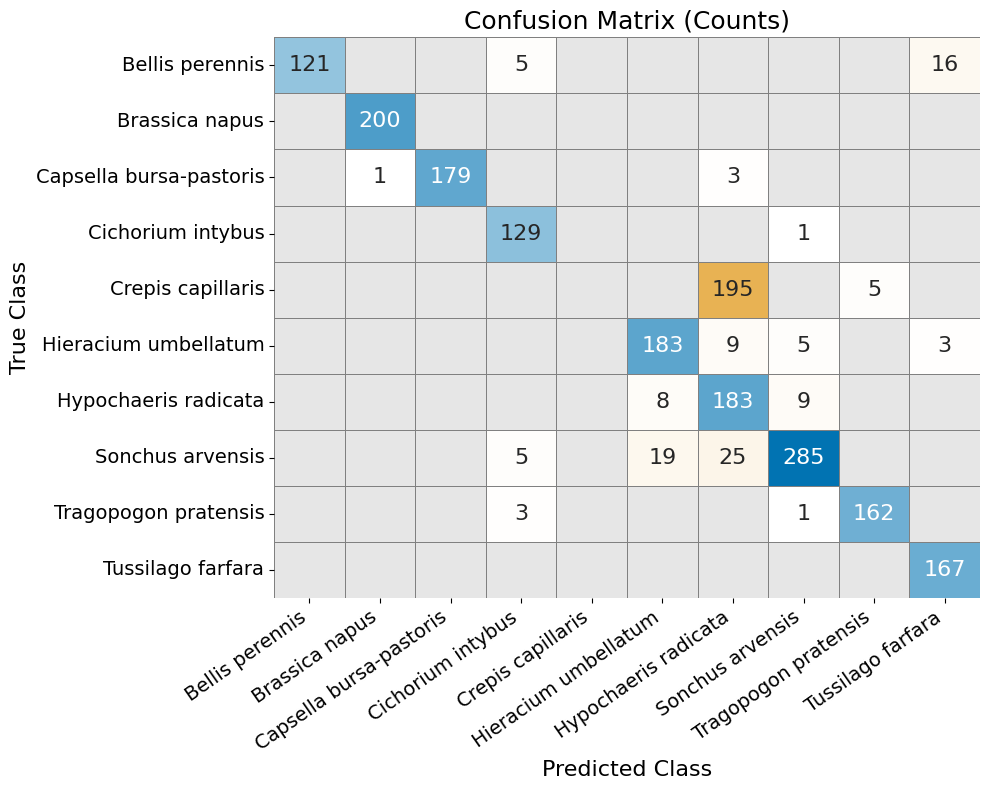

In [61]:
BATCHSIZE = 32

test_loader = DataLoader(
        test_dataset,
        batch_size=BATCHSIZE,
        shuffle=False,
        num_workers=0
    )

ckpt = torch.load("models/saved_trained_models/256base_model_fill_val.pth", map_location=device)
model_base256.load_state_dict(ckpt["model_state_dict"])
model_base256.to(device)

recall_per_class, accuracy, probs_256, y_256, conf = eval_epoch(model_base256, test_loader, device, num_classes=num_classes, loss_fn=None,inspect_features=True)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [66]:
active_indices, active_class_names = plot_true_class_heatmap_and_boxplot_threshold(
    probs=probs_256,
    y_true=y_256,
    class_names=classes,
    true_class_name="Crepis capillaris",
    threshold=0.05,
    sort_by="true_class_prob"
)

ValueError: 'Crepis capillaris' is not in list

In [ ]:
confusing_classes = [
    "Crepis capillaris",
    "Hypochaeris radicata"
]

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="pca"
)

plot_pca_tsne_two_panels(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    class_names=classes,
    confusing_classes=confusing_classes,
    method="tsne"
)